In [153]:
import pandas as pd

A = './task1_dataset_kotae.csv'
B = './hiroshima_challengedata(B).csv'
C = './sapporo_challengedata(C).csv'
D = './kumamoto_challengedata(D).csv'

df = pd.read_csv(D)

# 確認欄位型態
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8418135 entries, 0 to 8418134
Data columns (total 5 columns):
 #   Column  Dtype
---  ------  -----
 0   uid     int64
 1   d       int64
 2   t       int64
 3   x       int64
 4   y       int64
dtypes: int64(5)
memory usage: 321.1 MB


# 同一時間的切片格式

**獨立Day、Time的單一切片圖**

In [154]:
# 範例：第 61 天、時間 20
day = 61
time_slot = 20
subset = df[(df["d"] == day) & (df["t"] == time_slot)]

# pivot 轉成矩陣：行 = y，列 = x
matrix = subset.pivot_table(index="y", columns="x", values="uid", aggfunc="count").fillna(0)

# print(matrix.head())


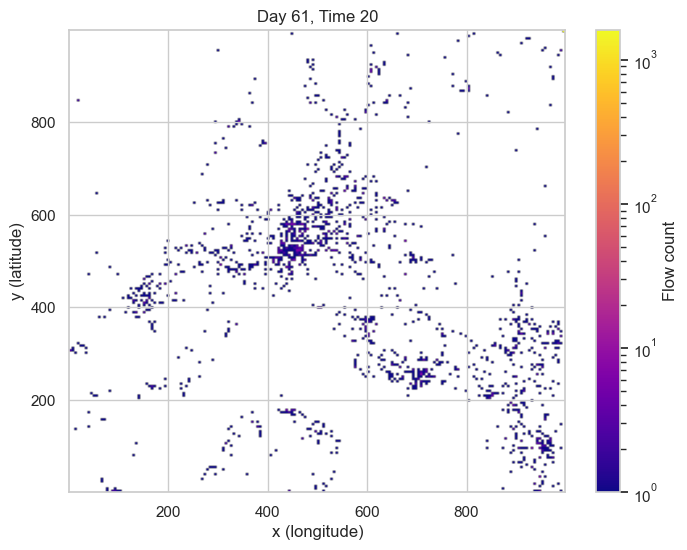

In [155]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

plt.figure(figsize=(8,6))
plt.imshow(matrix.values, cmap="plasma", origin="lower",
            extent=[matrix.columns.min(), matrix.columns.max(),
            matrix.index.min(), matrix.index.max()],
            aspect="auto",
            norm=LogNorm(vmin=1, vmax=matrix.values.max()))

plt.colorbar(label="Flow count")
plt.xlabel("x (longitude)")
plt.ylabel("y (latitude)")
plt.title(f"Day {day}, Time {time_slot}")

plt.show()


**加總所有時間點的切片圖**





In [156]:
import pandas as pd

# 對所有天 (d) + 時間 (t) 加總，每個格點 (x,y) 的人流總數
grid_sum = df.groupby(["x", "y"]).size().reset_index(name="count")

matrix = grid_sum.pivot(index="y", columns="x", values="count").fillna(0)

top50 = grid_sum.sort_values("count", ascending=False).head(50)

print("人流最多的前 50 個格點：")
print(top50)

人流最多的前 50 個格點：
         x    y   count
21113  999  999  824733
8738   101  102   18570
8739   101  103   16900
8625   100  102   10945
8426    98  113   10817
8737   101  101    9469
14830  147   50    8342
8624   100  101    8292
8740   101  104    7905
8860   102  104    7456
8509    99   99    7382
8305    97   96    7243
2495    42   80    7189
8416    98  103    7155
9127   104  111    7070
8313    97  104    6994
8310    97  101    6937
9938   110  106    6921
8859   102  103    6806
8519    99  109    6660
8516    99  106    6642
8309    97  100    6635
10247  112  117    6620
1725    30    1    6502
8214    96  104    6485
8423    98  110    6444
8384    98   34    6443
19146  186   72    6413
9255   105  113    6388
8330    97  121    6380
10101  111  115    6312
11441  121   99    6270
8508    99   98    6266
10391  113  117    6264
6589    83  121    6207
8322    97  113    6179
9388   106  119    6175
14952  148   51    6150
8021    94  105    6050
20897  199   69    6033
8

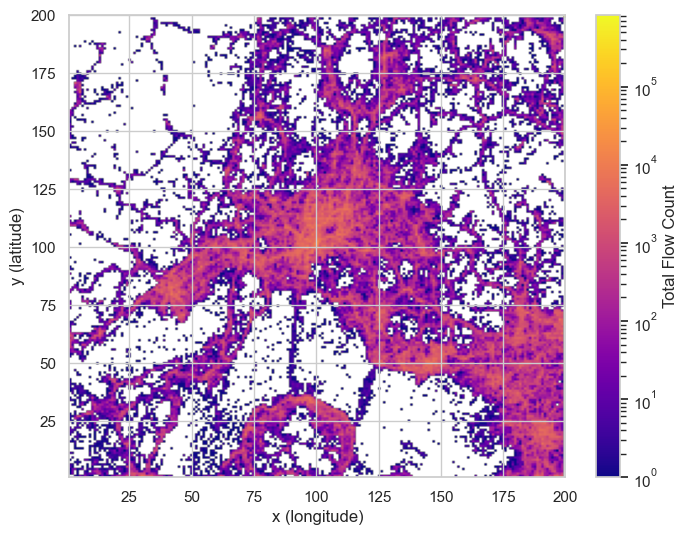

In [157]:
plt.figure(figsize=(8,6))

plt.imshow(matrix.values,
           cmap="plasma",
           origin="lower",
           extent=[matrix.columns.min(), 200,
                   matrix.index.min(), 200],
           aspect="auto",
           norm=LogNorm(vmin=1, vmax=matrix.values.max()))

plt.colorbar(label="Total Flow Count")
plt.xlabel("x (longitude)")
plt.ylabel("y (latitude)")
plt.gca().set_facecolor("white")

plt.show()


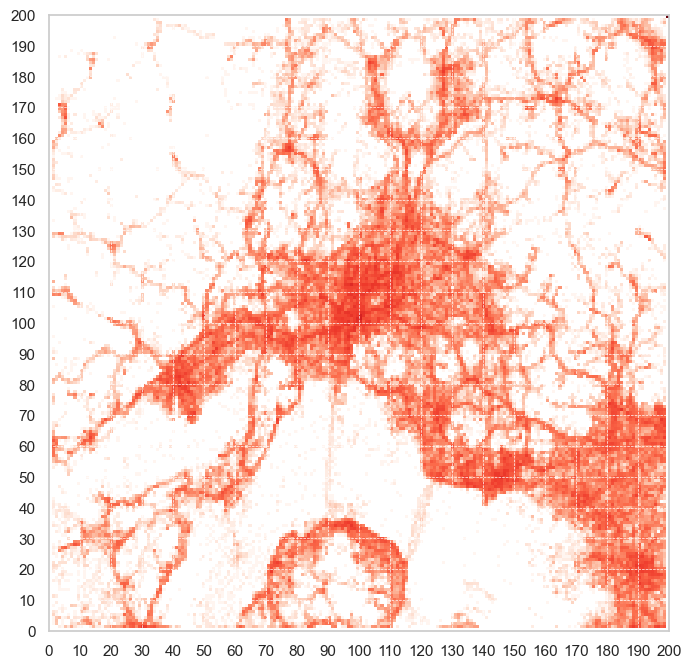

In [85]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

plt.figure(figsize=(8,8))

# 畫 heatmap
plt.imshow(matrix.values,
           cmap="Reds",
           origin="lower",
           extent=[matrix.columns.min(), 200,
                   matrix.index.min(), 200],
           aspect="auto",
           norm=LogNorm(vmin=1, vmax=matrix.values.max()))

# X、Y 軸刻度
x_ticks = np.arange(0, 200+1, 10)
y_ticks = np.arange(0, 200+1, 10)
plt.xticks(x_ticks)
plt.yticks(y_ticks)
plt.grid(color="white", linestyle="--", linewidth=0.5)
'''
# 星號推算出來的格點
stars = [(135, 77), (136, 77), (134, 77)]

for i, (x, y) in enumerate(stars, 1):
    plt.scatter(x, y, color="red", s=25, marker="o", edgecolors="black", linewidth=1.2, zorder=3)
    plt.text(x+2, y+2, f"★{i}", color="red", fontsize=12, weight="bold")

plt.xlabel("x (grid index / longitude proxy)")
plt.ylabel("y (grid index / latitude proxy)")
plt.title("Heatmap with 3 star locations (approx. matched)")
'''
plt.show()


# 時間序列格式

**全域格式**


In [160]:
# 選定格點
x_target, y_target = 100, 104
subset = df[(df["x"] == x_target) & (df["y"] == y_target)].copy()

# 全域時間索引
subset["time_index"] = subset["d"] * 48 + subset["t"]

# 每個時間點的人數
time_series = subset.groupby("time_index").size().reset_index(name="count")


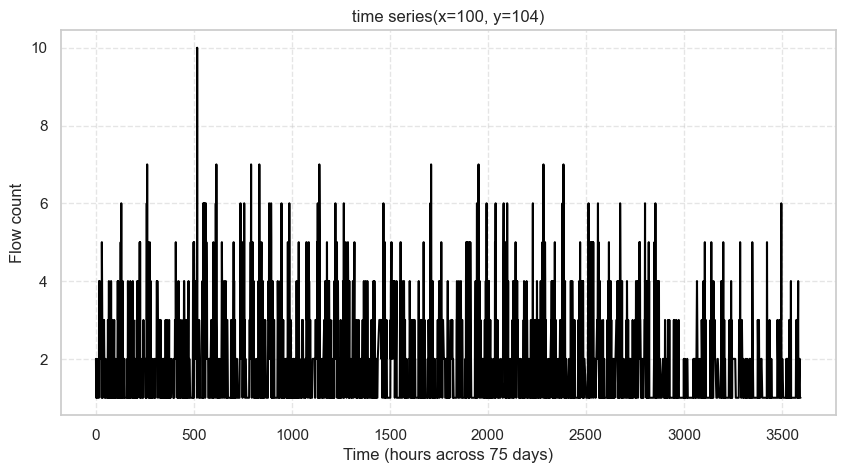

In [161]:
plt.figure(figsize=(10,5))
plt.plot(time_series["time_index"], time_series["count"], color="black")
plt.xlabel("Time (hours across 75 days)")
plt.ylabel("Flow count")
plt.title(f"time series(x={x_target}, y={y_target})")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

**短時間頻率格式**


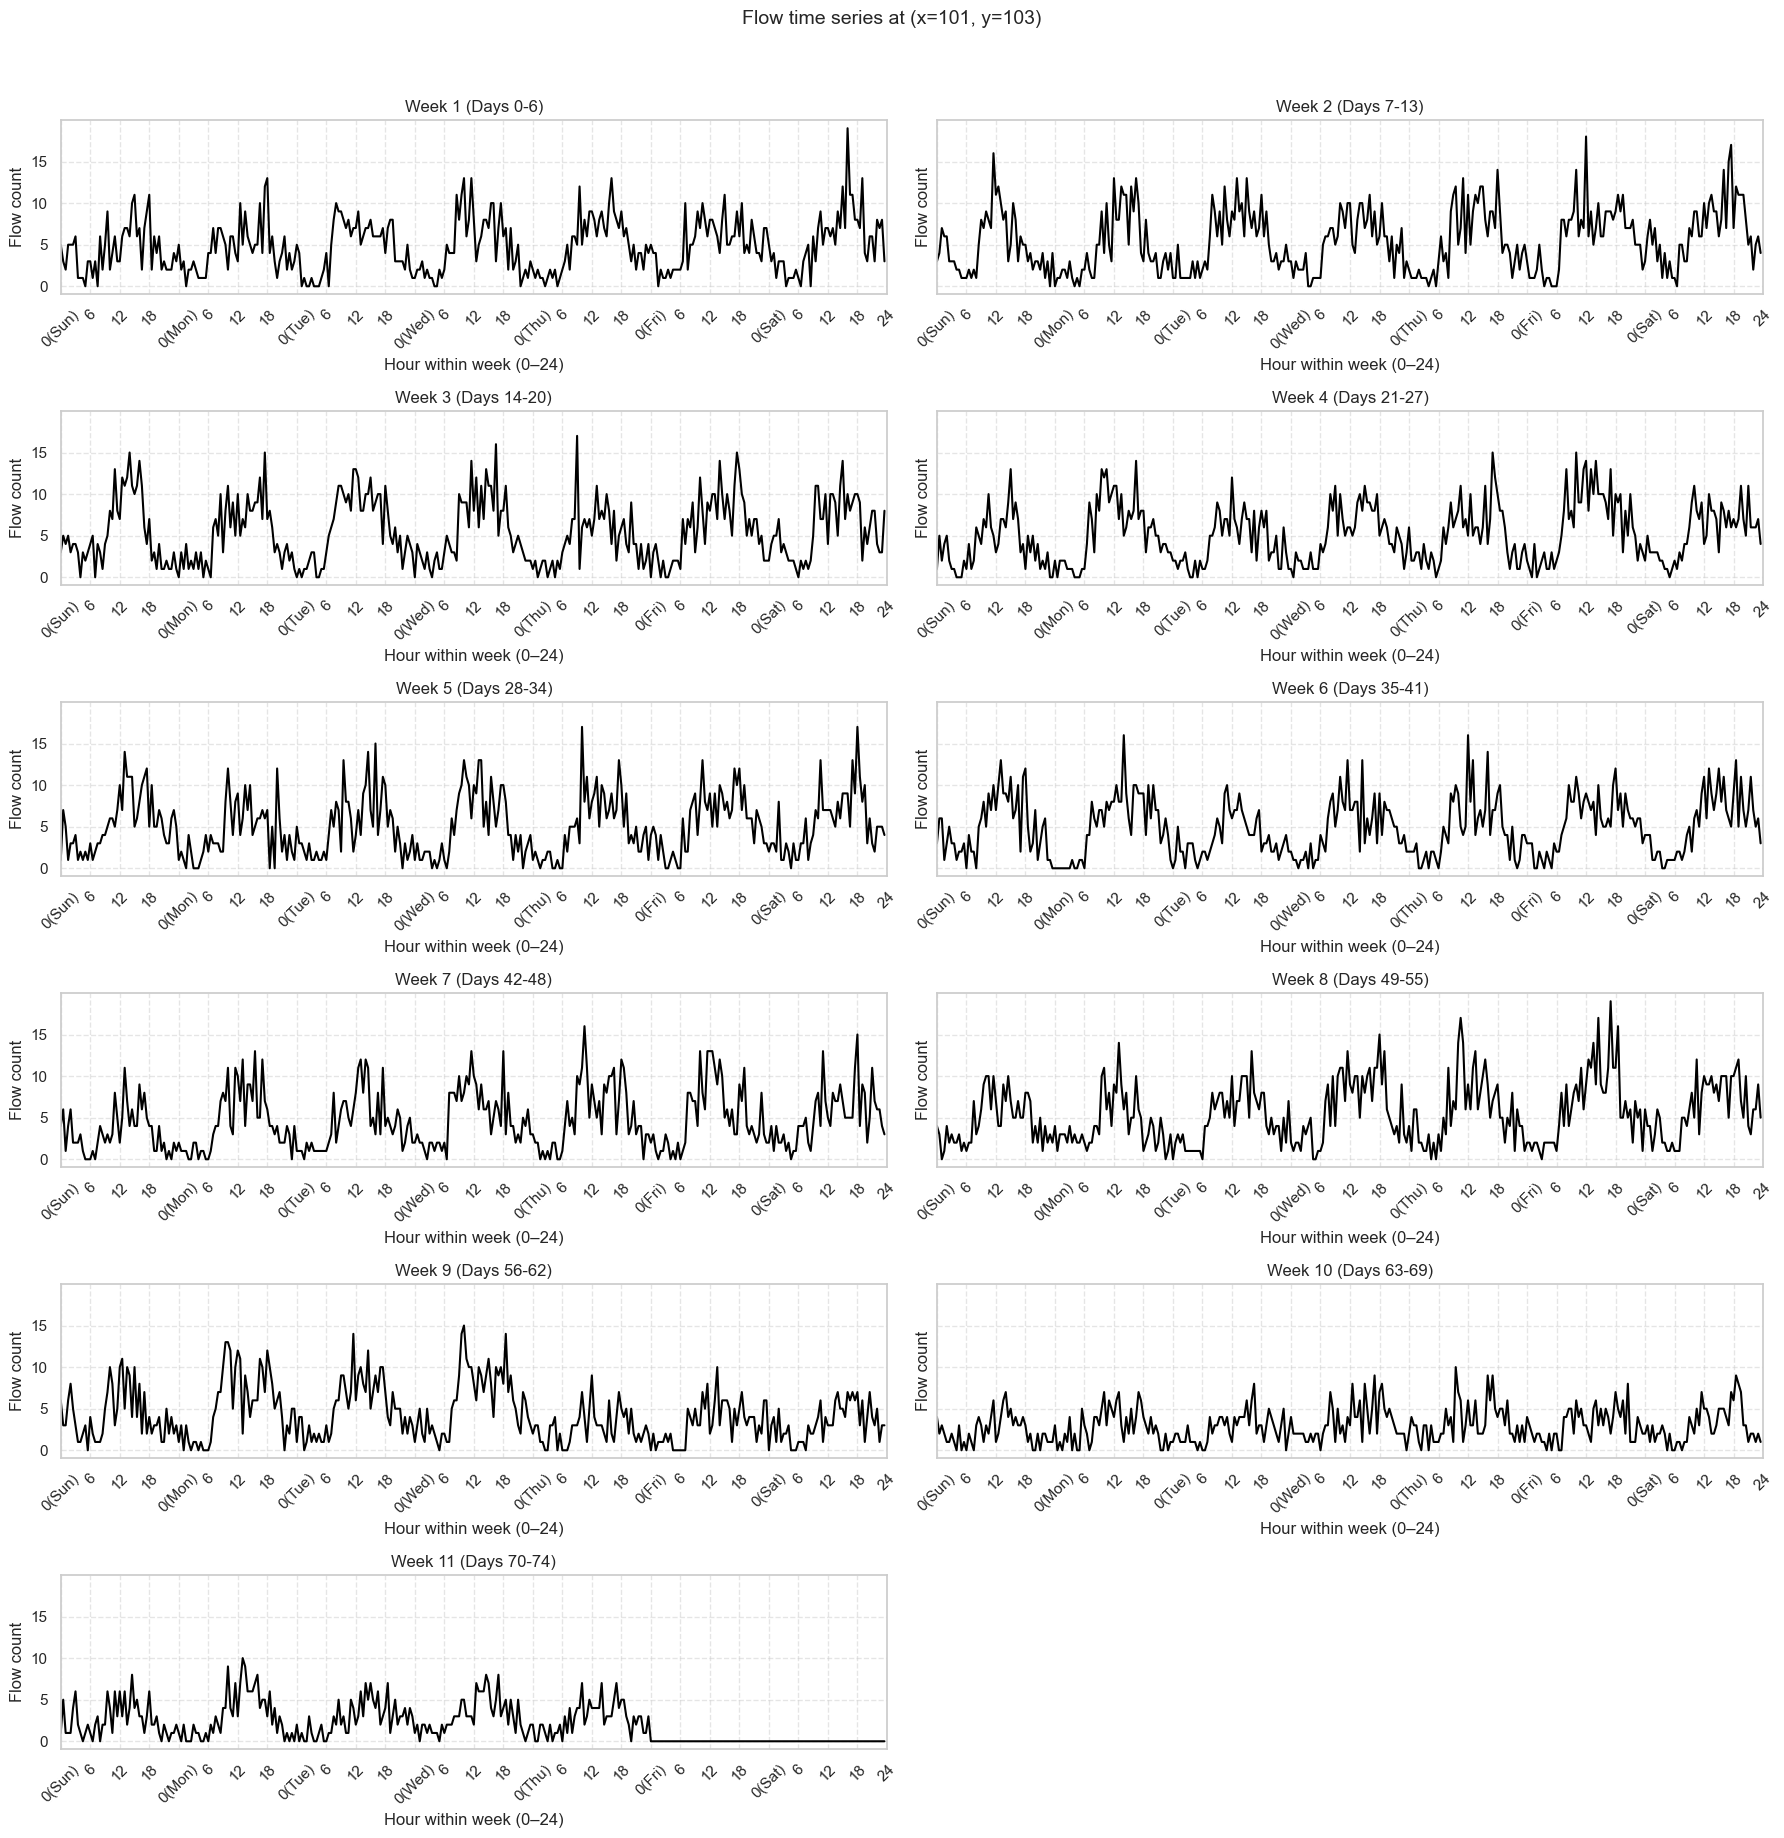

In [88]:
import matplotlib.pyplot as plt
import numpy as np

# 換成小時索引
subset = df[(df["x"] == x_target) & (df["y"] == y_target)].copy()
subset["hour_index"] = subset["d"] * 24 + subset["t"] / 2

# 計算總天數 & 週數
n_days = subset["d"].max() + 1
n_weeks = int(np.ceil(n_days / 7))  # 可以切多少完整週

# 設定 subplot 排版 (2 張一排)
n_cols = 2
n_rows = int(np.ceil(n_weeks / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 3*n_rows), sharey=True)
axes = axes.flatten()

# Step 4. 逐週繪圖
for i in range(n_weeks):
    start_day = i * 7
    end_day = min((i + 1) * 7, n_days)
    mask = (subset["d"] >= start_day) & (subset["d"] < end_day)
    week_data = subset[mask].copy()
    week_data["hour_index"] = (week_data["d"] - start_day) * 24 + week_data["t"] / 2
    week_series = week_data.groupby("hour_index").size().reset_index(name="count")

    max_hours = 7 * 24
    full_hours = pd.DataFrame({"hour_index": np.arange(0, 7*24, 0.5)})
    week_series = full_hours.merge(week_series, on="hour_index", how="left").fillna(0)

    ax = axes[i]
    ax.plot(week_series["hour_index"], week_series["count"], color="black")
    ax.set_title(f"Week {i+1} (Days {start_day}-{end_day-1})")
    ax.set_xlim(0, 168)

    # 建立 tick：每6hr / 每天
    xticks = []
    xticklabels = []
    weekdays = ["Sun", "Mon", "Tue", "Wed", "Thu", "Fri", "Sat"]
    for d in range(7):
        base = d * 24
        for h in [0, 6, 12, 18]:
            xticks.append(base + h)
            if h == 0:
                xticklabels.append(f"0({weekdays[d]})")
            else:
                xticklabels.append(str(h))
    # 最後補上 Saturday 24h
    xticks.append(7*24)
    xticklabels.append("24")

    ax.set_xticks(xticks)
    ax.set_xticklabels(xticklabels, rotation=45)
    ax.grid(True, linestyle="--", alpha=0.5)

# 移除多餘 subplot
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

# 標籤
fig.suptitle(f"Flow time series at (x={x_target}, y={y_target})", y=1.02, fontsize=14)
for ax in axes:
    ax.set_xlabel("Hour within week (0–24)")
    ax.set_ylabel("Flow count")

plt.tight_layout()
plt.show()


# 個人化特徵與日期格式

In [148]:
import pandas as pd

A = './task1_dataset_kotae.csv'
B = './hiroshima_challengedata(B).csv'
C = './sapporo_challengedata(C).csv'
D = './kumamoto_challengedata(D).csv'

df = pd.read_csv(A)

# 確認欄位型態
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111535175 entries, 0 to 111535174
Data columns (total 5 columns):
 #   Column  Dtype
---  ------  -----
 0   uid     int64
 1   d       int64
 2   t       int64
 3   x       int64
 4   y       int64
dtypes: int64(5)
memory usage: 4.2 GB


In [149]:
import matplotlib.pyplot as plt

# 住家推定 (22:00–06:00 最常出現的位置)
night_df = df[(df["t"] >= 44) | (df["t"] <= 12)]
counts = (
    night_df.groupby(["uid", "x", "y"])
    .size()
    .reset_index(name="count")
)
print(counts.head())
home_locations = (
    counts.sort_values(["uid", "count"], ascending=[True, False])
    .drop_duplicates("uid")
    .rename(columns={"x": "home_x", "y": "home_y"})
    [["uid", "home_x", "home_y"]]
)

# Step 3. 合併住家資訊 & 標記是否在家
df_with_home = df.merge(home_locations, on="uid", how="left")

df_with_home["at_home"] = (
    (df_with_home["x"] == df_with_home["home_x"]) &
    (df_with_home["y"] == df_with_home["home_y"])
)
print("是否在家 ")
print(df_with_home.head())


   uid   x   y  count
0    0  76  84      2
1    0  76  85      3
2    0  76  87      2
3    0  77  85      3
4    0  77  86     31
是否在家 
   uid  d   t   x   y  home_x  home_y  at_home
0    0  0   1  79  86    77.0    86.0    False
1    0  0   2  79  86    77.0    86.0    False
2    0  0   8  77  86    77.0    86.0     True
3    0  0   9  77  86    77.0    86.0     True
4    0  0  19  81  89    77.0    86.0    False


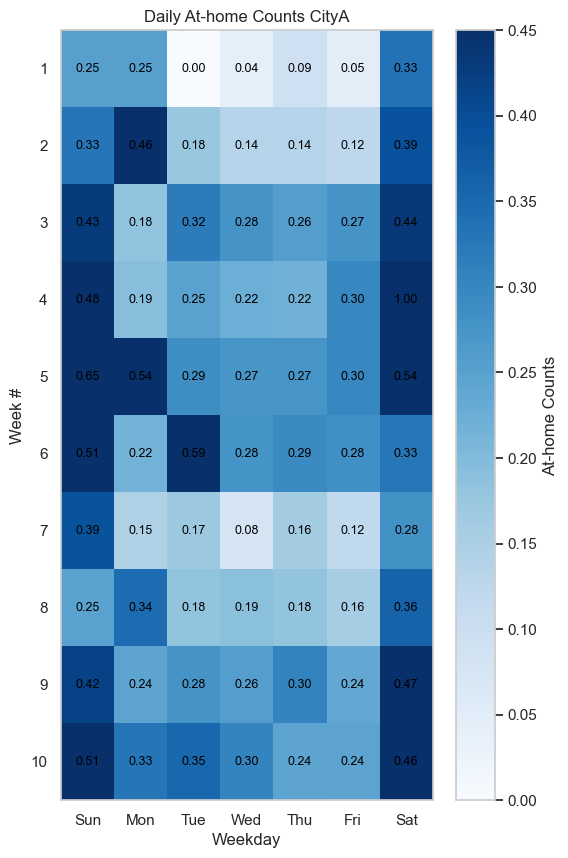

In [151]:
df_with_home = df_with_home[df_with_home["d"] < 70]

# 每個人每天在家的總次數
daily_home = (
    df_with_home[df_with_home["at_home"]]
    .groupby(["uid", "d"])
    .size()
    .reset_index(name="at_home_count")
)

# 加入週次 & 星期
daily_home["week"] = (daily_home["d"] // 7) + 1
daily_home["weekday"] = (daily_home["d"] % 7)  # 0=Sun, 1=Mon, ..., 6=Sat

# 整合成整體表格 (所有人加總)
agg_home = (
    daily_home.groupby(["week", "weekday"])["at_home_count"]
    .sum()
    .reset_index()
)

# 建立矩陣
mat = agg_home.pivot(index="week", columns="weekday", values="at_home_count").fillna(0)

# 調整順序 Sun(0) 到 Sat(6)
weekday_order = [0, 1, 2, 3, 4, 5, 6]
mat = mat[weekday_order]

# Min-Max Normalization
mat_norm = (mat - mat.min().min()) / (mat.max().max() - mat.min().min())

# plot
fig, ax = plt.subplots(figsize=(6,10), facecolor="white")
im = ax.imshow(mat_norm.values, cmap="Blues", origin="lower", aspect="auto", vmin=0, vmax=.45)

# 格子內標註數值
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        ax.text(j, i, f"{mat_norm.values[i, j]:.2f}",
                ha="center", va="center", color="black", fontsize=9)

ax.set_xticks(range(len(mat.columns)))
ax.set_xticklabels(["Sun","Mon","Tue","Wed","Thu","Fri","Sat"])
ax.set_yticks(range(len(mat.index)))
ax.set_yticklabels(mat.index)
ax.grid(False)

plt.xlabel("Weekday")
plt.ylabel("Week #")
plt.title("Daily At-home Counts CityA")
plt.colorbar(im, label="At-home Counts")


# 反轉周次
ax.invert_yaxis()

plt.show()



**幫助尋找POI的工具 找出最多匯集的特定POI**

In [ ]:
df_POI = pd.read_csv("POIdata_cityA.csv")
# Transit Station
df_48 = df_POI[df_POI["category"] == 48]

agg_48 = df_48.groupby(["x", "y"])["POI_count"].sum().reset_index()

max_point_48 = agg_48.loc[agg_48["POI_count"].idxmax()]

print("Transit Station 出現最多的點：")
print(max_point_48)

# Shopping

df_2 = df_POI[df_POI["category"] == 40]

agg_2 = df_2.groupby(["x", "y"])["POI_count"].sum().reset_index()

max_point_2 = agg_2.loc[agg_2["POI_count"].idxmax()]

print("Shopping 出現最多的點：")
print(max_point_2)

# School

df_56 = df_POI[df_POI["category"] == 56]

agg_56 = df_56.groupby(["x", "y"])["POI_count"].sum().reset_index()

max_point_56 = agg_56.loc[agg_56["POI_count"].idxmax()]

print("School 出現最多的點：")
print(max_point_56)

Transit Station 出現最多的點：
x            134
y             83
POI_count    108
Name: 4766, dtype: int64
Shopping 出現最多的點：
x            134
y             82
POI_count    339
Name: 1578, dtype: int64
School 出現最多的點：
x            136
y             77
POI_count     11
Name: 1428, dtype: int64


 # 建模
 **LSTM**


In [162]:
import pandas as pd

A = './task1_dataset_kotae.csv'
B = './hiroshima_challengedata(B).csv'
C = './sapporo_challengedata(C).csv'
D = './kumamoto_challengedata(D).csv'

df = pd.read_csv(D)

# 確認欄位型態
# df.info()

In [163]:
import pandas as pd
x_target , y_target = 101, 103

# 預測位置
lstm_df = df[(df["x"]==x_target) & (df["y"]==y_target)].copy()

# 建立全域時間索引
lstm_df["time_index"] = lstm_df["d"] * 48 + lstm_df["t"]

# 每個時間點的人數
time_series = lstm_df.groupby("time_index").size().reset_index(name="count")

print(time_series.head())


   time_index  count
0           0      5
1           1      3
2           2      2
3           3      5
4           4      5


In [164]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

series = time_series["count"].values.reshape(-1,1)

# 建立 x, y
def create_dataset(series, look_back=48):  # 48 半小時 = 1 天
    X, y = [], []
    for i in range(len(series)-look_back):
        X.append(series[i:i+look_back])
        y.append(series[i+look_back])
    return np.array(X), np.array(y)

'''
如果原始序列是 [1,2,3,4,5,6], look_back=3
→ 輸出會是：

X = [[1,2,3], [2,3,4], [3,4,5]]

y = [4, 5, 6]
'''

look_back = 48
X, y = create_dataset(series, look_back)

# reshape 成 [samples, timesteps, features]
X = X.reshape((X.shape[0], X.shape[1], 1))
print(X.shape, y.shape)


(3306, 48, 1) (3306, 1)


Epoch 1/50


c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0596 - val_loss: 0.0240
Epoch 2/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0198 - val_loss: 0.0229
Epoch 3/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0192 - val_loss: 0.0222
Epoch 4/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0188 - val_loss: 0.0217
Epoch 5/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0181 - val_loss: 0.0216
Epoch 6/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0182 - val_loss: 0.0212
Epoch 7/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0179 - val_loss: 0.0212
Epoch 8/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0179 - val_loss: 0.0211
Epoch 9/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0177 - val_loss: 0.0205
Epoch 10/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0178 - val_loss: 0.0213
Epoch 11/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0176 - val_loss: 0.0211
Epoch 12/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0185 - val_loss: 0.0212


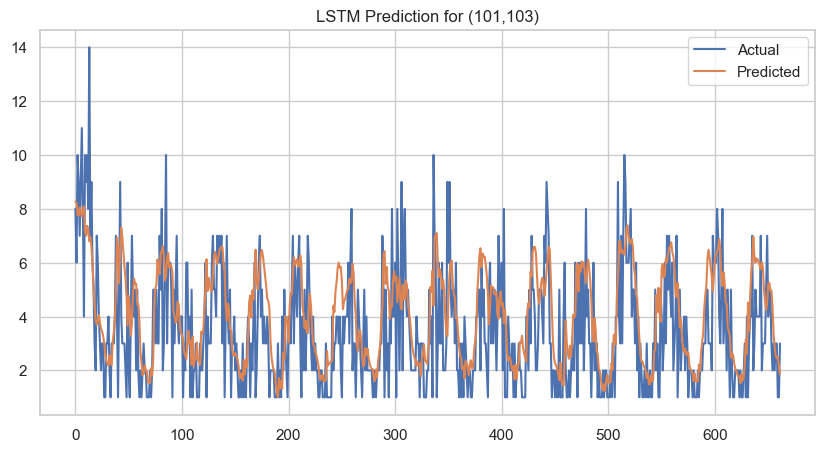

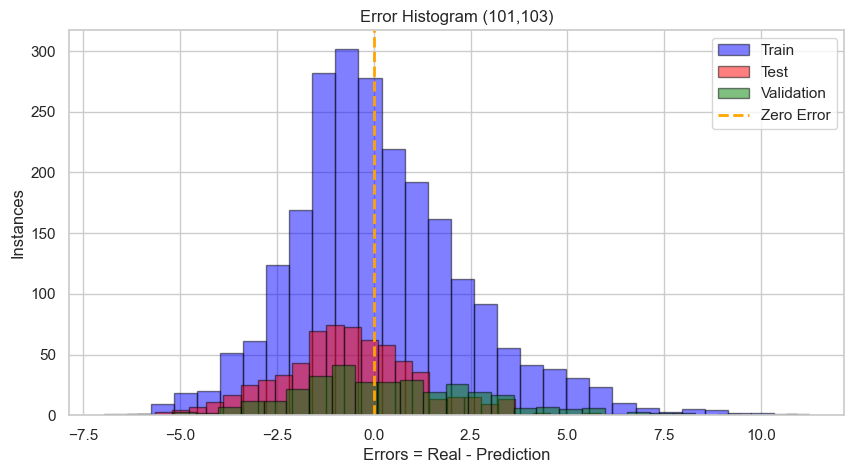

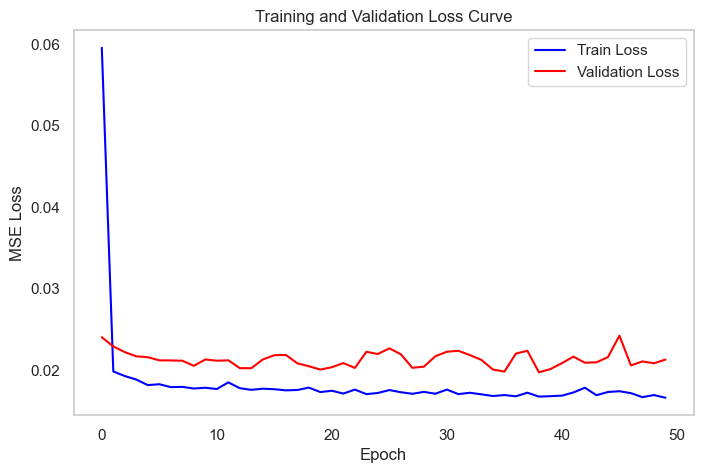

In [ ]:
# 分割資料集
train_size = int(len(X) * 0.7)
val_size   = int(len(X) * 0.1)
test_size  = len(X) - train_size - val_size

X_train, y_train = X[:train_size], y[:train_size]
X_val,   y_val   = X[train_size:train_size+val_size], y[train_size:train_size+val_size]
X_test,  y_test  = X[train_size+val_size:], y[train_size+val_size:]

import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

scaler = MinMaxScaler()
scaler.fit(y_train.reshape(-1,1))   # 用訓練集做正歸化

# 用同一組 min/max 縮放驗證集、測試集
y_train = scaler.transform(y_train.reshape(-1,1))
y_val   = scaler.transform(y_val.reshape(-1,1))
y_test  = scaler.transform(y_test.reshape(-1,1))

# 建模
model = Sequential([
    LSTM(50, input_shape=(look_back, 1)),   # LSTM層, Hidden Unit = 50
    Dense(1)                                # 全連接層
])

# 模型訓練
model.compile(optimizer="adam", loss="mse")
history = model.fit(X_train, y_train,
                    epochs=50,
                    batch_size=32,
                    validation_data=(X_val, y_val),
                    verbose=1)

# 模型預測
y_train_pred = model.predict(X_train)
y_val_pred   = model.predict(X_val)
y_test_pred  = model.predict(X_test)

# 還原
y_train_inv     = scaler.inverse_transform(y_train.reshape(-1,1))
y_train_pred_inv= scaler.inverse_transform(y_train_pred)

y_val_inv     = scaler.inverse_transform(y_val.reshape(-1,1))
y_val_pred_inv= scaler.inverse_transform(y_val_pred)

y_test_inv     = scaler.inverse_transform(y_test.reshape(-1,1))
y_test_pred_inv= scaler.inverse_transform(y_test_pred)


errors_train = y_train_inv.flatten() - y_train_pred_inv.flatten()
errors_val   = y_val_inv.flatten()   - y_val_pred_inv.flatten()
errors_test  = y_test_inv.flatten()  - y_test_pred_inv.flatten()

# 繪製折線圖LSTM Prediction
plt.figure(figsize=(10,5))
plt.plot(y_test_inv, label="Actual")
plt.plot(y_test_pred_inv, label="Predicted")
plt.legend()
plt.title(f"LSTM Prediction for ({x_target},{y_target})")
plt.show()

# 繪製直方圖Error Histogram
plt.figure(figsize=(10,5))
plt.hist(errors_train, bins=30, alpha=0.5, label="Train", color="blue", edgecolor="black")
plt.hist(errors_test, bins=30, alpha=0.5, label="Test", color="red", edgecolor="black")
plt.hist(errors_val, bins=30, alpha=0.5, label="Validation", color="green", edgecolor="black")

plt.axvline(0, color="orange", linestyle="--", linewidth=2, label="Zero Error")

plt.xlabel("Errors = Real - Prediction")
plt.ylabel("Instances")
plt.title(f"Error Histogram ({x_target},{y_target})")
plt.legend()
plt.show()

# Loss Curve
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label="Train Loss", color="blue")
plt.plot(history.history['val_loss'], label="Validation Loss", color="red")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training and Validation Loss Curve")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()



**cGAN**

In [69]:
import pandas as pd

A = './task1_dataset_kotae_patch.csv'
B = './hiroshima_challengedata(B)_patch.csv'
C = './sapporo_challengedata(C)_patch.csv'
D = './kumamoto_challengedata(D)_patch.csv'

df_org = pd.read_csv(D)

df_org.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 330125 entries, 0 to 330124
Data columns (total 5 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   uid     330125 non-null  int64
 1   d       330125 non-null  int64
 2   t       330125 non-null  int64
 3   x       330125 non-null  int64
 4   y       330125 non-null  int64
dtypes: int64(5)
memory usage: 12.6 MB


In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import MinMaxScaler

df = (
    df_org.groupby(["d","t","x","y"])["uid"]
      .nunique()
      .reset_index(name="count")
)
# =======================
# 正規化
# =======================

def preprocess_df(df):
    """
    把 df 中的 count 欄位做全域正規化到 [0,1]
    """
    scaler = MinMaxScaler()
    df["count"] = scaler.fit_transform(df[["count"]].values)
    return df, scaler

df, scaler = preprocess_df(df)

# =======================
# 資料處理
# =======================

def make_dataset(df, lookback=48):
    """
    輸入：已經處理好的 dataset (只包含 9x9 區域)
    輸出：X (9,9,lookback), C (one-hot 時間條件), Y (9,9,1)
    """
    df = df.copy()
    df["d"] = df["d"] - df["d"].min()   # 重新編號天數

    days  = df["d"].nunique()
    slots = 48   # 每天半小時分片
    total_slots = days * slots

    # 找出範圍
    x_min, x_max = df["x"].min(), df["x"].max()
    y_min, y_max = df["y"].min(), df["y"].max()

    X_list, Y_list, C_list = [], [], []
    cond_dim = slots  # 48 半小時

    # 建立完整矩陣 (time, y, x)
    data = np.zeros((total_slots, (y_max-y_min+1), (x_max-x_min+1)), dtype=np.float32)
    for _, row in df.iterrows():
        d, t, x, y, c = int(row.d), int(row.t), int(row.x), int(row.y), row["count"]
        idx = d * slots + t
        data[idx, y-y_min, x-x_min] += c

    # 建立樣本
    for t in range(total_slots - lookback):
        # 過去 lookback 步
        past = data[t:t+lookback]      # (lookback, 9, 9)
        past = np.transpose(past, (1,2,0)) # (9,9,lookback)

        # 下一步
        next = data[t+lookback]       # (9,9)
        next = next[..., None]       # (9,9,1)

        # condition = 下一步的時間 slot (0-47)
        cond_idx = (t+lookback) % slots
        cond = np.eye(cond_dim)[cond_idx]

        X_list.append(past)
        Y_list.append(next)
        C_list.append(cond)

    return np.stack(X_list), np.stack(C_list), np.stack(Y_list)

# =======================
# Generator
# =======================

def build_generator(latent_dim=100, height=9, width=9, lookback=48, cond_dim=48):
    # (1) 歷史條件輸入
    hist_inp = Input(shape=(height, width, lookback), name="history")
    h = layers.Conv2D(64, 3, padding="same", activation="relu")(hist_inp)  # (9,9,32)
    h = layers.Conv2D(32, 3, padding="same", activation="relu")(h)  # (9,9,32)

    # (2) 時間條件輸入 
    cond_inp = Input(shape=(cond_dim,), name="condition")                # 準備時間輸入
    c = layers.Dense(height*width, activation="relu")(cond_inp)          # 不同時間 slot 應該在空間上怎麼影響人流分布
    c = layers.Reshape((height, width, 1))(c)                            # 時空合併 (9,9,1)

    # (3) noise輸入
    z_inp = Input(shape=(latent_dim,), name="z_latent")
    z = layers.Dense(height * width, activation="relu")(z_inp)           # (81,)
    z = layers.Reshape((height, width, 1))(z)                            # (9,9,1)

    x = layers.Concatenate(axis=-1)([h, c, z])                           # (9,9,34)

    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)       # (9,9,64)
    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)       # (9,9,128)
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)       # (9,9,64)

    out = layers.Conv2D(1, 3, padding="same", activation="sigmoid")(x)   # (9,9,1)
    
    return Model([z_inp, hist_inp, cond_inp], out, name="Generator")


# =======================
# Discriminator
# =======================

def build_discriminator(height=9, width=9, lookback=48, cond_dim=48):
    hist_inp = Input(shape=(height, width, lookback), name="history")
    target_inp = Input(shape=(height, width, 1), name="target")     # 要檢查的 patch (9,9,1)
    cond_inp = Input(shape=(cond_dim,), name="condition")

    c = layers.Dense(height*width, activation="relu")(cond_inp)
    c = layers.Reshape((height, width, 1))(c)                               # (9,9,1)

    h = layers.Conv2D(64, 3, padding="same")(hist_inp)  # (9,9,32)
    h = layers.LeakyReLU(0.2)(h)
    h = layers.Conv2D(32, 3, padding="same")(h)  # (9,9,32)
    h = layers.LeakyReLU(0.2)(h)

    x = layers.Concatenate(axis=-1)([h, target_inp, c])  # 9x9x34

    x = layers.Conv2D(128, 3, strides=2, padding="same")(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Conv2D(128, 3, strides=2, padding="same")(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Conv2D(128, 3, strides=2, padding="same")(x)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Flatten()(x)
    out = layers.Dense(1, activation="sigmoid")(x)
    return Model([hist_inp, cond_inp, target_inp], out, name="Discriminator")


# =======================
# Loss Function
# =======================

bce = tf.keras.losses.BinaryCrossentropy(from_logits=False)

def d_loss_fn(real_pred, fake_pred):
    real_loss = bce(tf.ones_like(real_pred), real_pred)
    fake_loss = bce(tf.zeros_like(fake_pred), fake_pred)
    return real_loss + fake_loss

def g_loss_fn(fake_pred, y_true, y_pred, l1_lambda=100.0):
    adv_loss = bce(tf.ones_like(fake_pred), fake_pred)
    l1_loss = tf.reduce_mean(tf.abs(y_true - y_pred))
    return adv_loss + l1_lambda * l1_loss

# =======================
# 畫圖
# =======================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

def plot_training_progress(G, X, C, Y, history_d, history_g, epoch,  latent_dim=100):
    # 隨機挑一個樣本
    idx = np.random.randint(0, X.shape[0])
    x_in, c_in, y_true = X[idx:idx+1], C[idx:idx+1], Y[idx:idx+1]

    # 在這裡動態生成一個隨機向量 z
    z_in = np.random.normal(size=(1, latent_dim))
    y_fake = G([tf.constant(z_in, dtype=tf.float32), 
                tf.constant(x_in, dtype=tf.float32), 
                tf.constant(c_in, dtype=tf.float32)], training=False).numpy()

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    # 左：真實 patch
    sns.heatmap(y_true[0,:,:,0], cmap="plasma", cbar=False, ax=axes[0])
    axes[0].set_title("Real Patch")
    axes[0].axis("off")

    # 中：生成 patch
    sns.heatmap(y_fake[0,:,:,0], cmap="plasma", cbar=False, ax=axes[1])
    axes[1].set_title("Fake Patch")
    axes[1].axis("off")

    # 右：loss 曲線
    sns.lineplot(x=range(1, len(history_d)+1), y=history_d, label="D_loss", ax=axes[2])
    sns.lineplot(x=range(1, len(history_g)+1), y=history_g, label="G_loss", ax=axes[2])
    axes[2].set_title("Loss Curve")
    axes[2].set_xlabel("Epoch")
    axes[2].set_ylabel("Loss")
    axes[2].legend()

    fig.suptitle(f"Training Progress - Epoch {epoch}")
    plt.tight_layout()
    plt.show()

# Loss Curve
def plot_batch_loss(history, ylim=None):
    plt.figure(figsize=(12,6))
    plt.plot(history["d_loss_batch"], label="D_loss (per batch)",color="cornflowerblue", alpha=1)
    plt.plot(history["g_loss_batch"], label="G_loss (per batch)",color="sandybrown", alpha=1)

    plt.xlabel("Batch")
    plt.ylabel("Loss")
    plt.title("Discriminator & Generator Loss per Batch")

    if ylim is not None:  # 放大 y 軸區間
        plt.ylim(ylim)

    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()

# =======================
# Training
# =======================

def train_cgan(G, D, X_train, C_train, Y_train, epochs, batch_size=32, latent_dim=100):

    g_opt = Adam(2e-4, beta_1=0.5)
    d_opt = Adam(2e-4, beta_1=0.5)

    train_ds = tf.data.Dataset.from_tensor_slices((X_train, C_train, Y_train)).shuffle(1024).batch(batch_size)

    history =  {"d_loss": [], "g_loss": [], "d_loss_batch": [], "g_loss_batch": []}

    @tf.function
    def train_step(x, c, y):
        # 1. 在每個訓練步驟動態生成隨機向量 z
        z = tf.random.normal([x.shape[0], latent_dim])

        with tf.GradientTape(persistent=True) as tape:
            y_fake = G([z, x, c], training=True)
            d_real = D([x, c, y], training=True)
            d_fake = D([x, c, y_fake], training=True)

            d_loss = d_loss_fn(d_real, d_fake)
            g_loss = g_loss_fn(d_fake, y, y_fake)

        d_grads = tape.gradient(d_loss, D.trainable_variables)
        g_grads = tape.gradient(g_loss, G.trainable_variables)
        d_opt.apply_gradients(zip(d_grads, D.trainable_variables))
        g_opt.apply_gradients(zip(g_grads, G.trainable_variables))
        return d_loss, g_loss

    for epoch in range(epochs):
        print(f"Epoch {epoch+1}/{epochs}")
        # ---- Train ----
        d_total, g_total, steps = 0,0,0
        for xb, cb, yb in train_ds:
            d_loss, g_loss = train_step(xb, cb, yb)

            # 存 batch loss
            history["d_loss_batch"].append(float(d_loss))
            history["g_loss_batch"].append(float(g_loss))

            d_total += d_loss
            g_total += g_loss
            steps += 1
        d_avg, g_avg = float(d_total/steps), float(g_total/steps)

        # 紀錄
        history["d_loss"].append(d_avg)
        history["g_loss"].append(g_avg)

        print(f"Epoch {epoch+1}/{epochs} "
              f"D_loss={d_avg:.4f} G_loss={g_avg:.4f} ")
        
        plot_training_progress(G, X_train, C_train, Y_train, history["d_loss"], history["g_loss"], epoch+1)

    return history



Train: (2832, 9, 9, 48) (2832, 48) (2832, 9, 9, 1)
Test : (672, 9, 9, 48) (672, 48) (672, 9, 9, 1)
Epoch 1/100
Epoch 1/100 D_loss=1.1049 G_loss=8.7860 


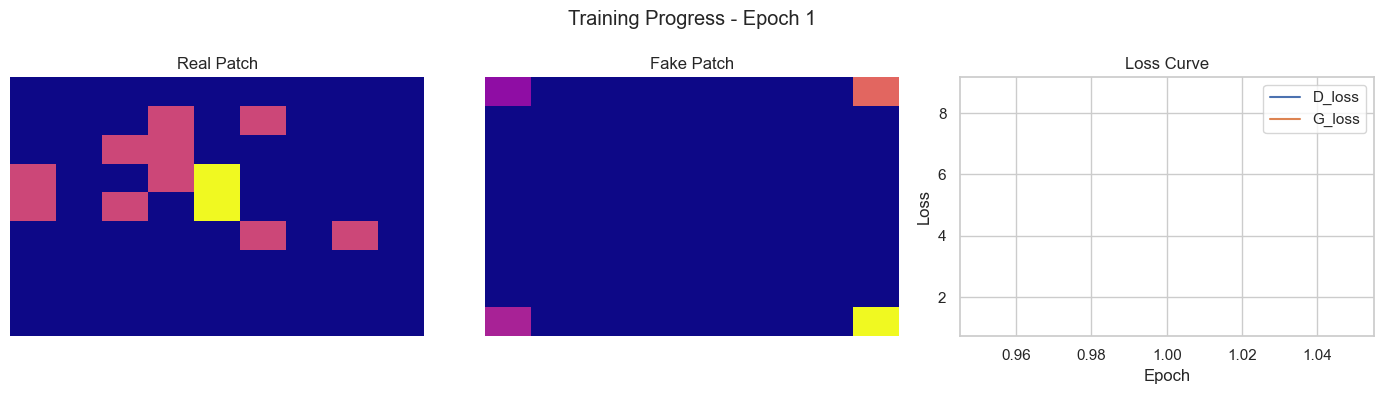

Epoch 2/100
Epoch 2/100 D_loss=0.3467 G_loss=6.2005 


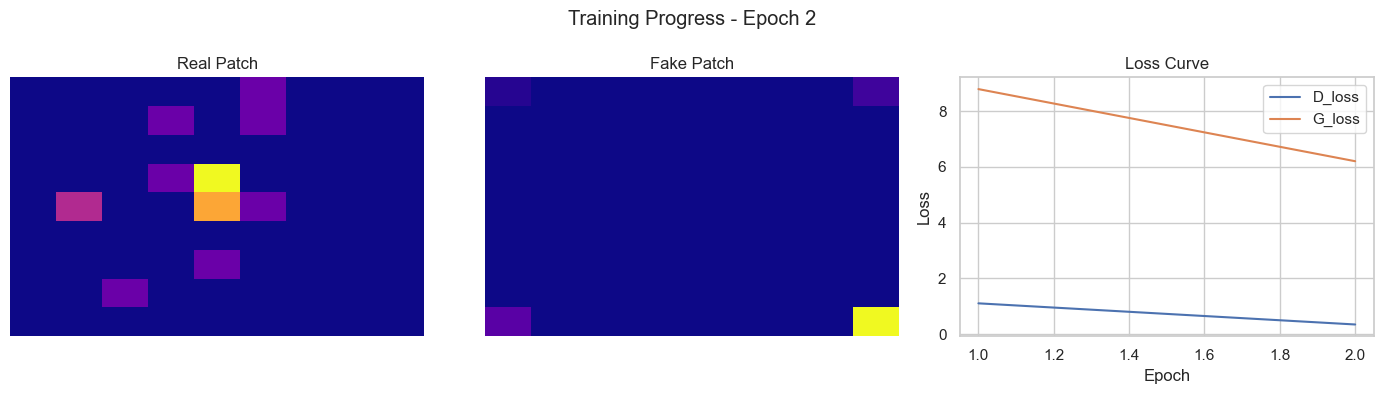

Epoch 3/100
Epoch 3/100 D_loss=0.1750 G_loss=8.4296 


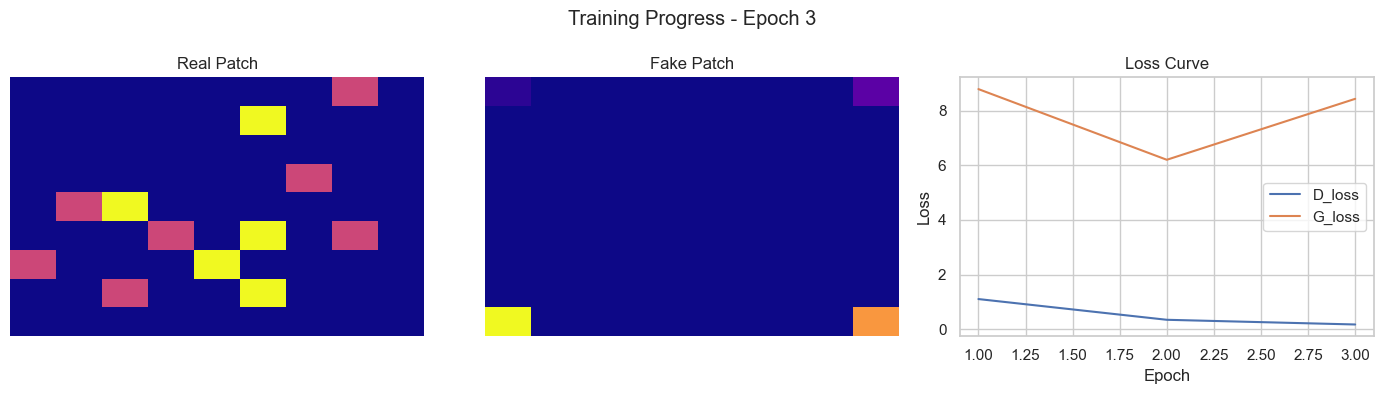

Epoch 4/100
Epoch 4/100 D_loss=0.1107 G_loss=10.1163 


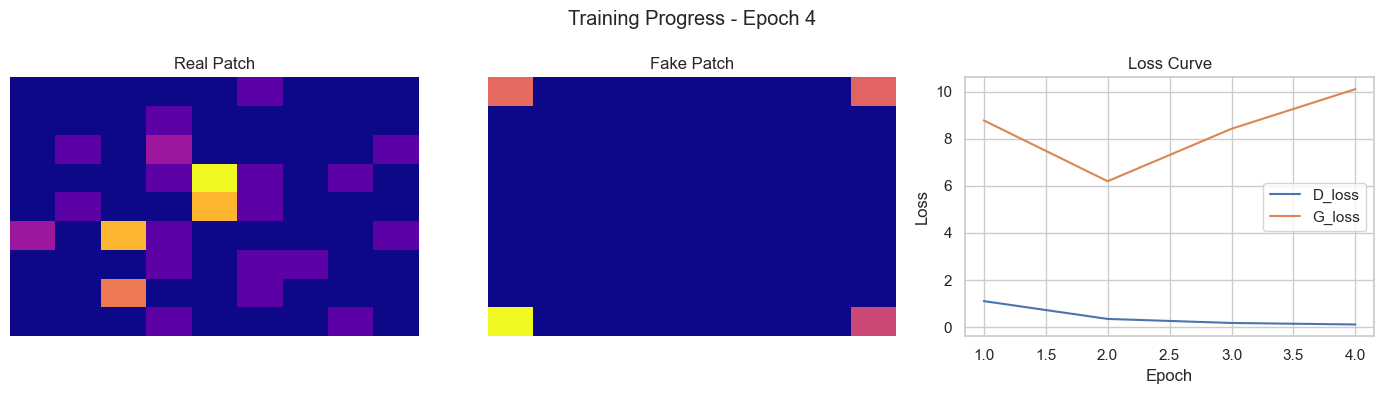

Epoch 5/100
Epoch 5/100 D_loss=0.0753 G_loss=11.7622 


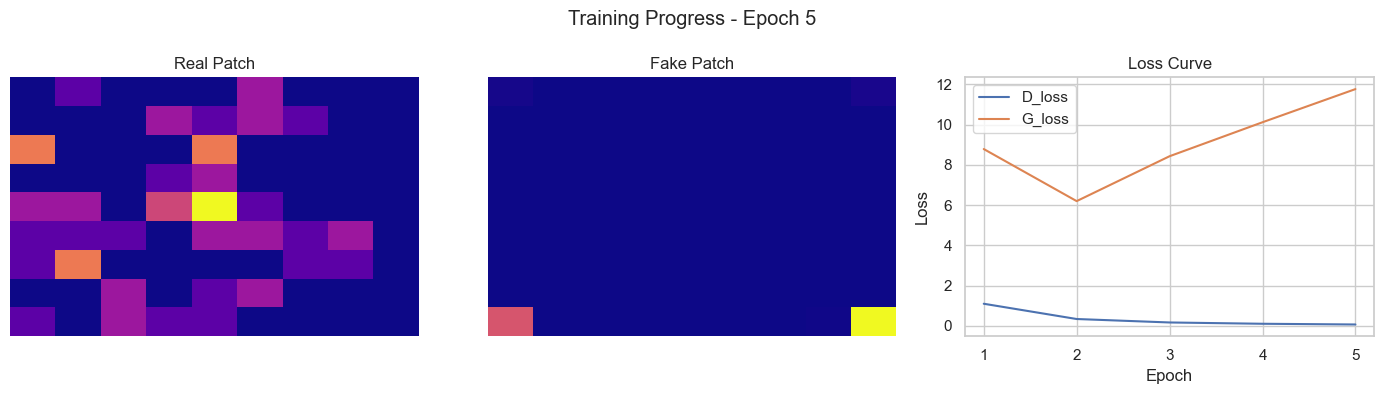

Epoch 6/100
Epoch 6/100 D_loss=0.0560 G_loss=13.0718 


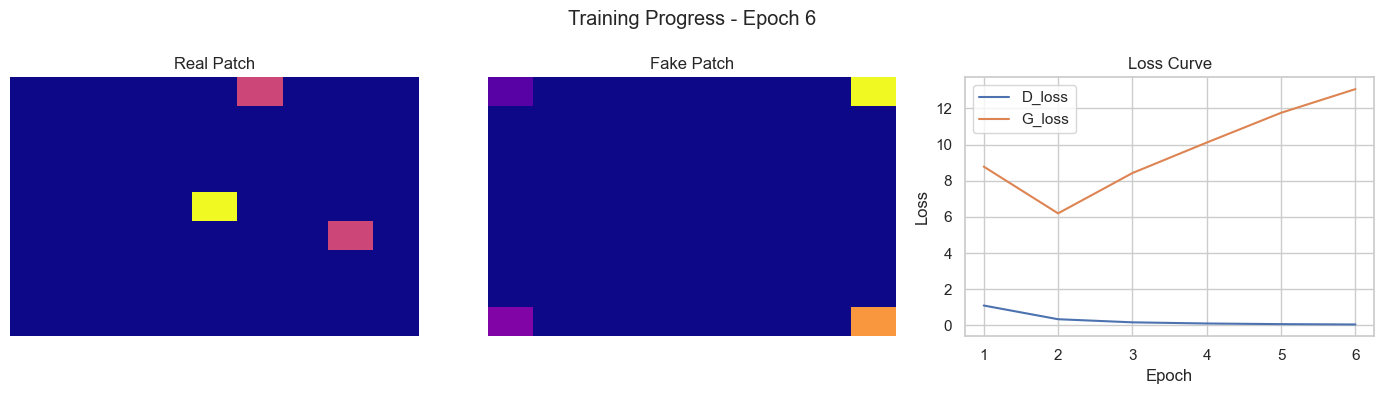

Epoch 7/100
Epoch 7/100 D_loss=0.0390 G_loss=14.1013 


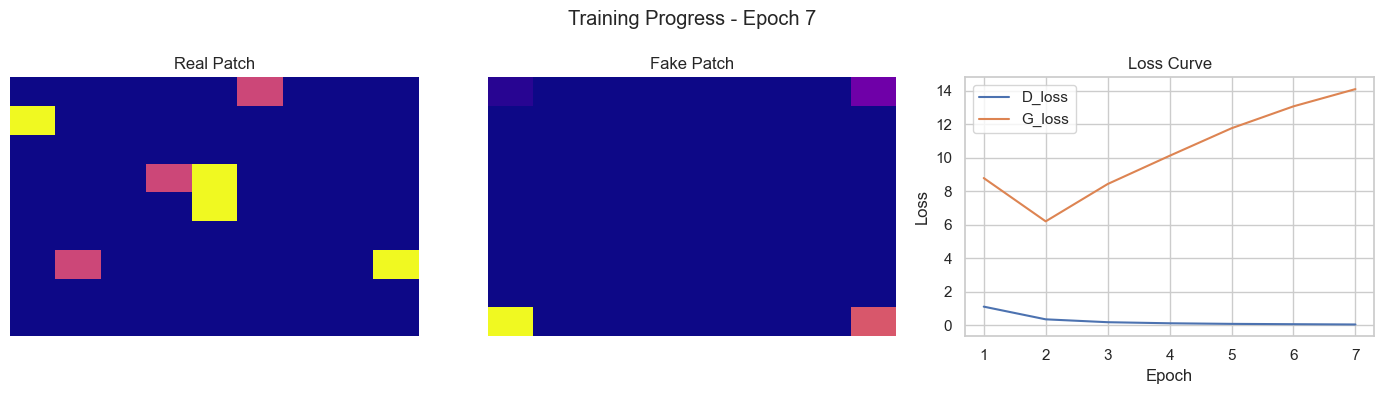

Epoch 8/100
Epoch 8/100 D_loss=0.0298 G_loss=15.5095 


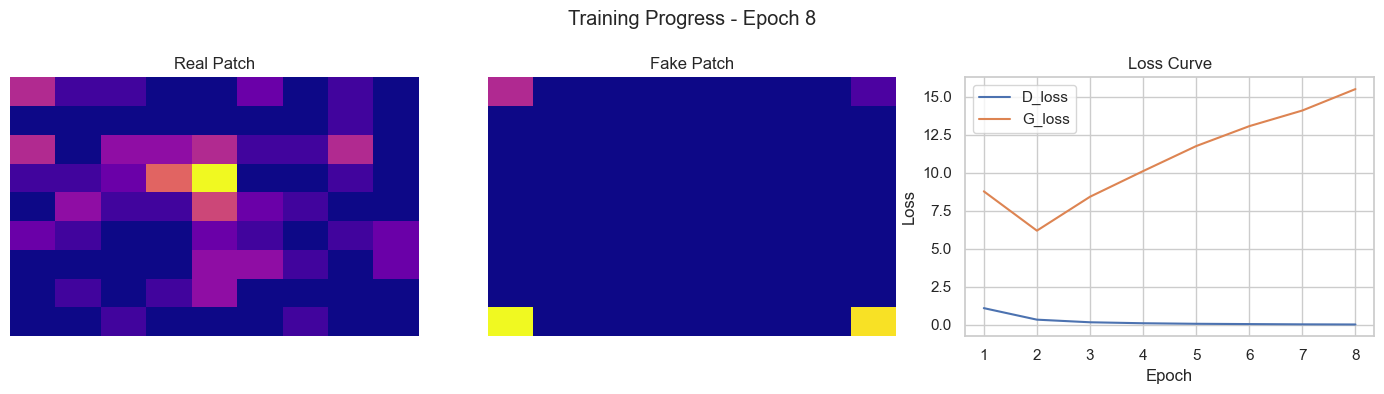

Epoch 9/100
Epoch 9/100 D_loss=0.0246 G_loss=16.6248 


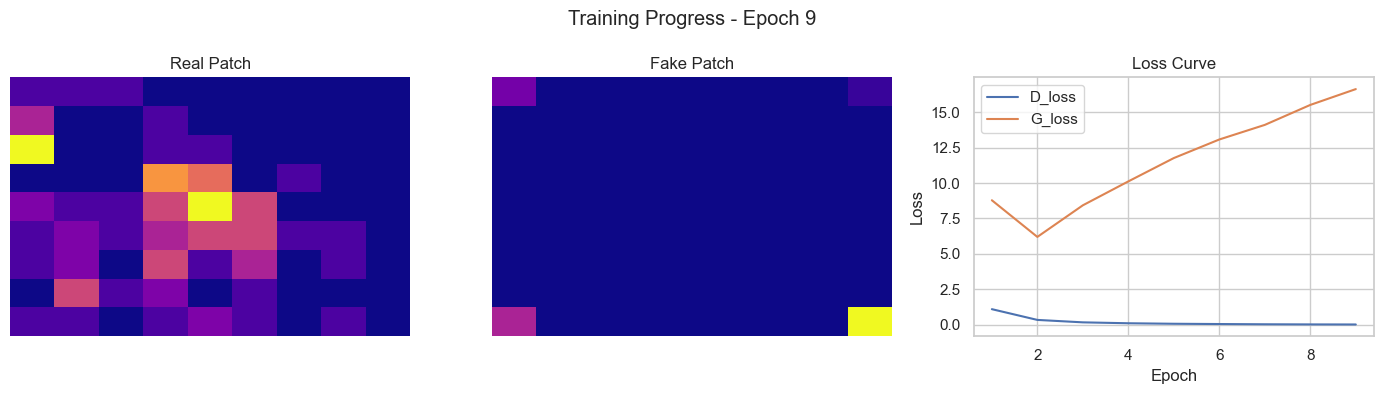

Epoch 10/100
Epoch 10/100 D_loss=0.0213 G_loss=17.6464 


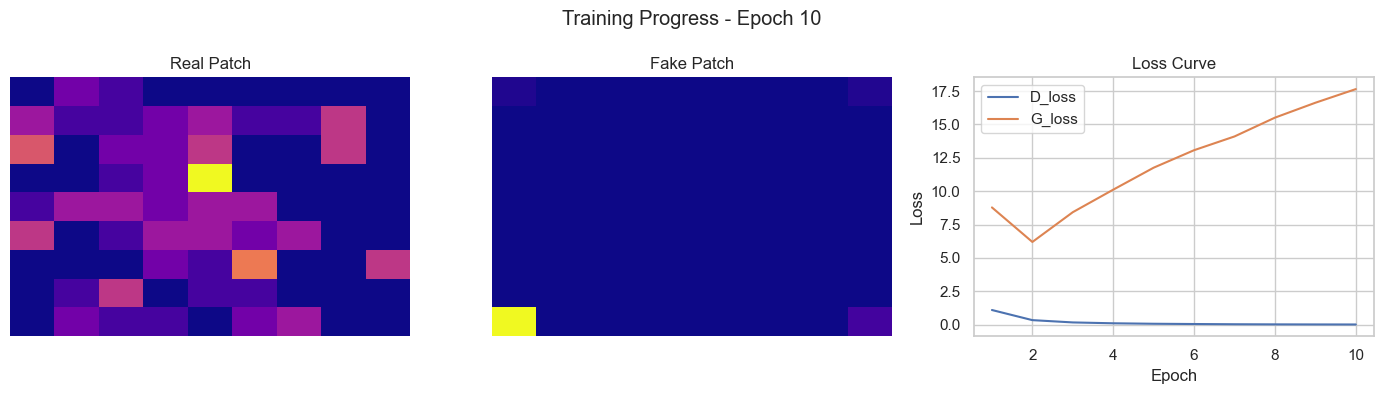

Epoch 11/100
Epoch 11/100 D_loss=0.0179 G_loss=17.4428 


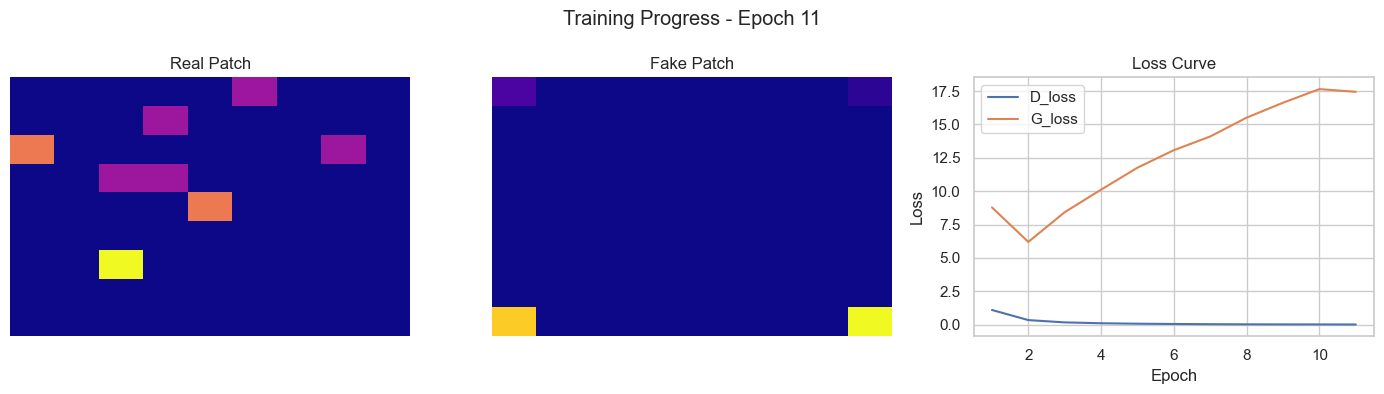

Epoch 12/100
Epoch 12/100 D_loss=0.0167 G_loss=19.1928 


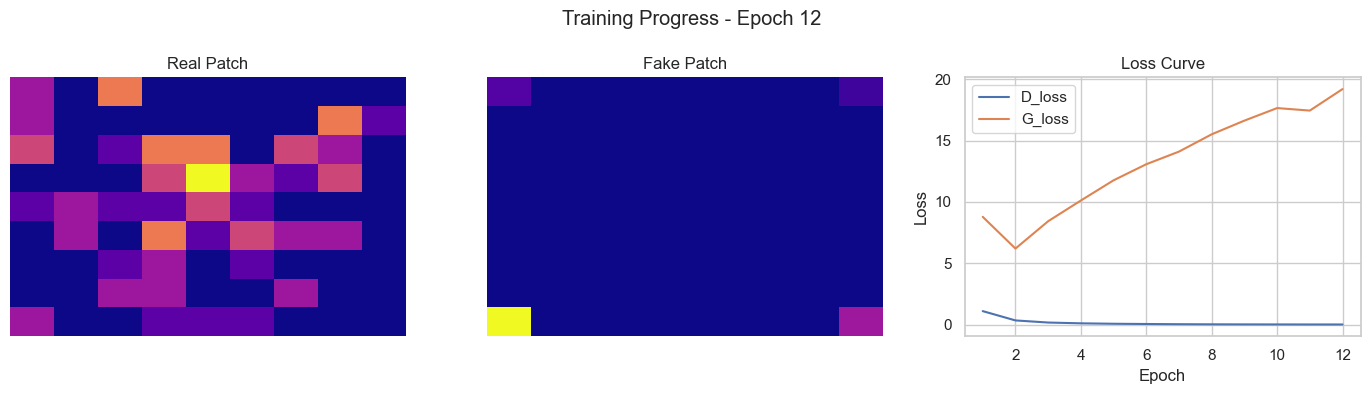

Epoch 13/100
Epoch 13/100 D_loss=0.0146 G_loss=18.6657 


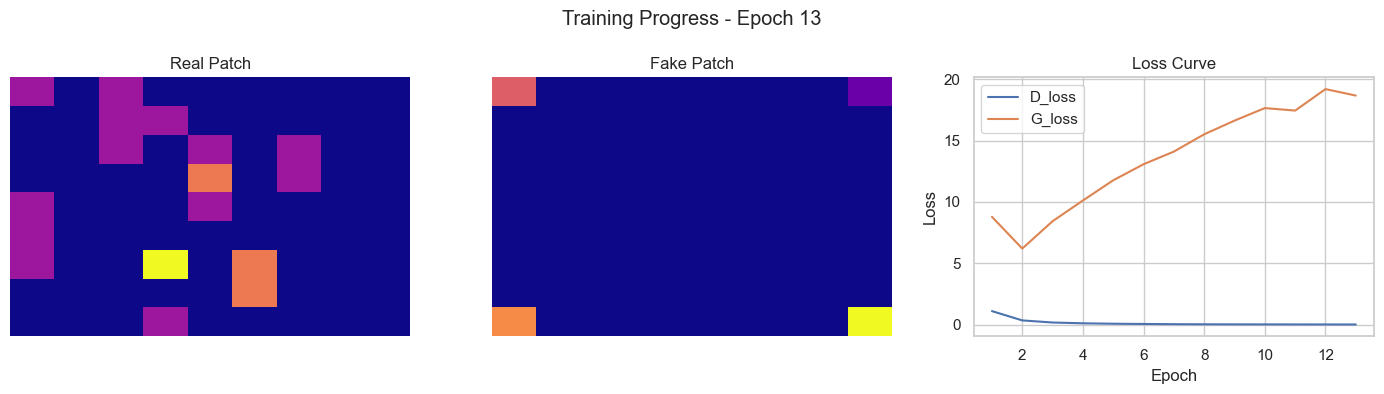

Epoch 14/100
Epoch 14/100 D_loss=0.0121 G_loss=18.9418 


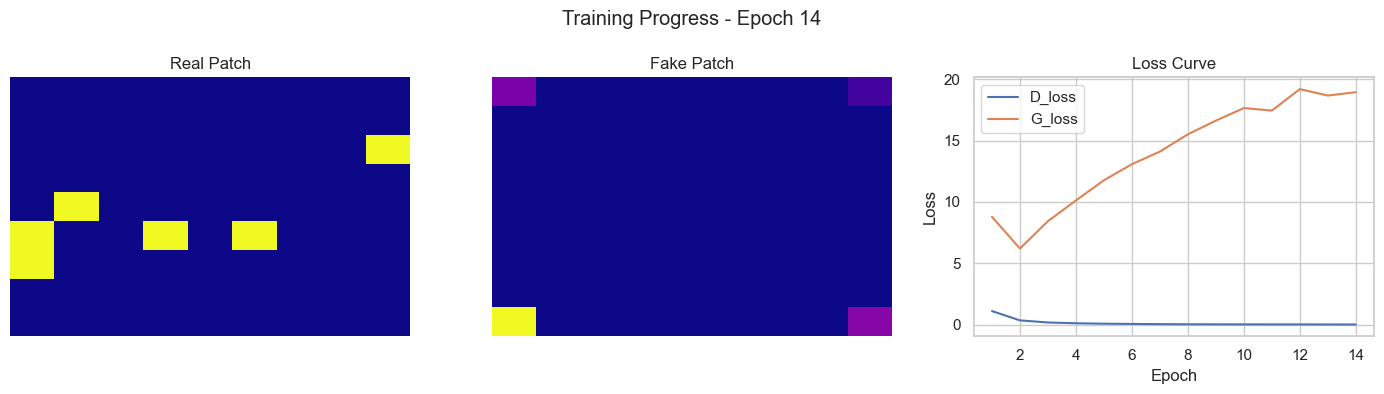

Epoch 15/100
Epoch 15/100 D_loss=0.0119 G_loss=19.3715 


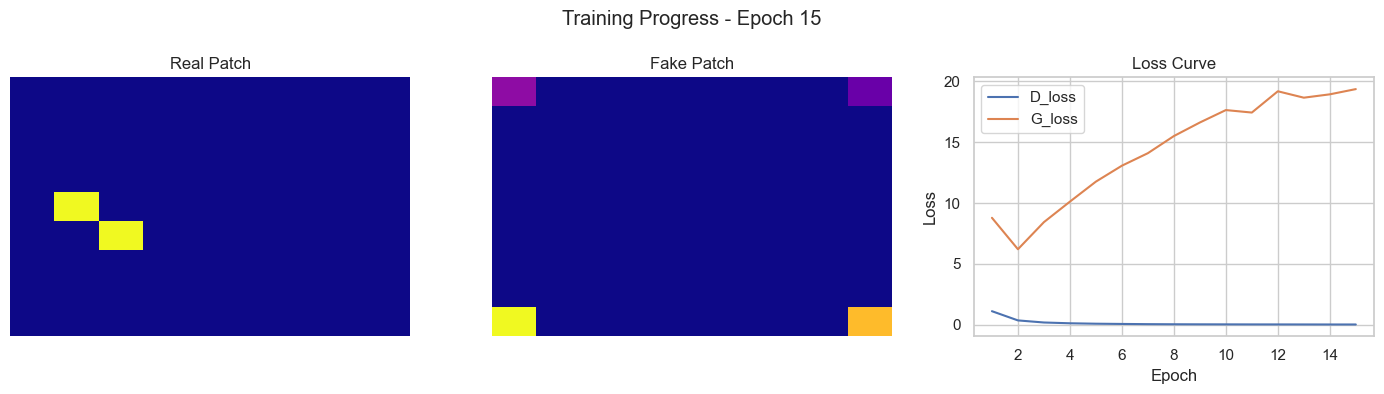

Epoch 16/100
Epoch 16/100 D_loss=8.4779 G_loss=22.7785 


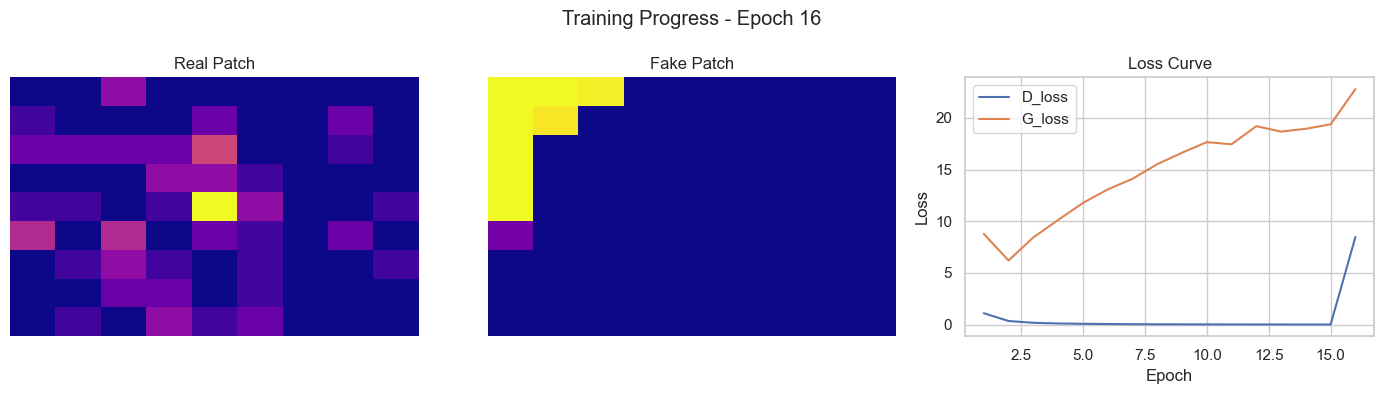

Epoch 17/100
Epoch 17/100 D_loss=0.2978 G_loss=7.5742 


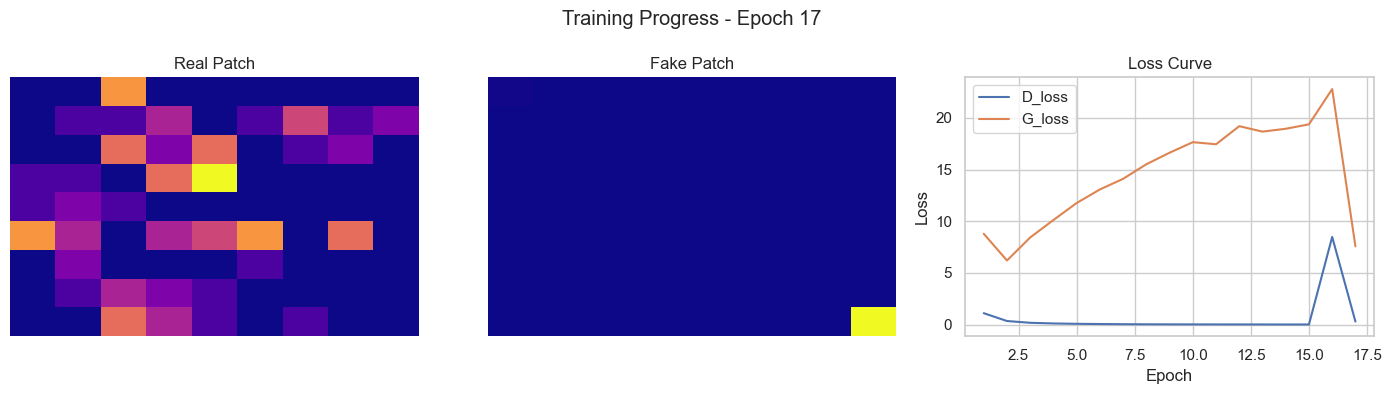

Epoch 18/100
Epoch 18/100 D_loss=0.1285 G_loss=8.6638 


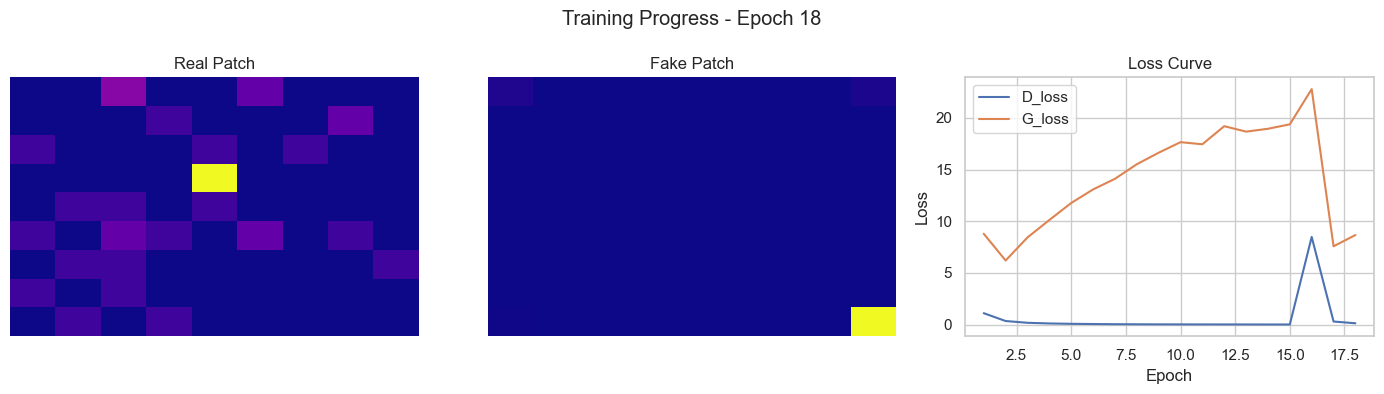

Epoch 19/100
Epoch 19/100 D_loss=0.1043 G_loss=9.4409 


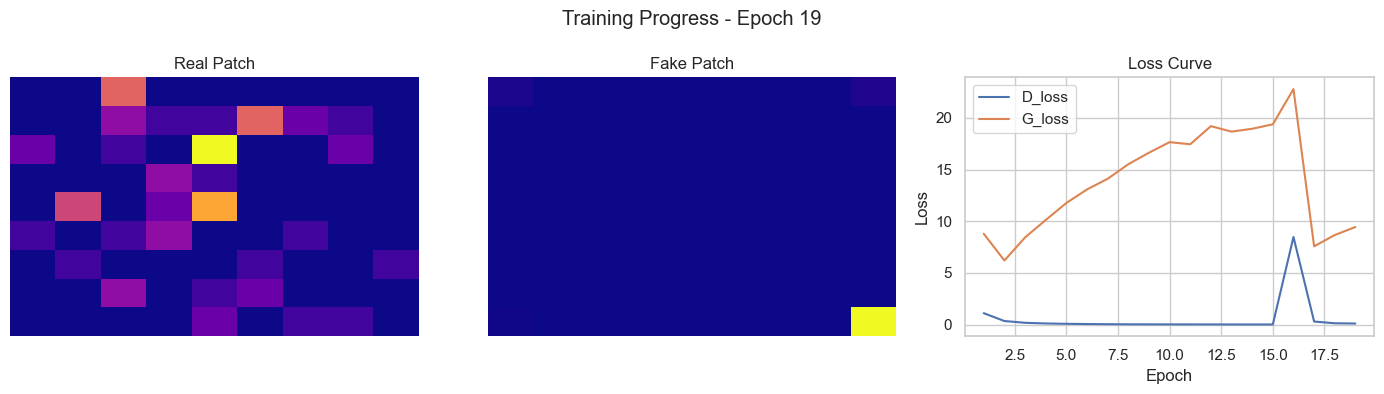

Epoch 20/100
Epoch 20/100 D_loss=0.0853 G_loss=10.0216 


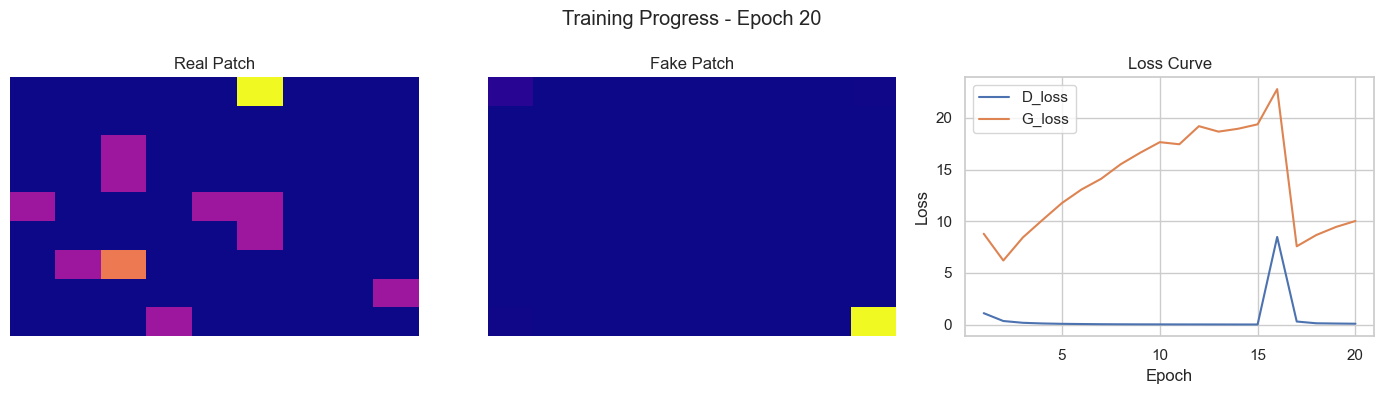

Epoch 21/100
Epoch 21/100 D_loss=0.0761 G_loss=10.6133 


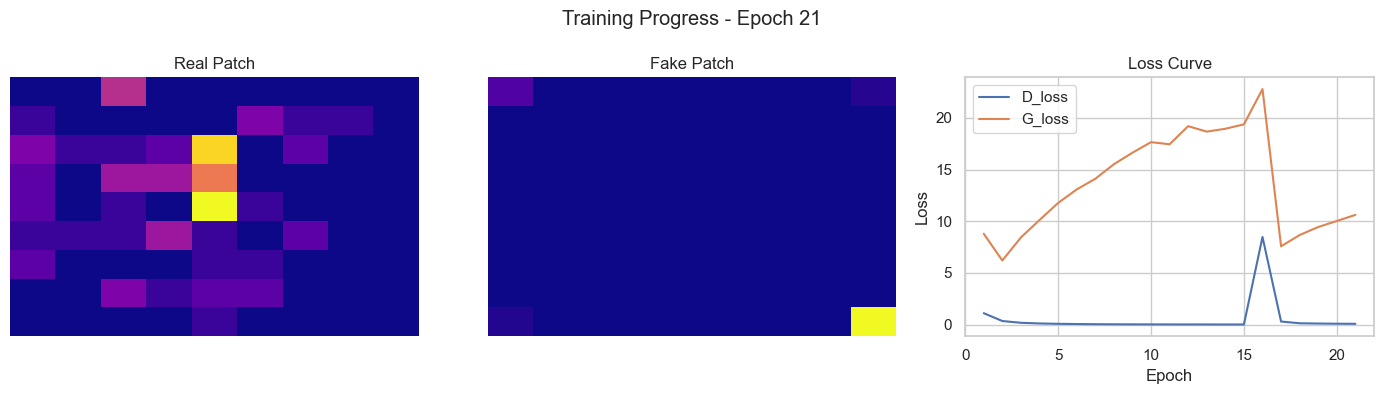

Epoch 22/100
Epoch 22/100 D_loss=0.0627 G_loss=11.0514 


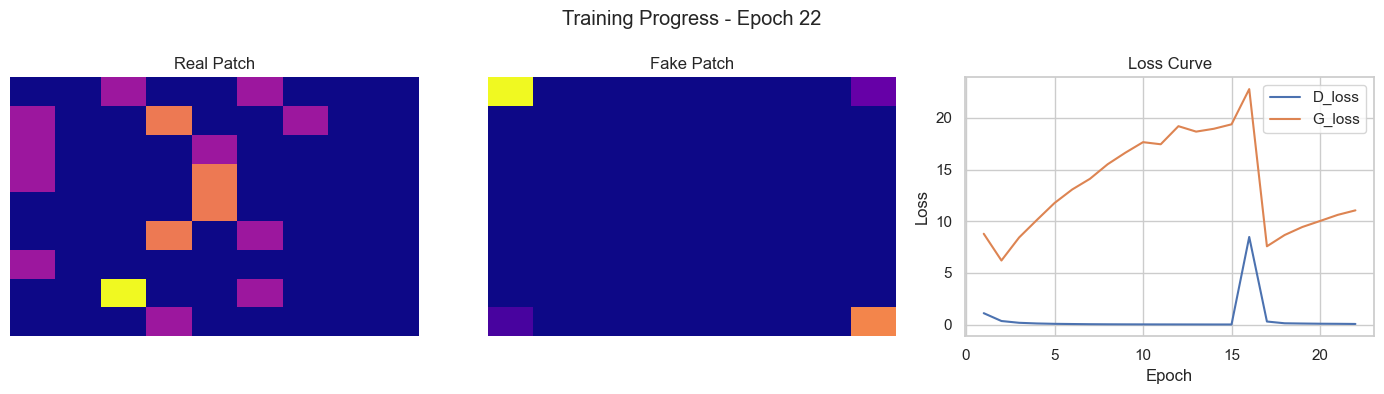

Epoch 23/100
Epoch 23/100 D_loss=0.0515 G_loss=11.4670 


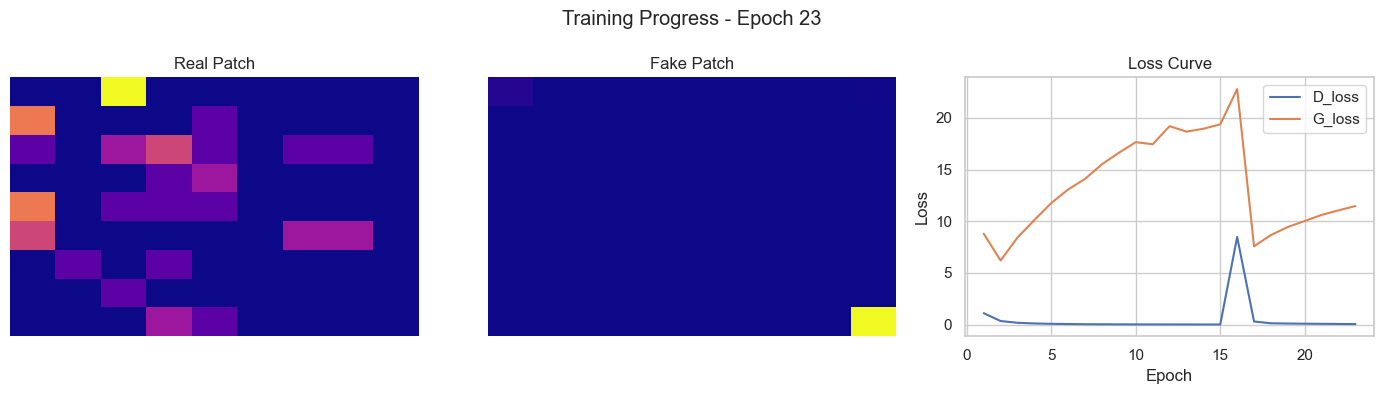

Epoch 24/100
Epoch 24/100 D_loss=0.0478 G_loss=12.0138 


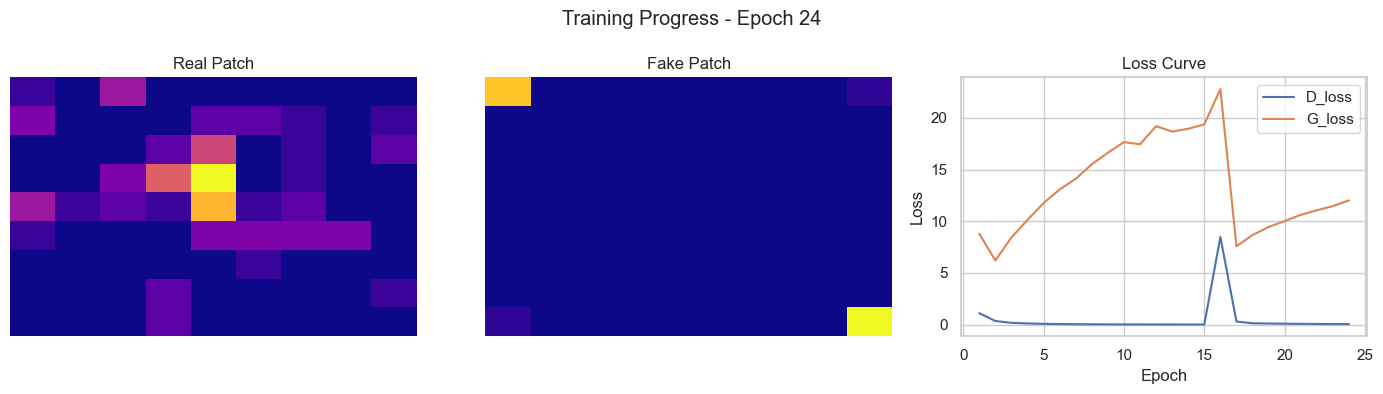

Epoch 25/100
Epoch 25/100 D_loss=0.0404 G_loss=12.4873 


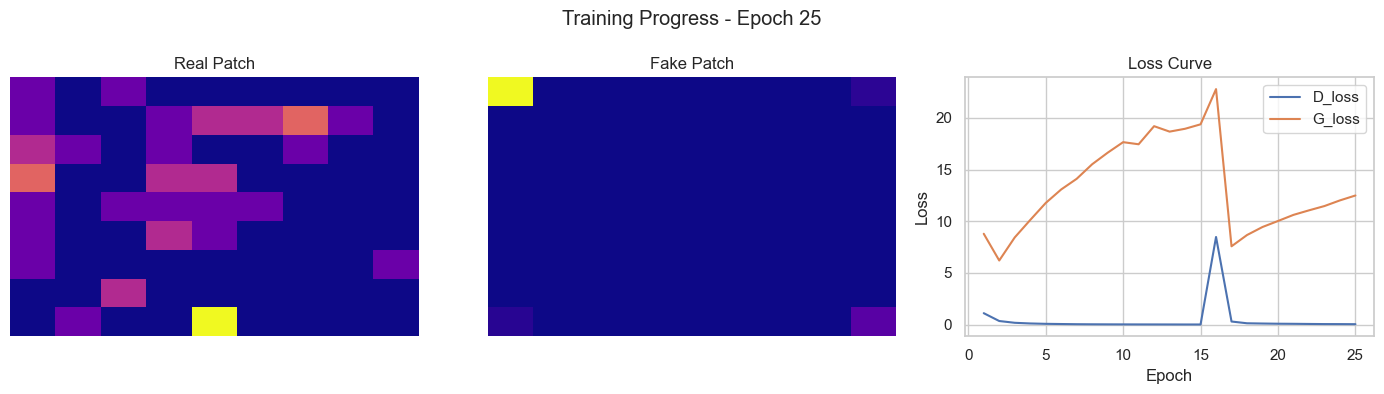

Epoch 26/100
Epoch 26/100 D_loss=0.0370 G_loss=12.8543 


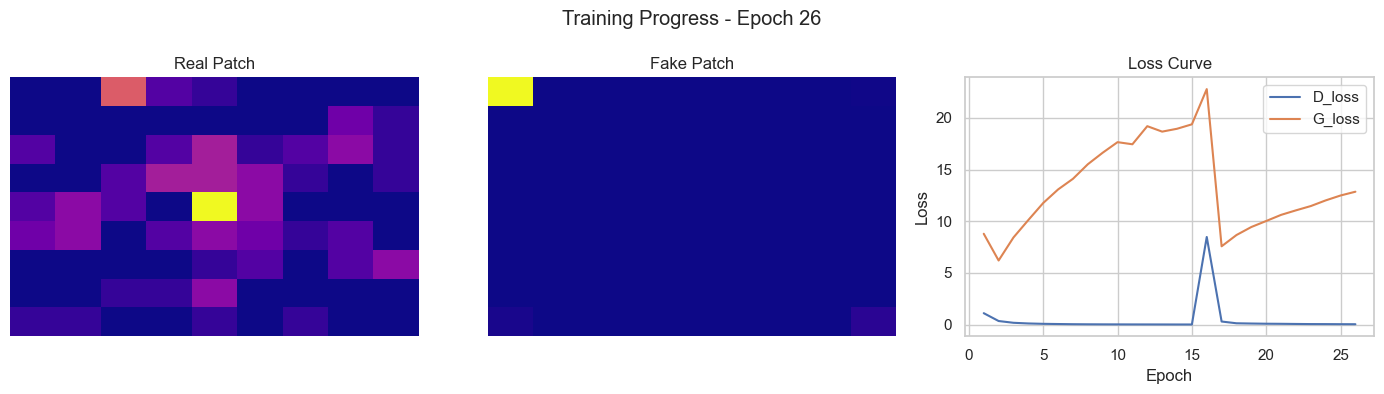

Epoch 27/100
Epoch 27/100 D_loss=0.0335 G_loss=13.2850 


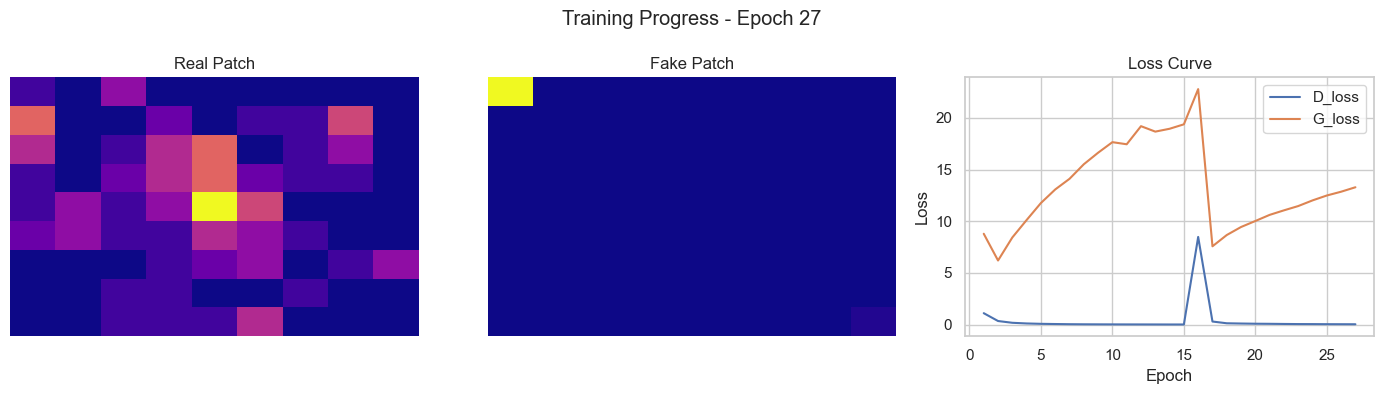

Epoch 28/100
Epoch 28/100 D_loss=0.0311 G_loss=13.7668 


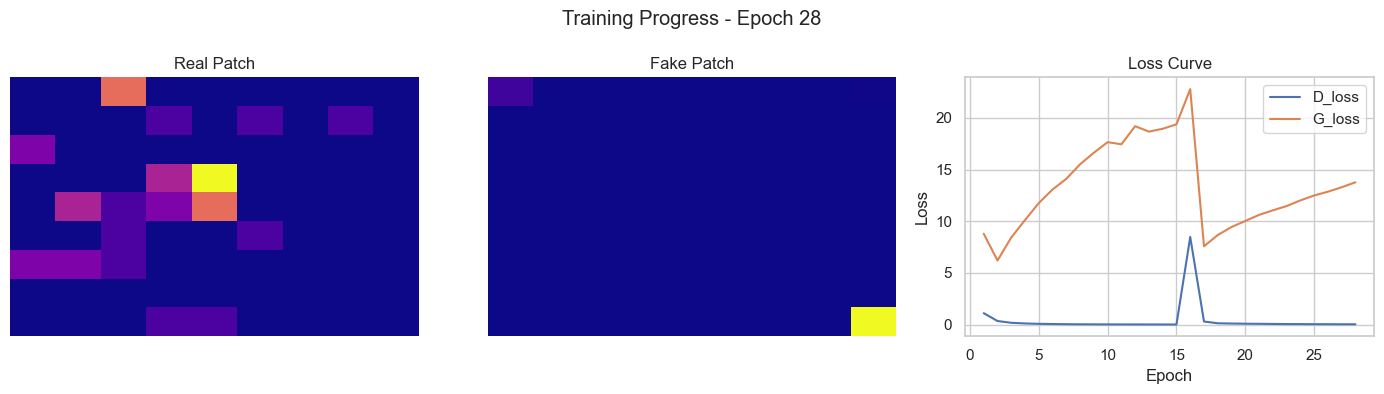

Epoch 29/100
Epoch 29/100 D_loss=0.0290 G_loss=13.9929 


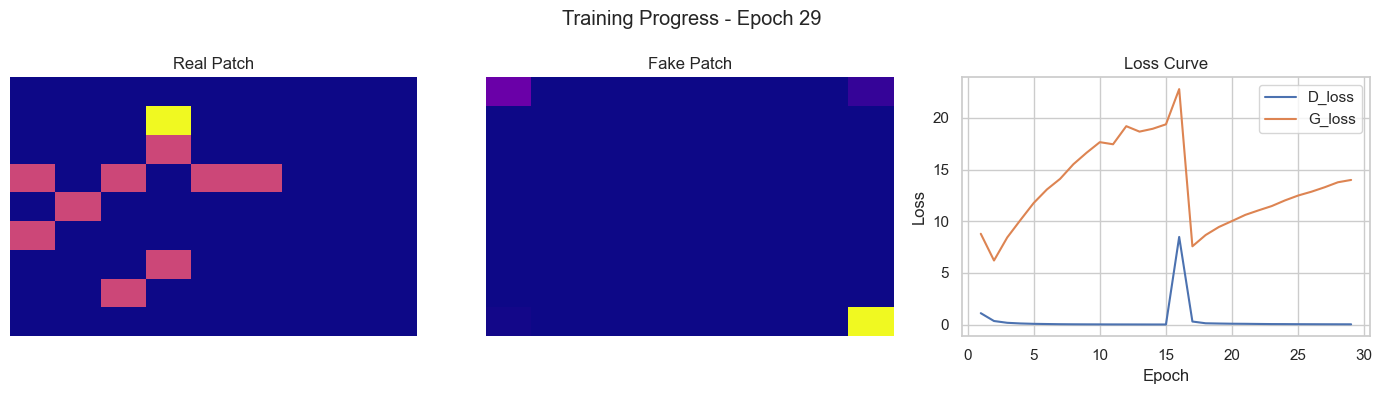

Epoch 30/100
Epoch 30/100 D_loss=0.0259 G_loss=14.4745 


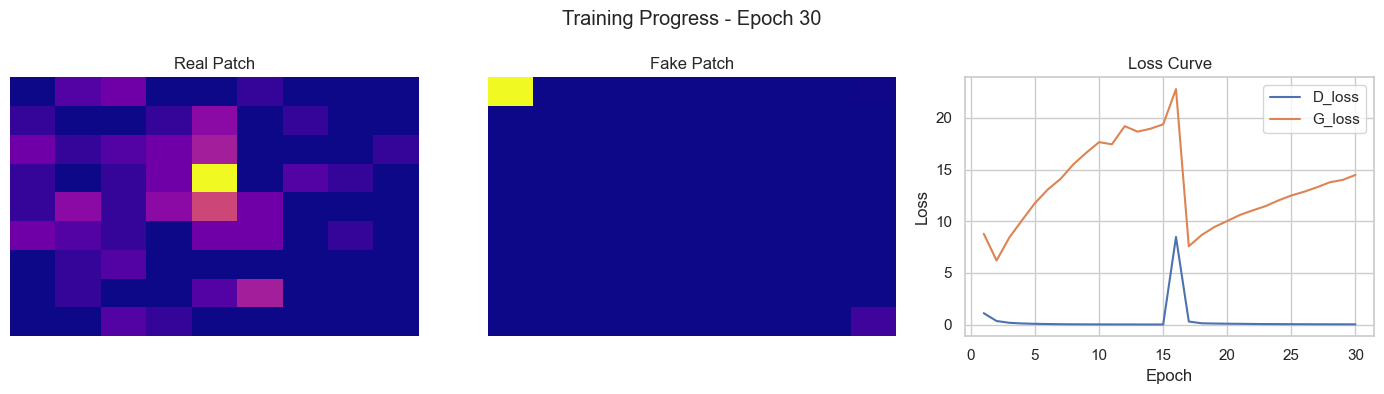

Epoch 31/100
Epoch 31/100 D_loss=0.0249 G_loss=14.7250 


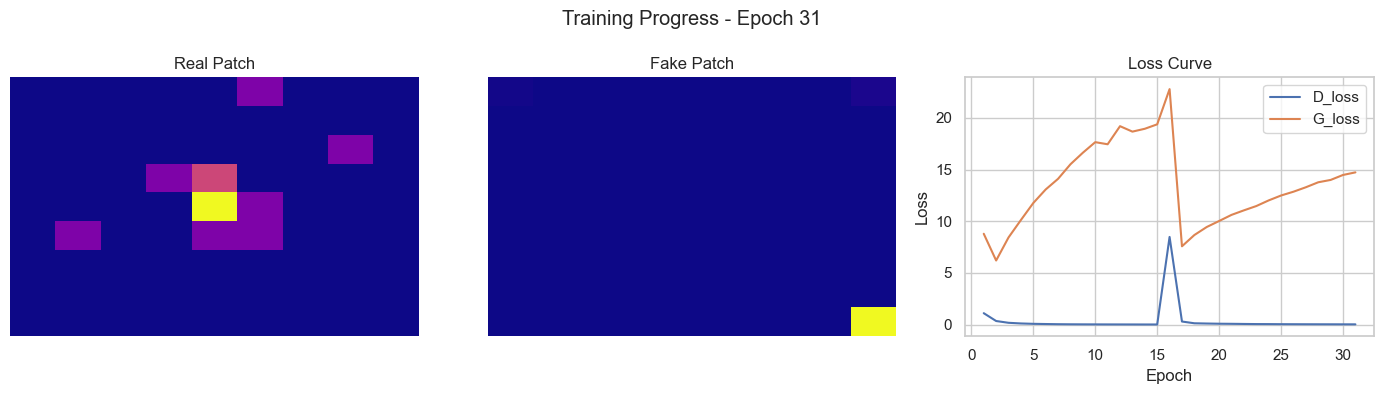

Epoch 32/100
Epoch 32/100 D_loss=0.0235 G_loss=15.2530 


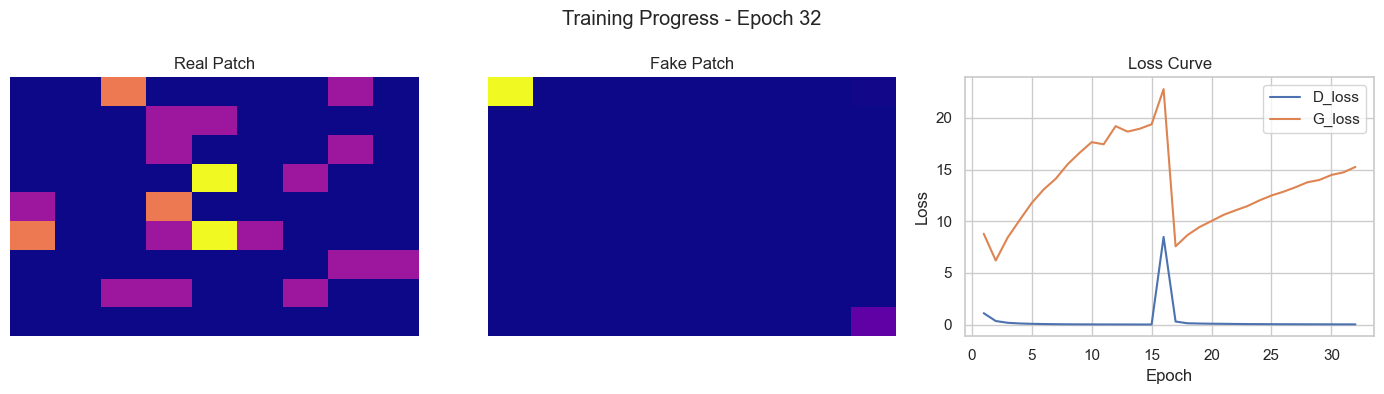

Epoch 33/100
Epoch 33/100 D_loss=0.0229 G_loss=15.5960 


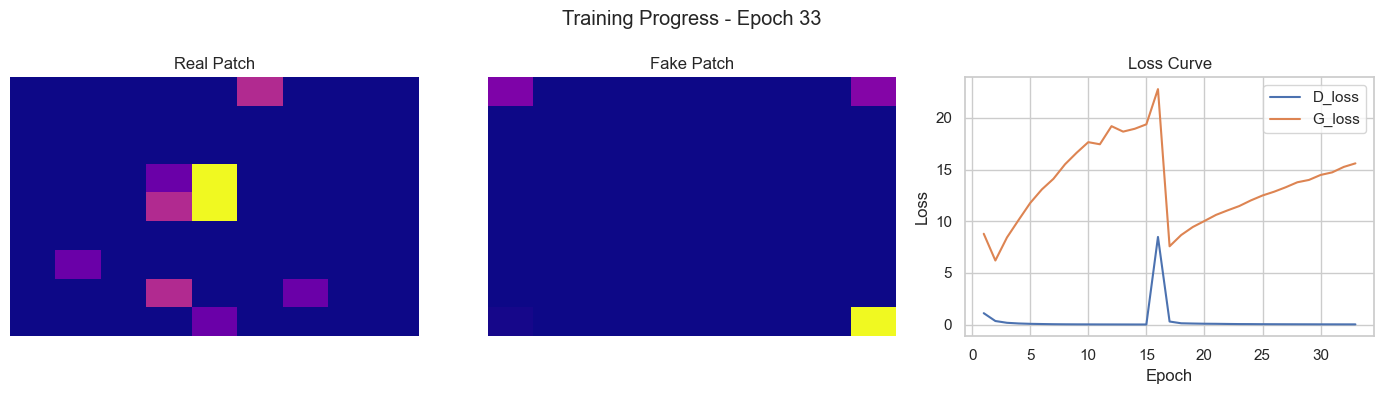

Epoch 34/100
Epoch 34/100 D_loss=0.0213 G_loss=15.7199 


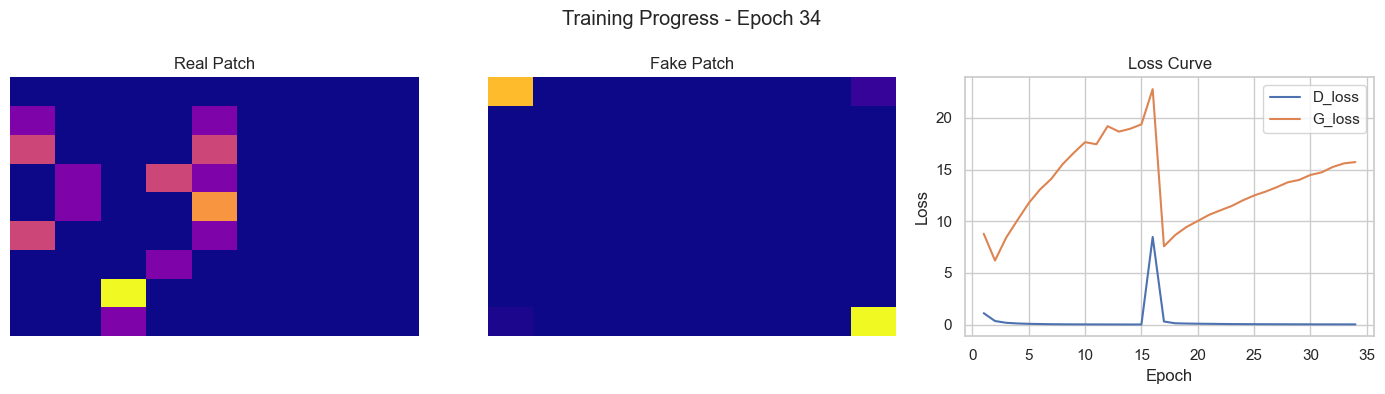

Epoch 35/100
Epoch 35/100 D_loss=0.0189 G_loss=16.0253 


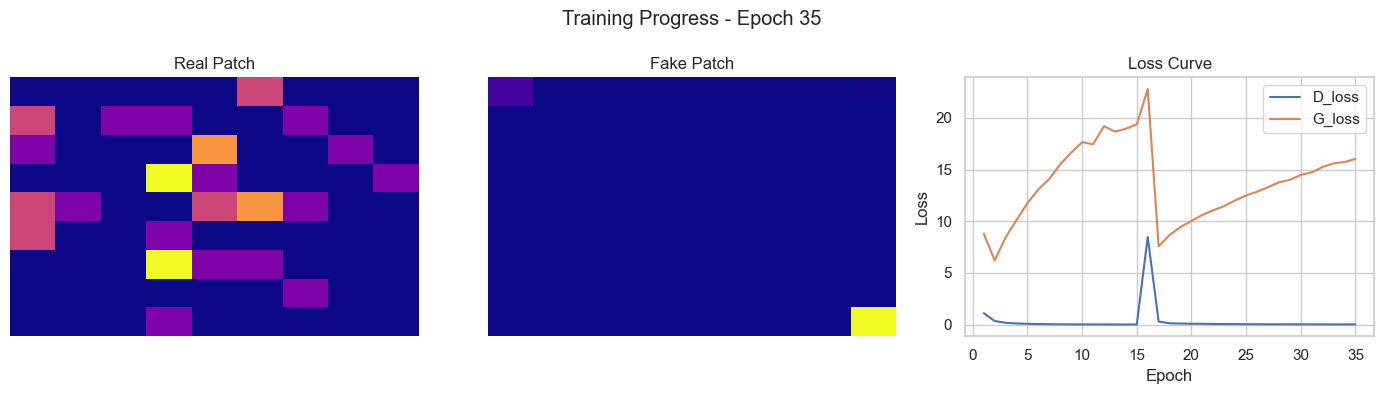

Epoch 36/100
Epoch 36/100 D_loss=0.0176 G_loss=16.4547 


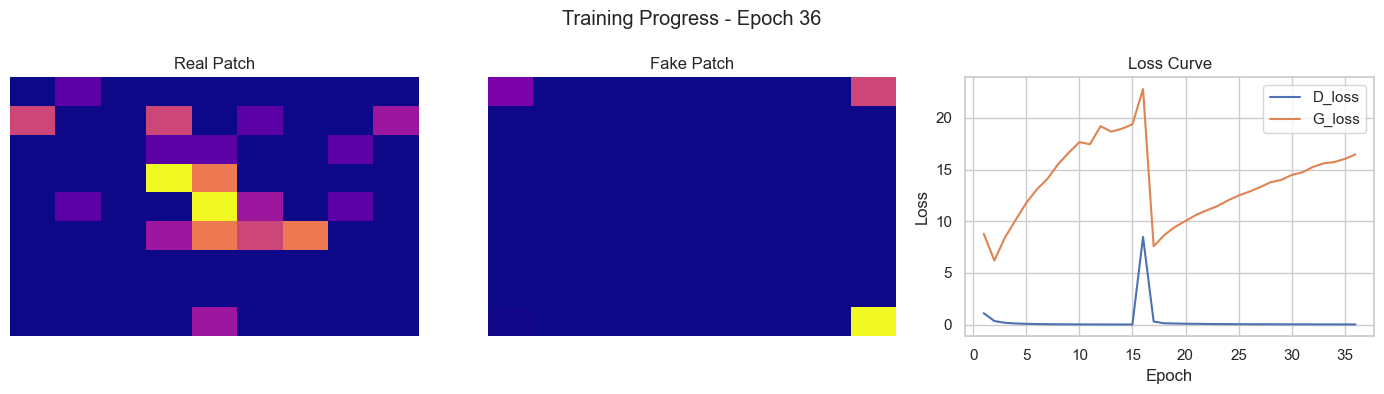

Epoch 37/100
Epoch 37/100 D_loss=0.0171 G_loss=16.7972 


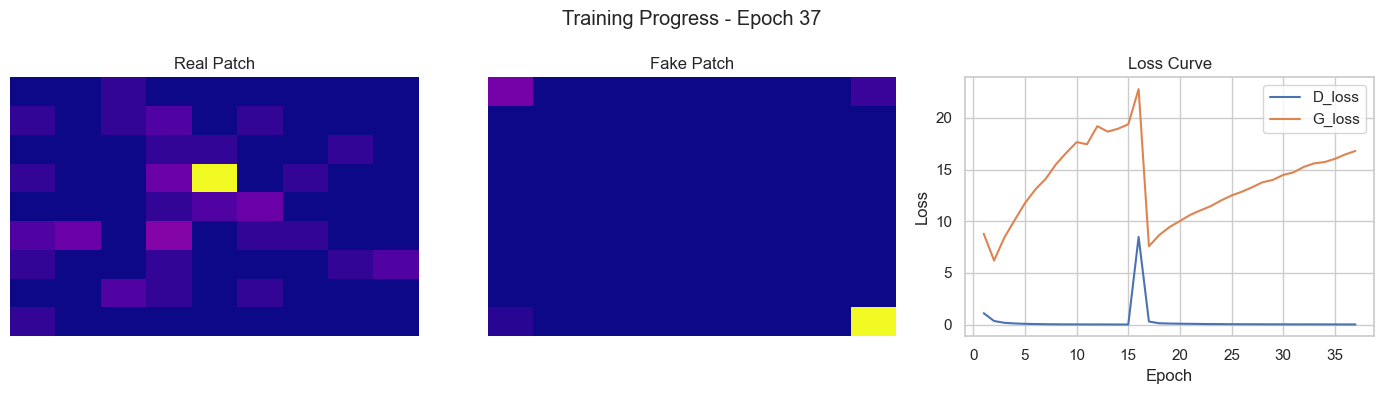

Epoch 38/100
Epoch 38/100 D_loss=0.0206 G_loss=16.8985 


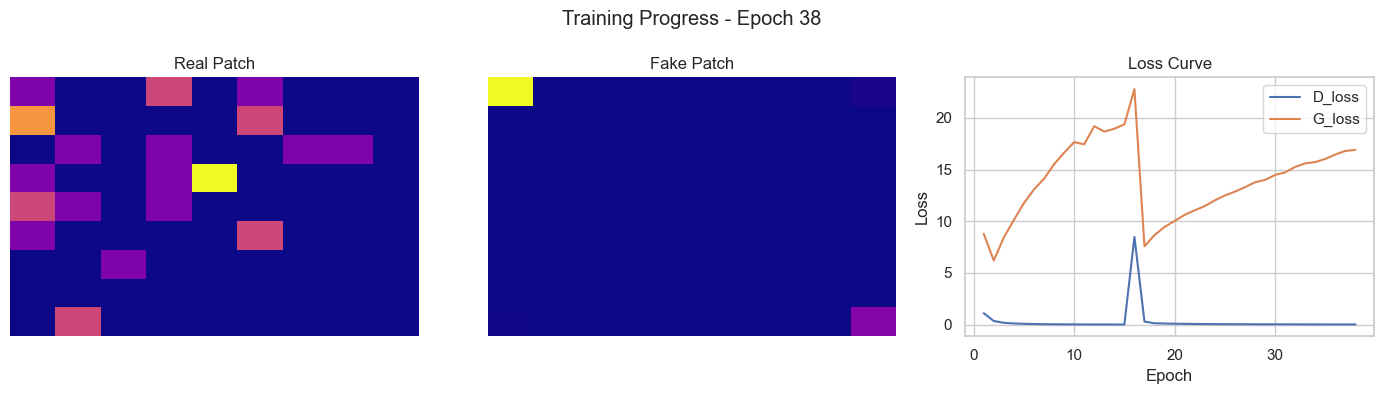

Epoch 39/100
Epoch 39/100 D_loss=0.0194 G_loss=17.0080 


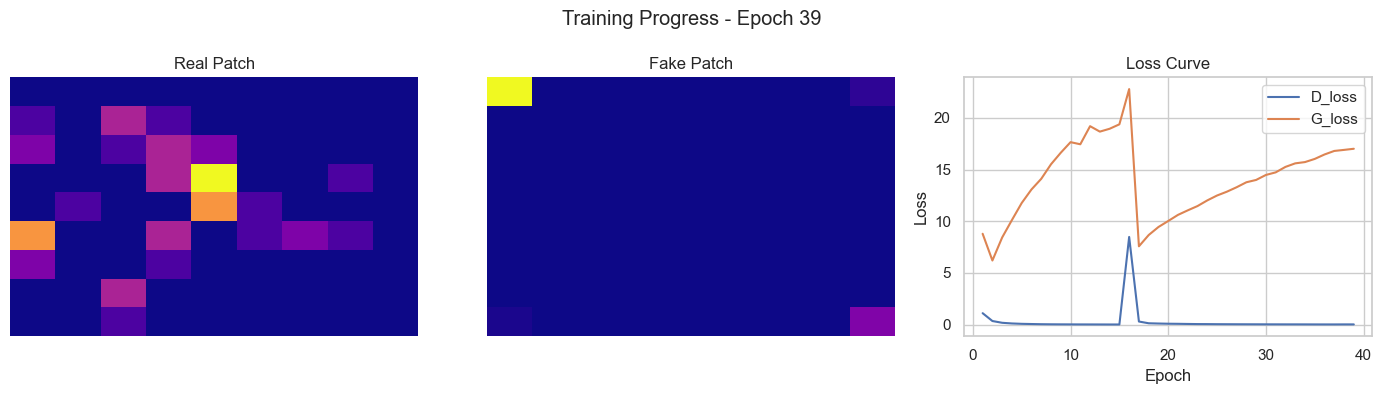

Epoch 40/100
Epoch 40/100 D_loss=0.0195 G_loss=17.0858 


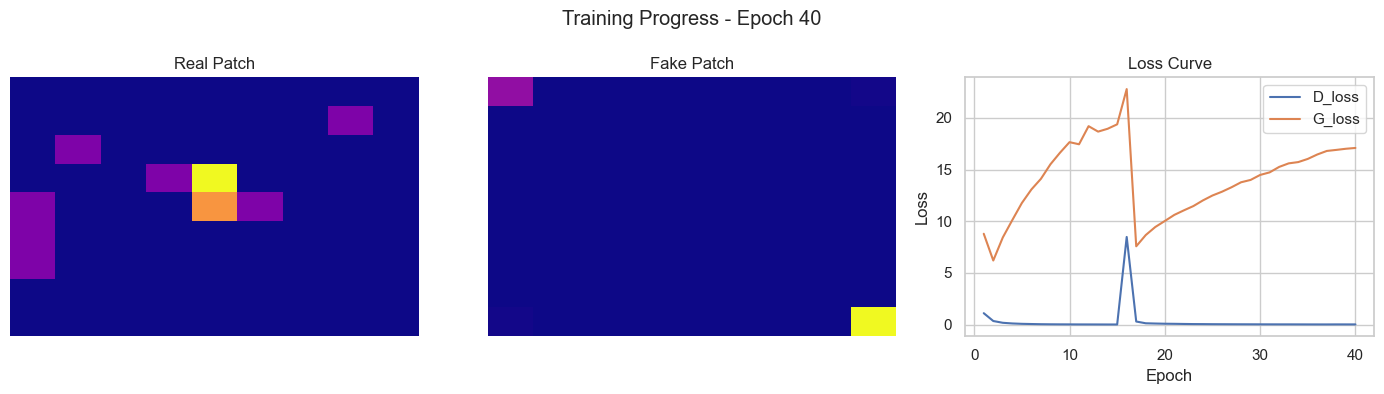

Epoch 41/100
Epoch 41/100 D_loss=0.0155 G_loss=17.0478 


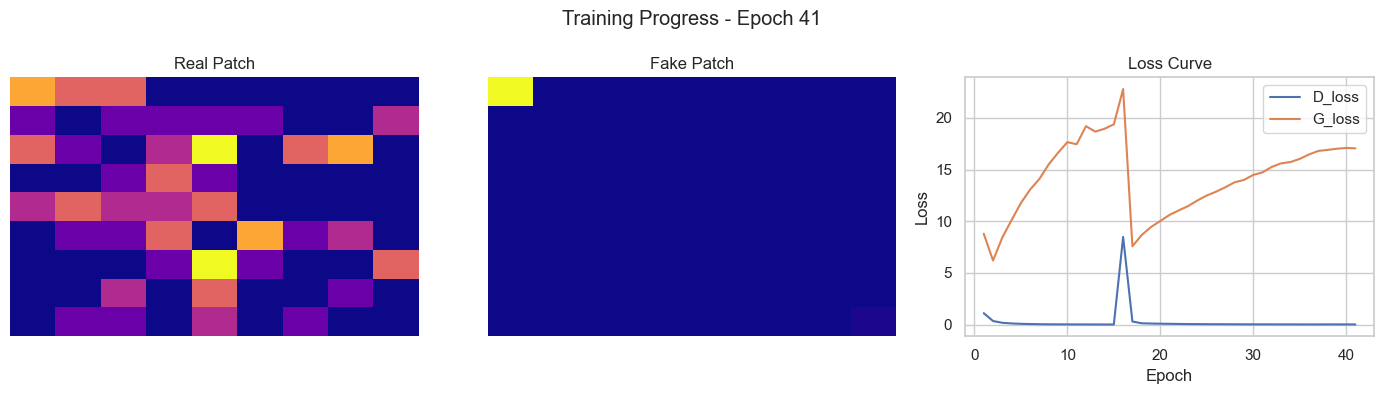

Epoch 42/100
Epoch 42/100 D_loss=0.0147 G_loss=17.4306 


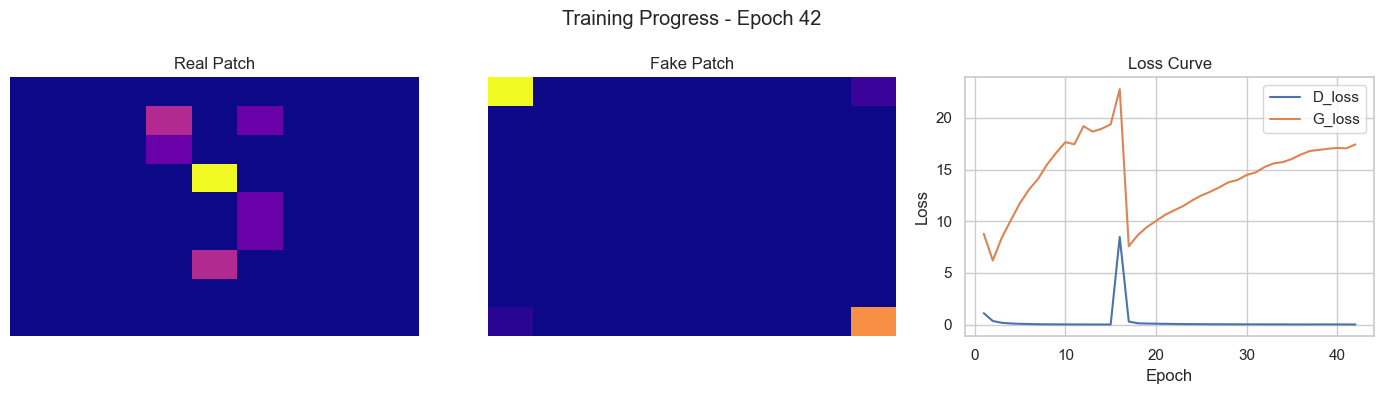

Epoch 43/100
Epoch 43/100 D_loss=0.0130 G_loss=17.7539 


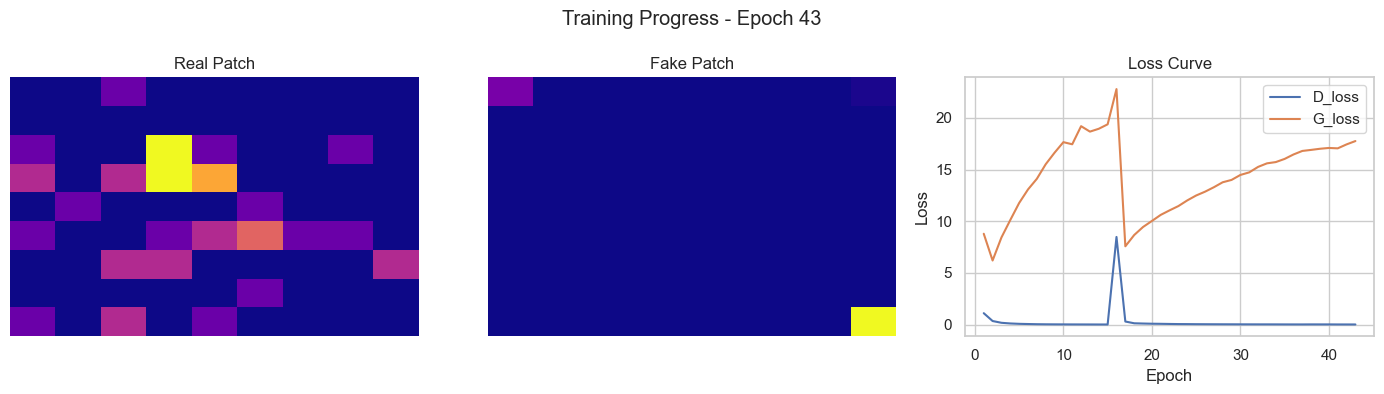

Epoch 44/100
Epoch 44/100 D_loss=0.0134 G_loss=17.8595 


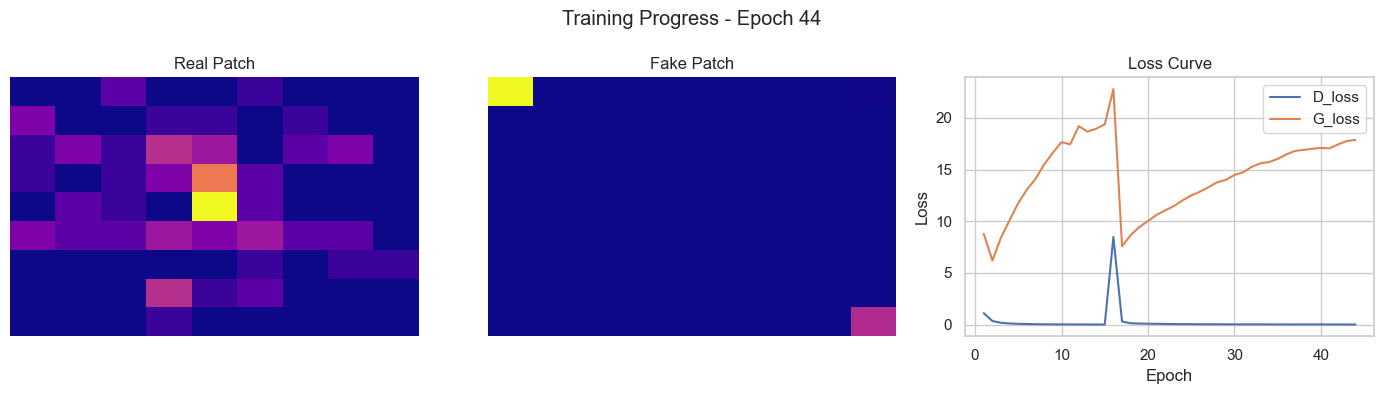

Epoch 45/100
Epoch 45/100 D_loss=0.0137 G_loss=18.0653 


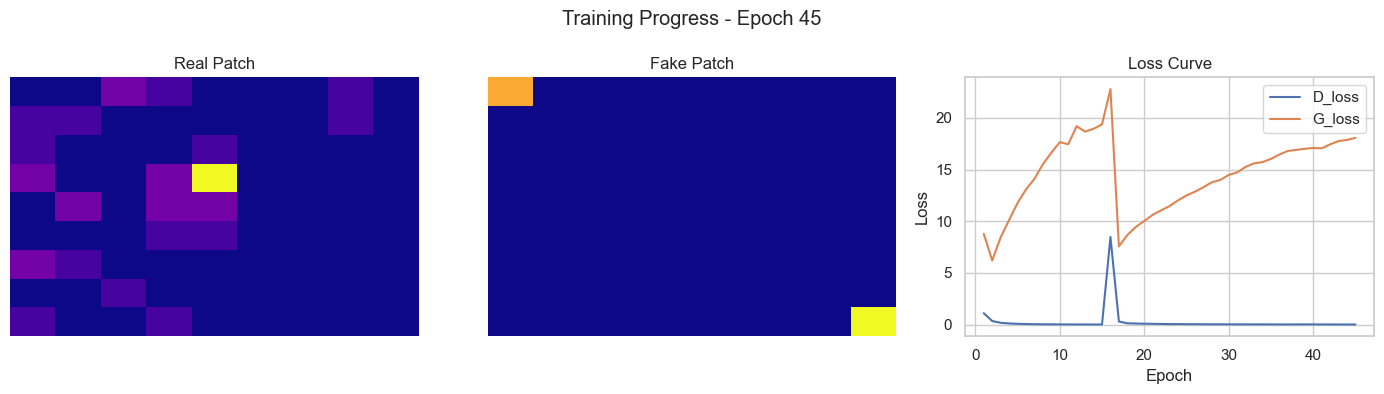

Epoch 46/100
Epoch 46/100 D_loss=0.0147 G_loss=18.4239 


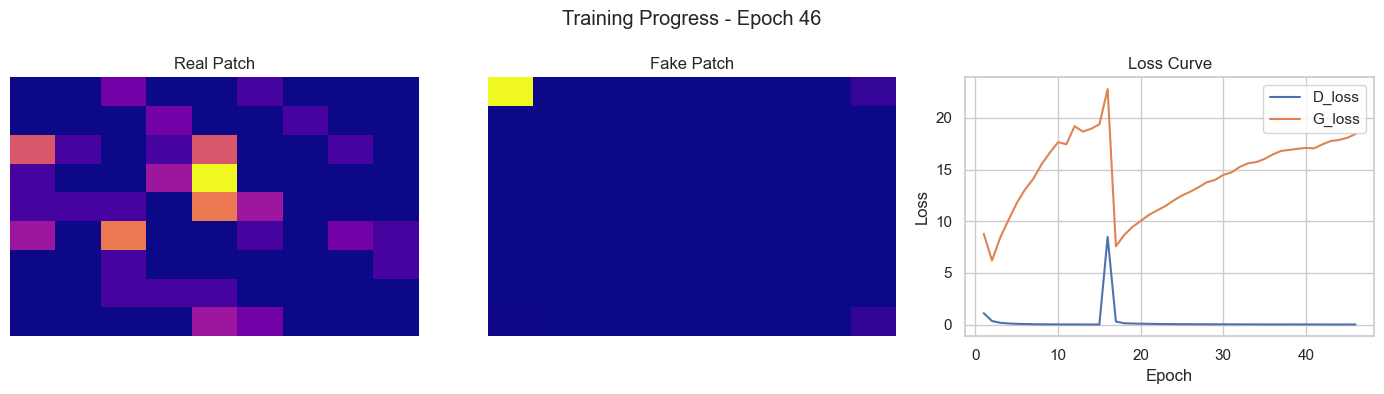

Epoch 47/100
Epoch 47/100 D_loss=0.0126 G_loss=17.8962 


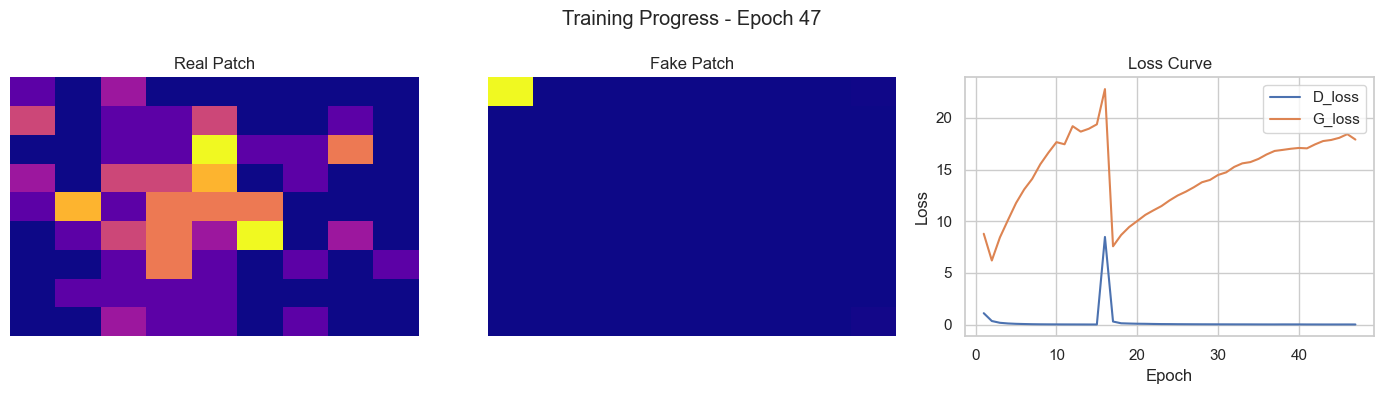

Epoch 48/100
Epoch 48/100 D_loss=0.0112 G_loss=17.9787 


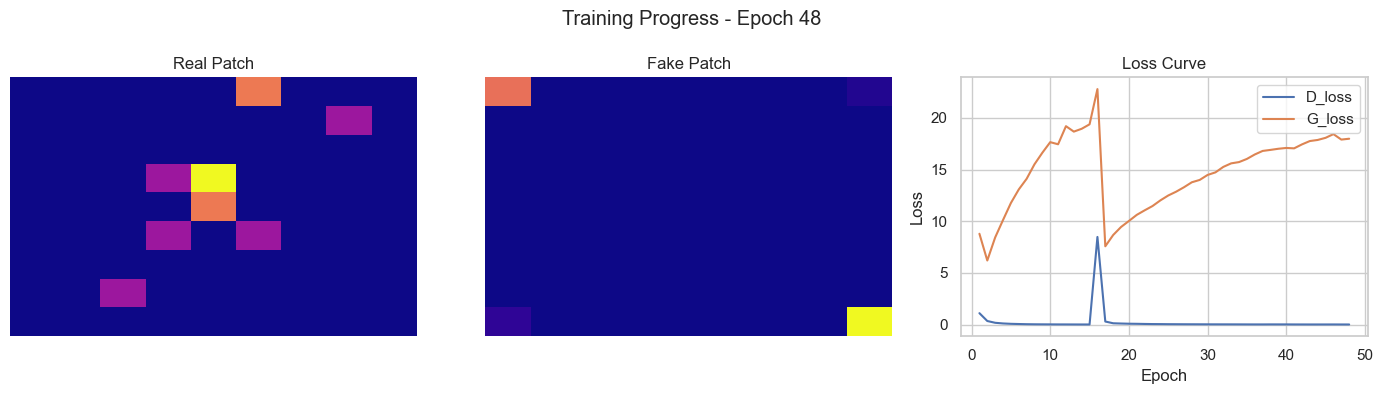

Epoch 49/100
Epoch 49/100 D_loss=0.0110 G_loss=18.5761 


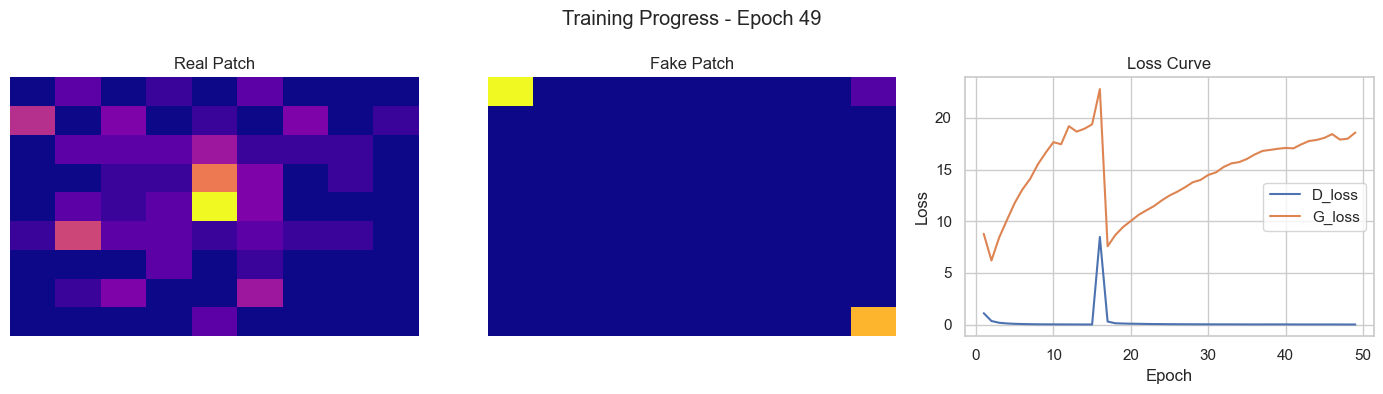

Epoch 50/100
Epoch 50/100 D_loss=0.0133 G_loss=18.9151 


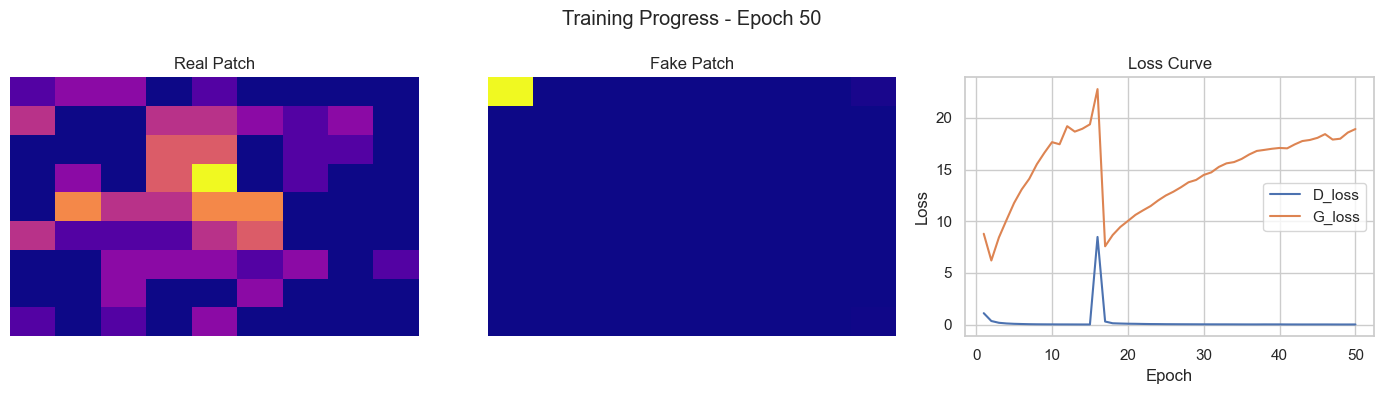

Epoch 51/100
Epoch 51/100 D_loss=0.0140 G_loss=18.5722 


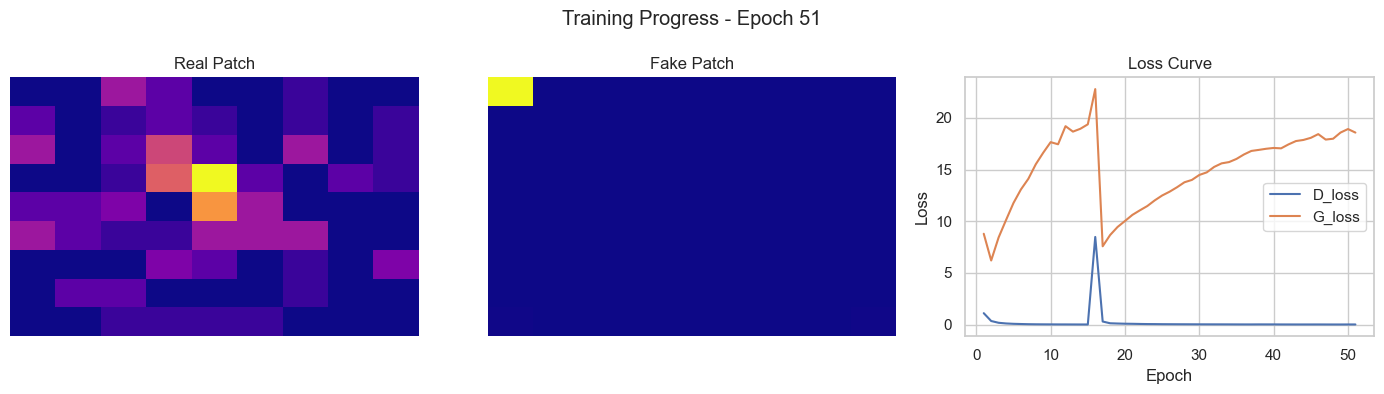

Epoch 52/100
Epoch 52/100 D_loss=0.0113 G_loss=18.5962 


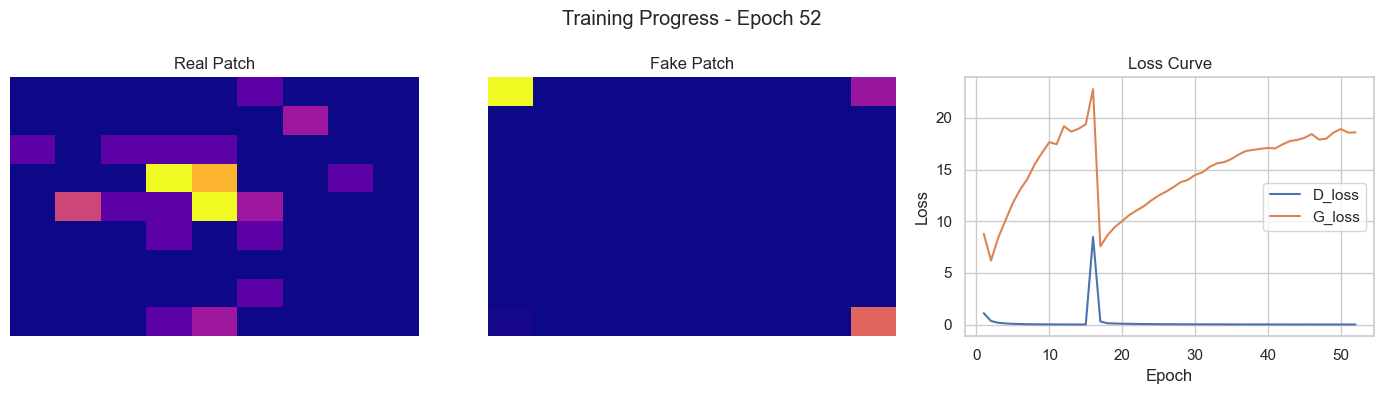

Epoch 53/100
Epoch 53/100 D_loss=0.0131 G_loss=18.1517 


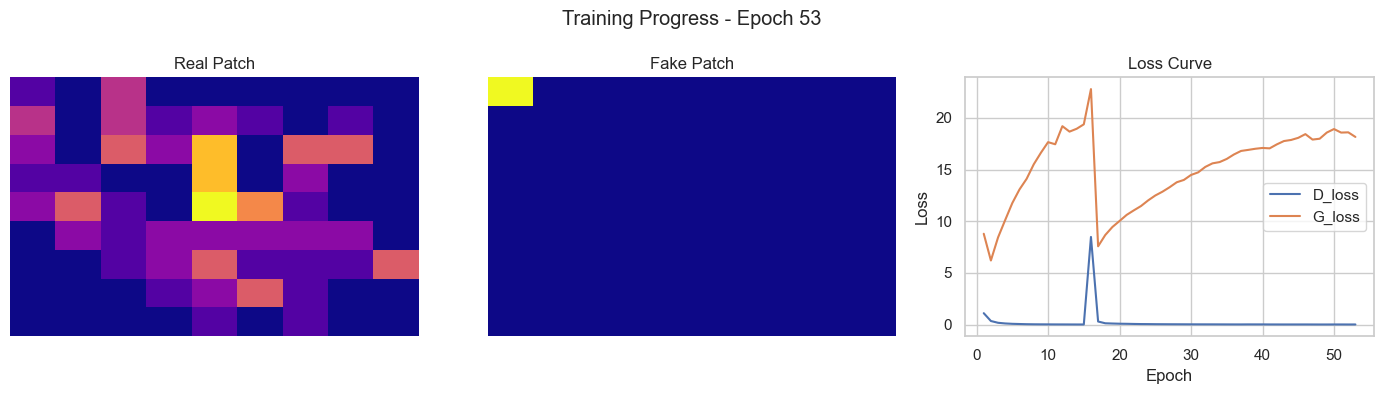

Epoch 54/100
Epoch 54/100 D_loss=0.0124 G_loss=17.8851 


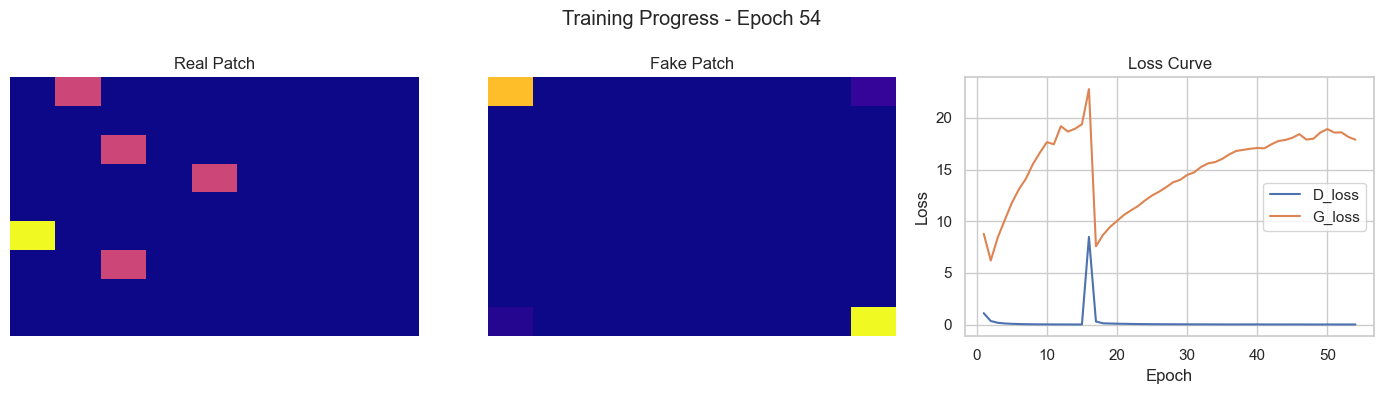

Epoch 55/100
Epoch 55/100 D_loss=0.0096 G_loss=17.9917 


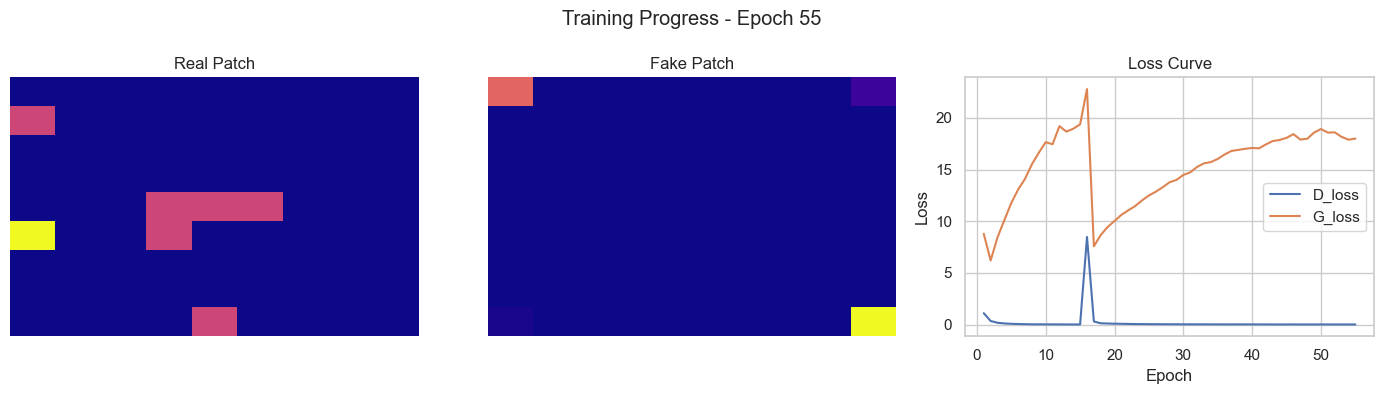

Epoch 56/100
Epoch 56/100 D_loss=0.0084 G_loss=18.3672 


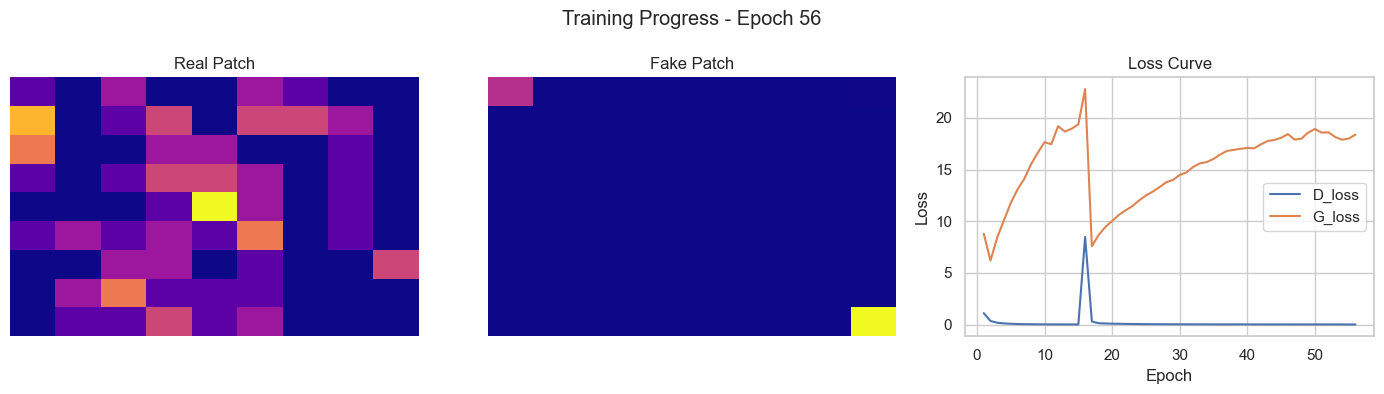

Epoch 57/100
Epoch 57/100 D_loss=0.0116 G_loss=19.1214 


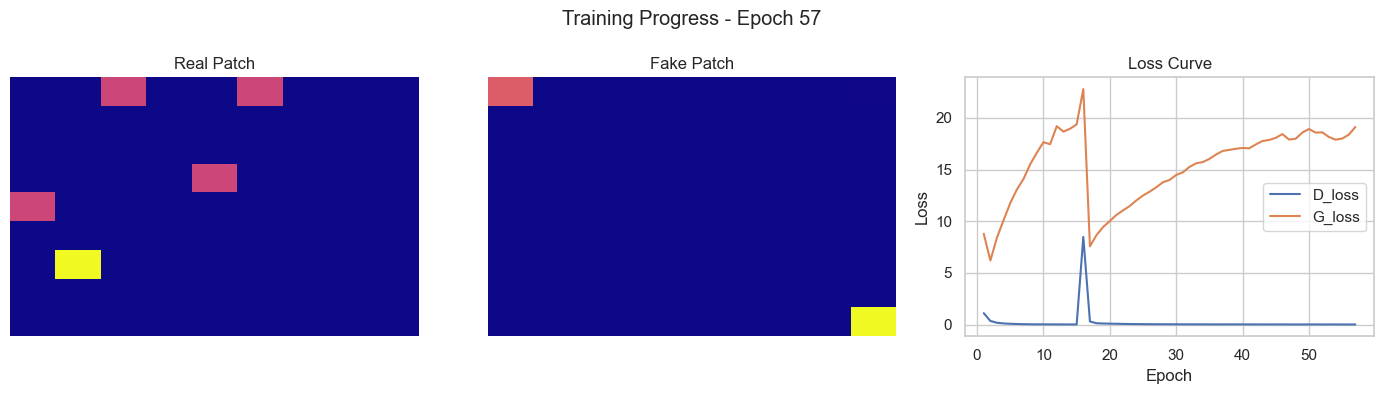

Epoch 58/100
Epoch 58/100 D_loss=0.0111 G_loss=18.4282 


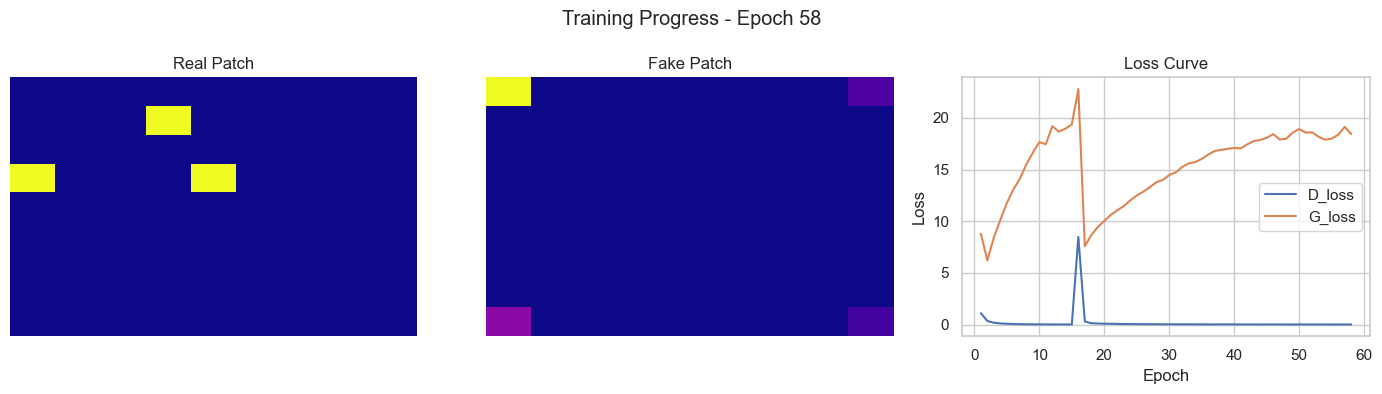

Epoch 59/100
Epoch 59/100 D_loss=0.0126 G_loss=18.4040 


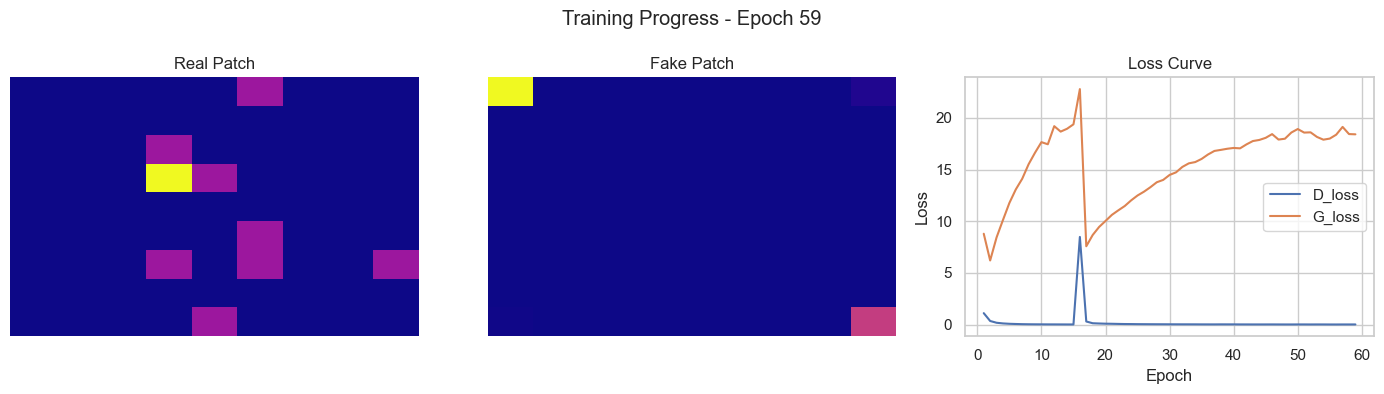

Epoch 60/100
Epoch 60/100 D_loss=0.0128 G_loss=17.6123 


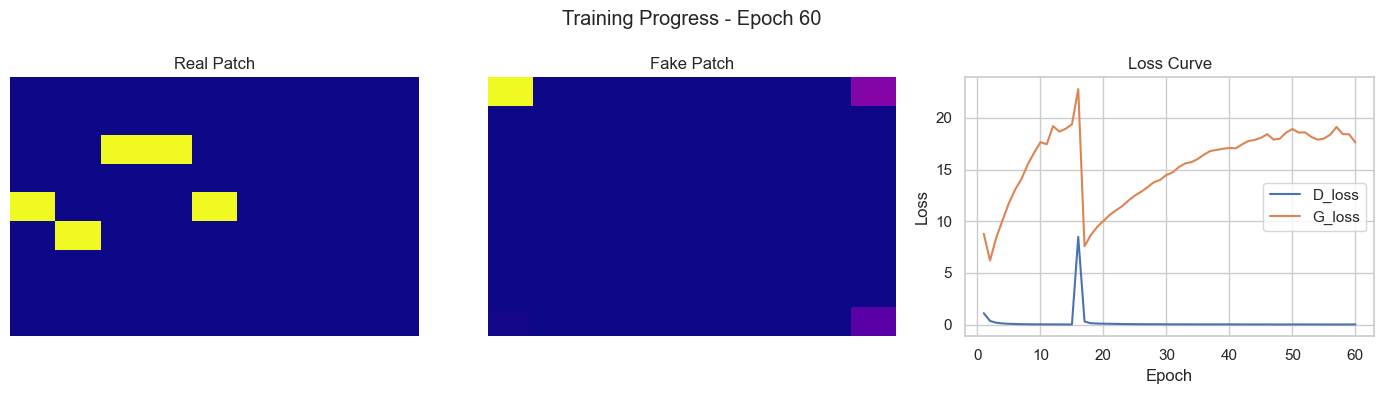

Epoch 61/100
Epoch 61/100 D_loss=0.0118 G_loss=17.7653 


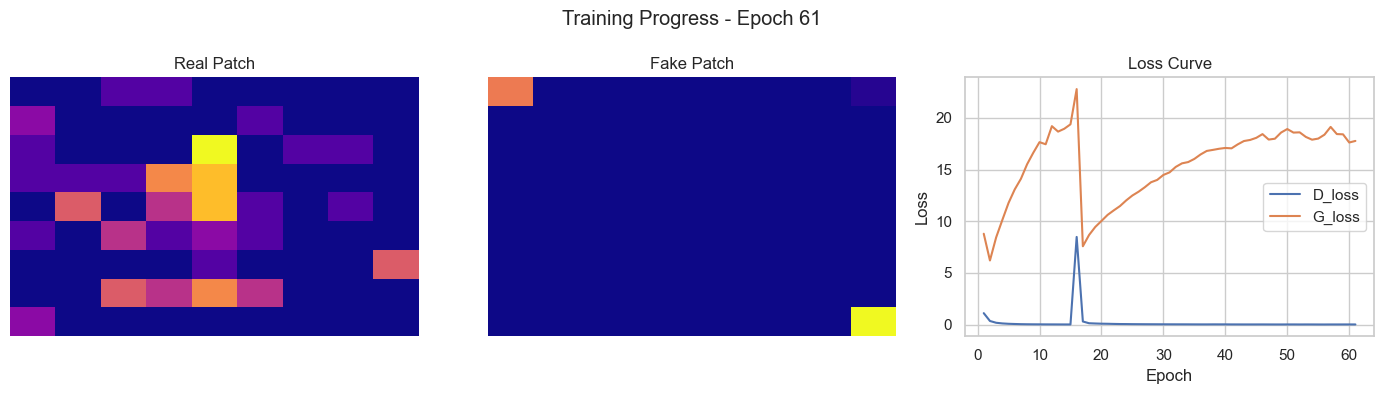

Epoch 62/100
Epoch 62/100 D_loss=0.0094 G_loss=17.7759 


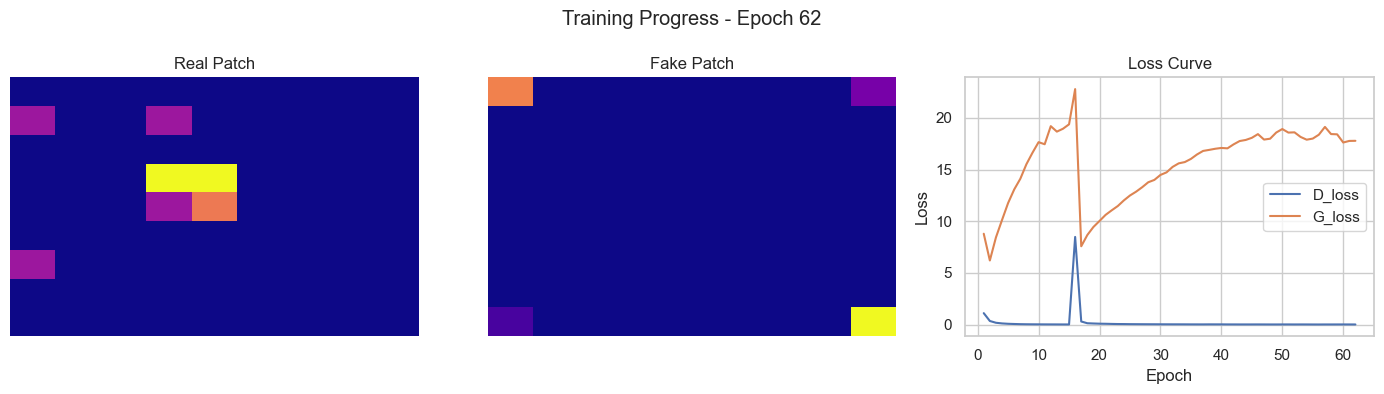

Epoch 63/100
Epoch 63/100 D_loss=0.0099 G_loss=17.8286 


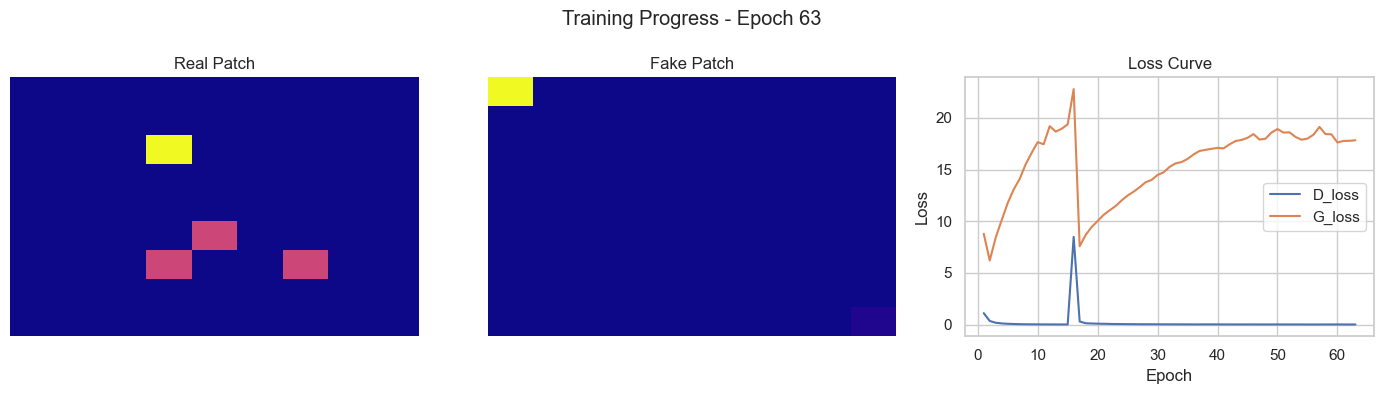

Epoch 64/100
Epoch 64/100 D_loss=0.0113 G_loss=17.7755 


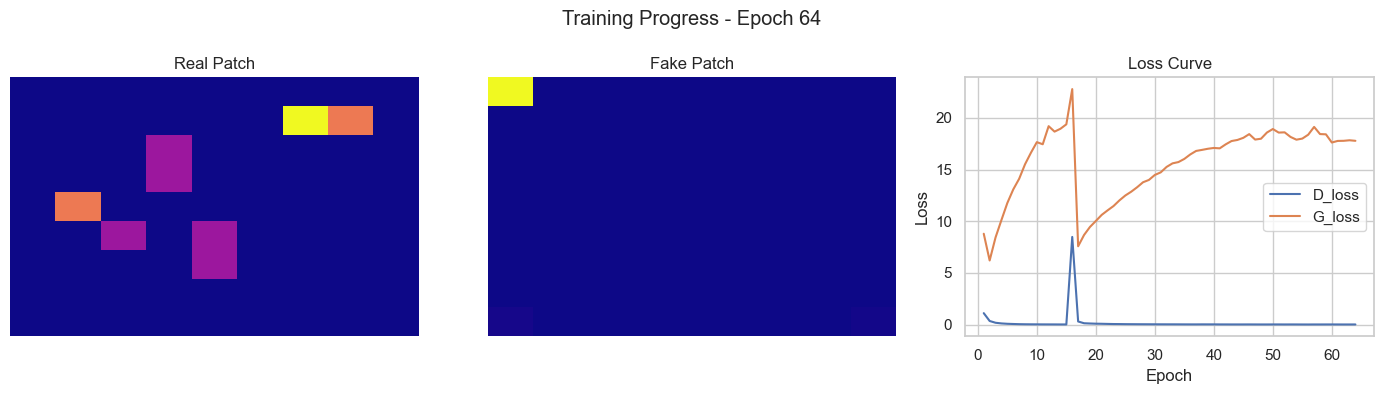

Epoch 65/100
Epoch 65/100 D_loss=0.0115 G_loss=17.7586 


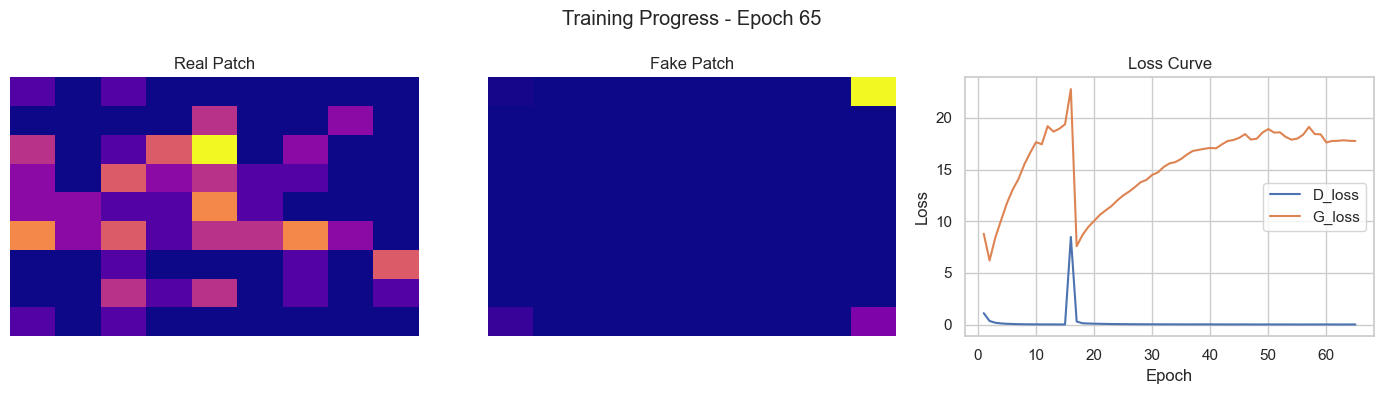

Epoch 66/100
Epoch 66/100 D_loss=0.0087 G_loss=17.3324 


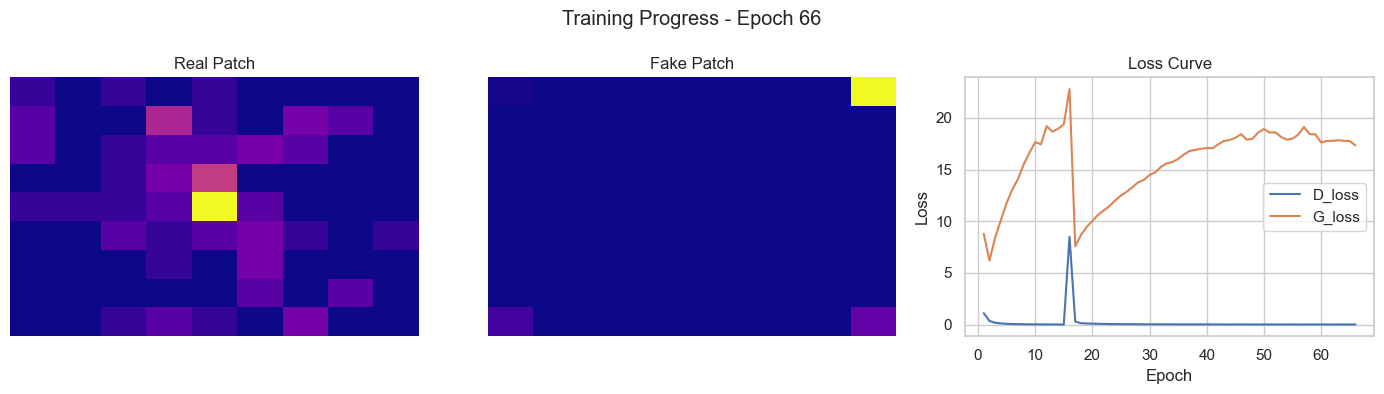

Epoch 67/100
Epoch 67/100 D_loss=1.6024 G_loss=17.1069 


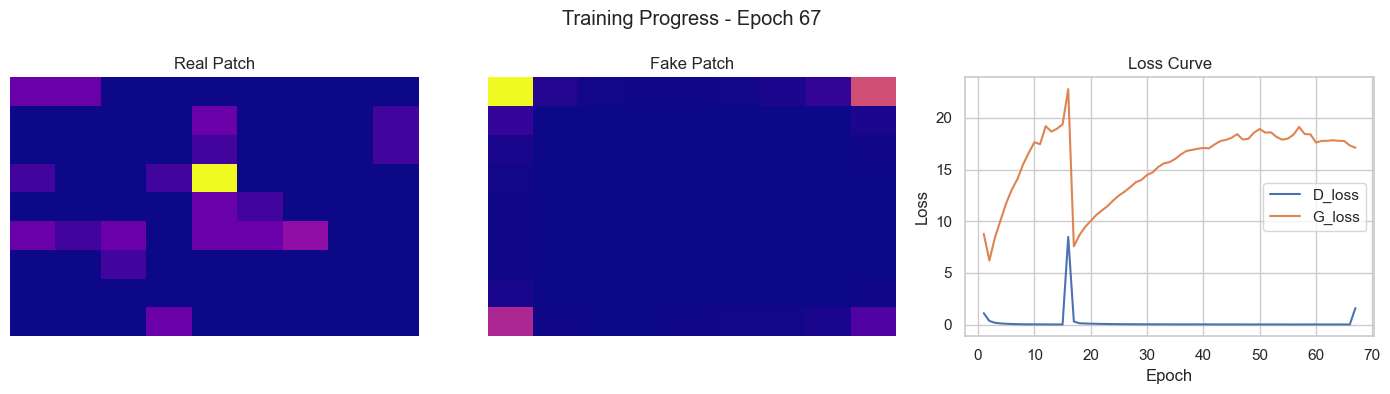

Epoch 68/100
Epoch 68/100 D_loss=0.3584 G_loss=8.8701 


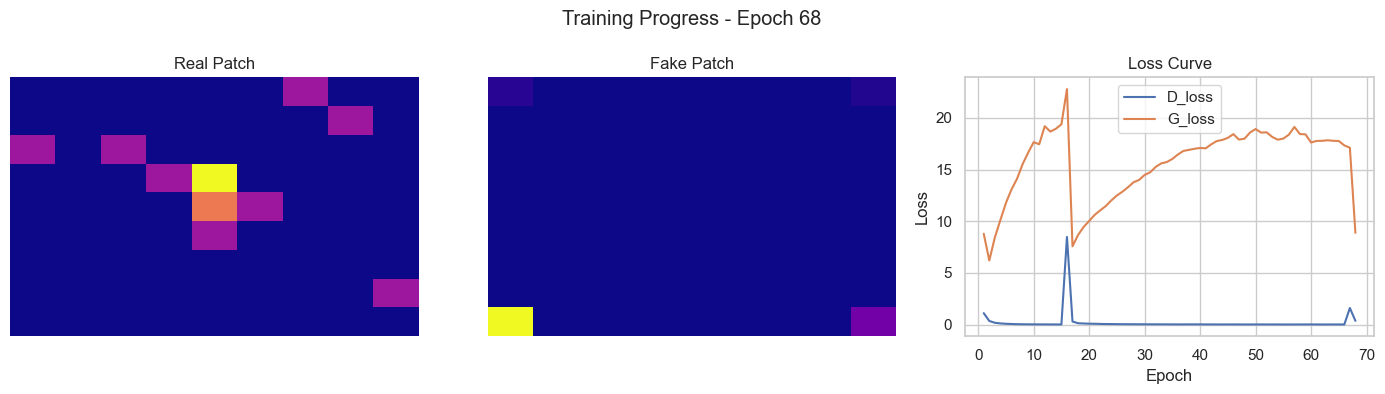

Epoch 69/100
Epoch 69/100 D_loss=0.8660 G_loss=8.1563 


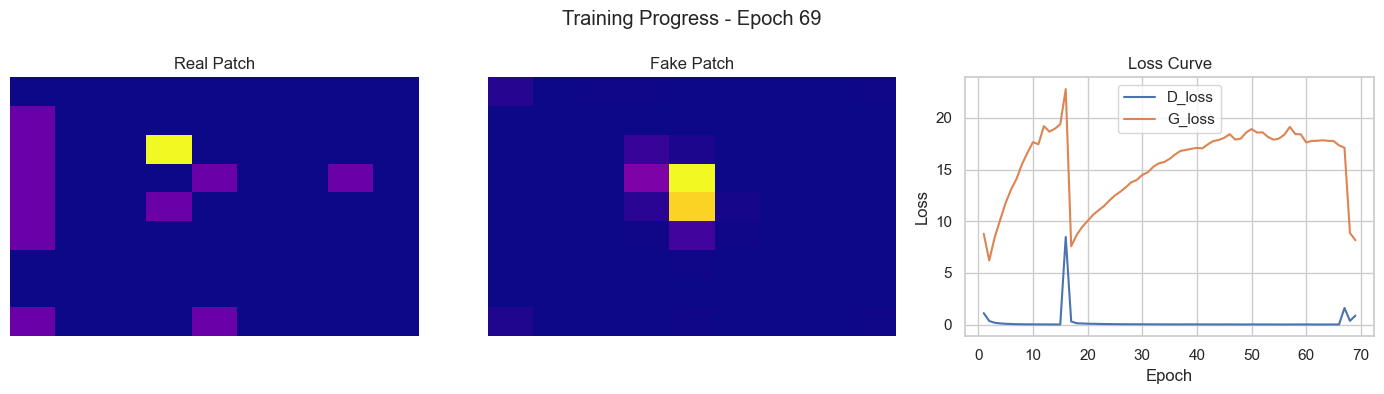

Epoch 70/100
Epoch 70/100 D_loss=1.2571 G_loss=3.6677 


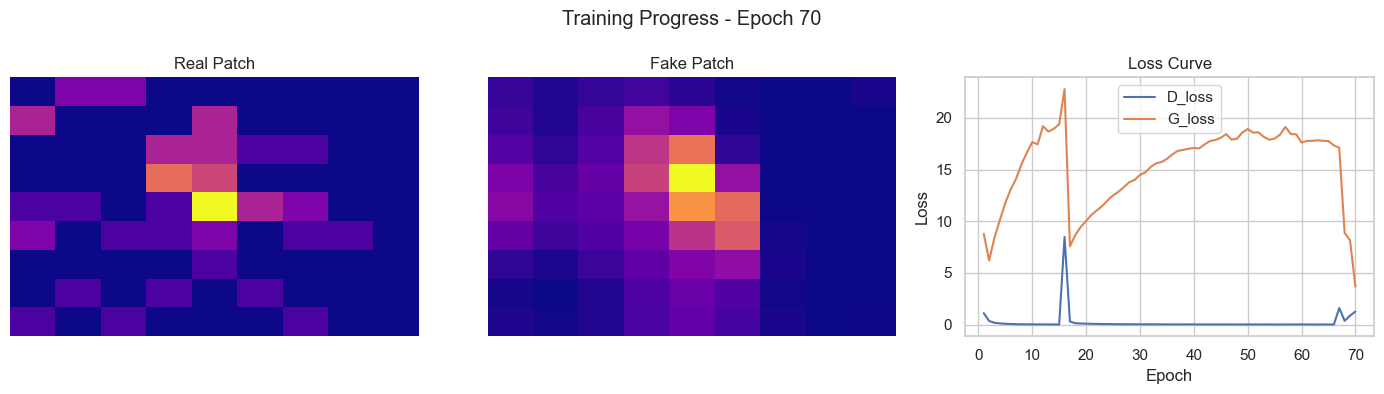

Epoch 71/100
Epoch 71/100 D_loss=1.2730 G_loss=3.6467 


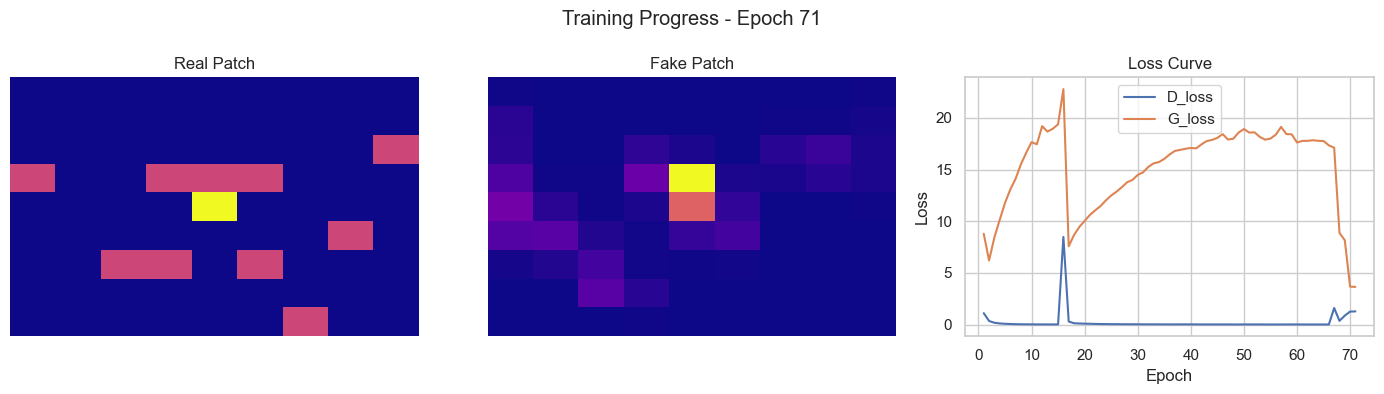

Epoch 72/100
Epoch 72/100 D_loss=1.2765 G_loss=3.4649 


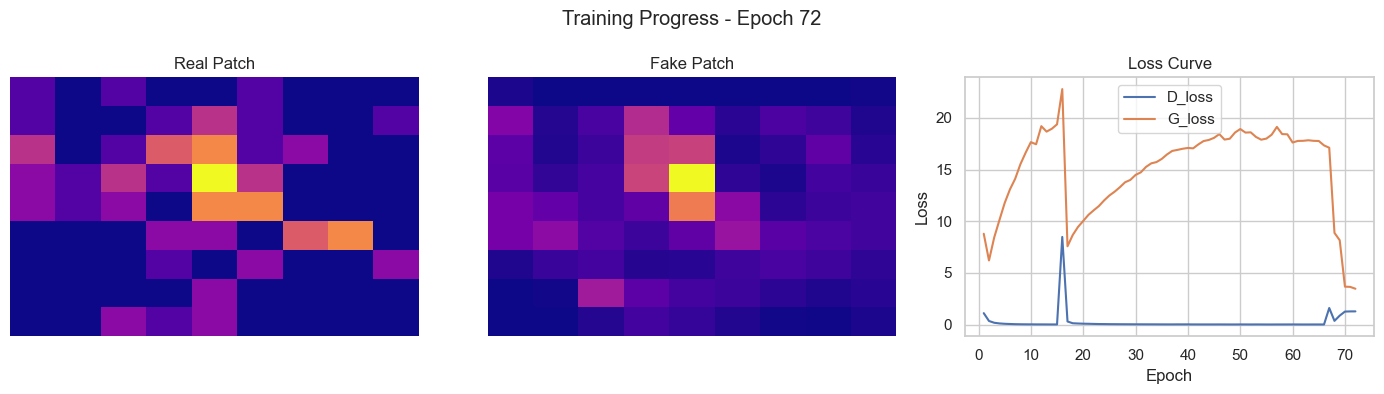

Epoch 73/100
Epoch 73/100 D_loss=1.2212 G_loss=3.5113 


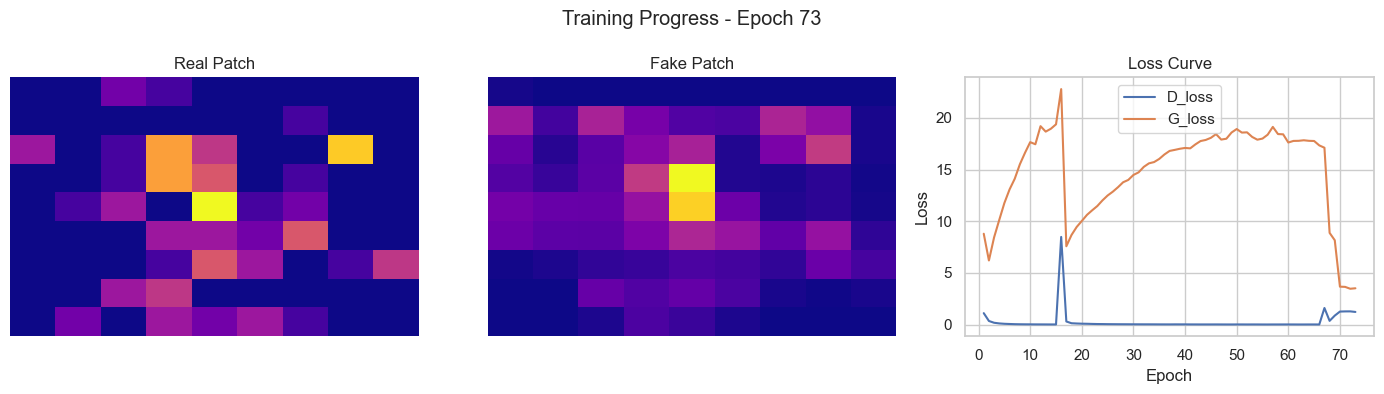

Epoch 74/100
Epoch 74/100 D_loss=1.0162 G_loss=3.7047 


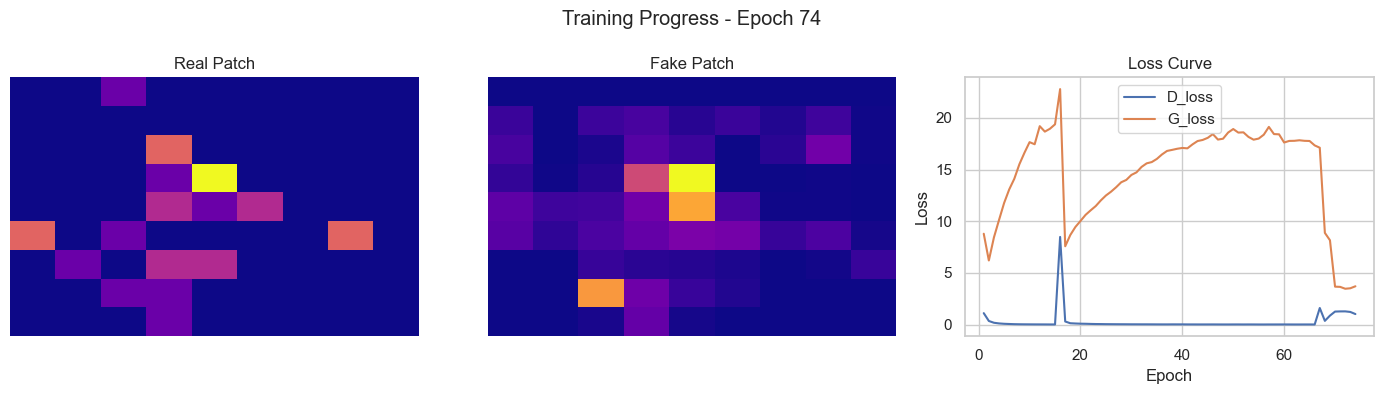

Epoch 75/100
Epoch 75/100 D_loss=0.8366 G_loss=3.9574 


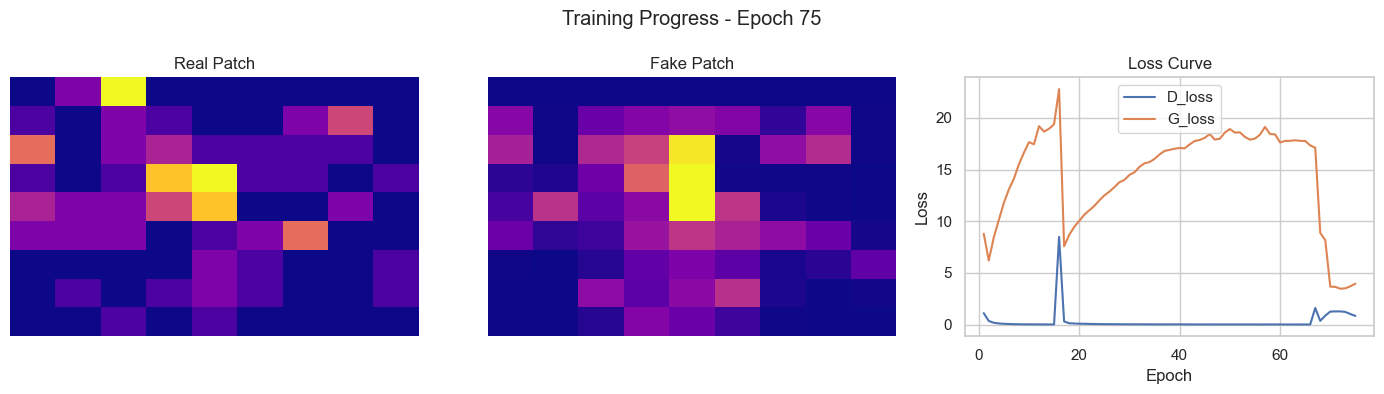

Epoch 76/100
Epoch 76/100 D_loss=1.0187 G_loss=3.8835 


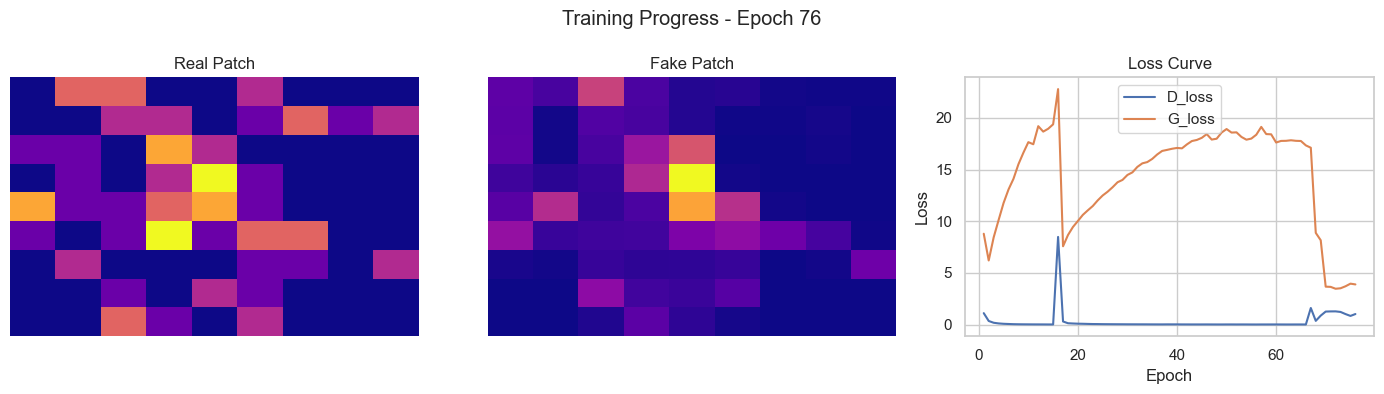

Epoch 77/100
Epoch 77/100 D_loss=1.3728 G_loss=3.2001 


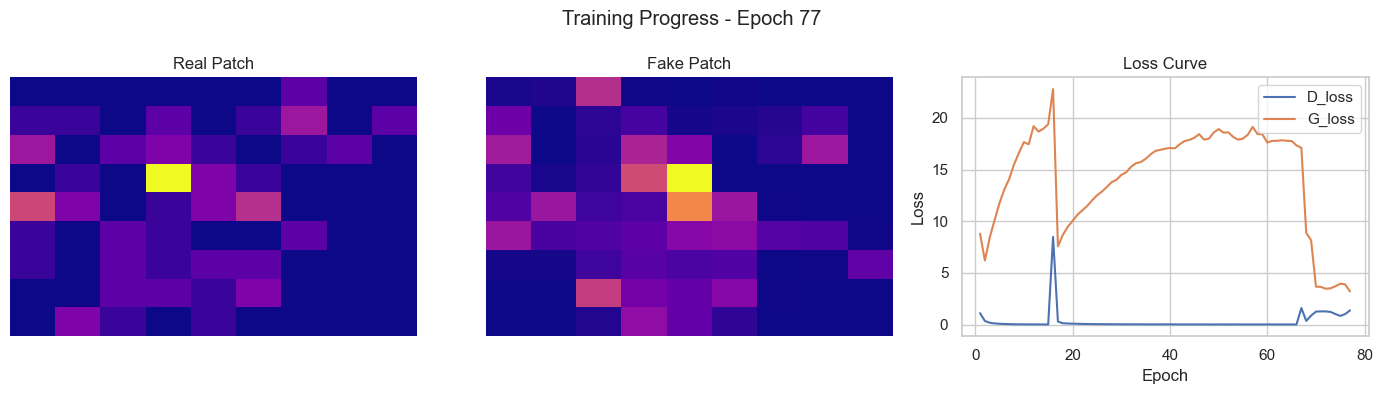

Epoch 78/100
Epoch 78/100 D_loss=1.3563 G_loss=3.1781 


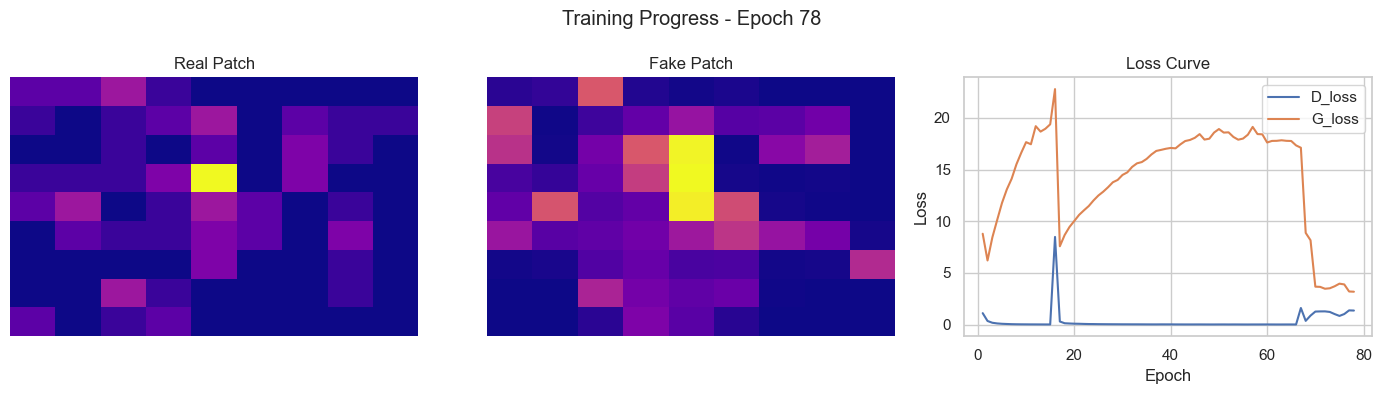

Epoch 79/100
Epoch 79/100 D_loss=1.3328 G_loss=3.1844 


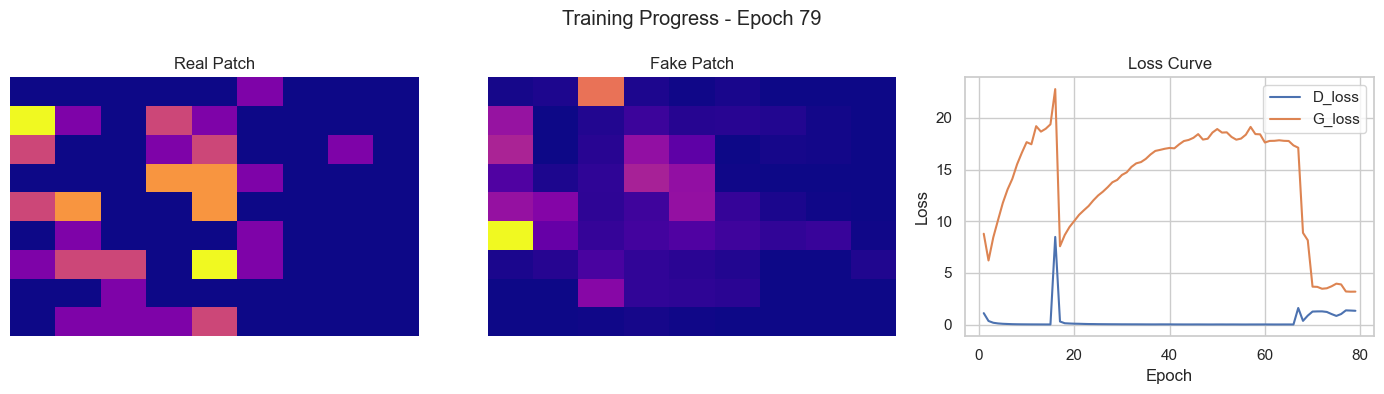

Epoch 80/100
Epoch 80/100 D_loss=1.3157 G_loss=3.1950 


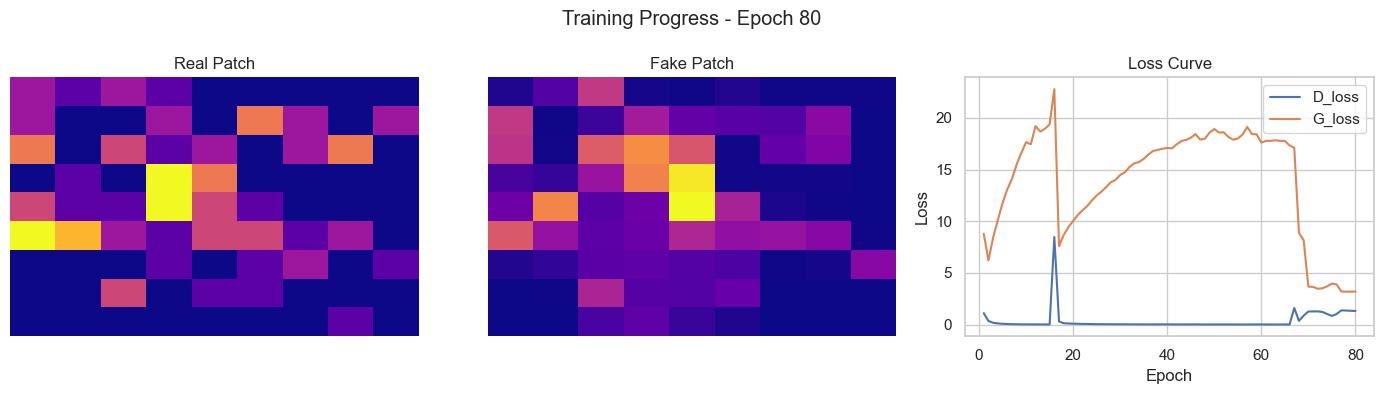

Epoch 81/100
Epoch 81/100 D_loss=1.3081 G_loss=3.2244 


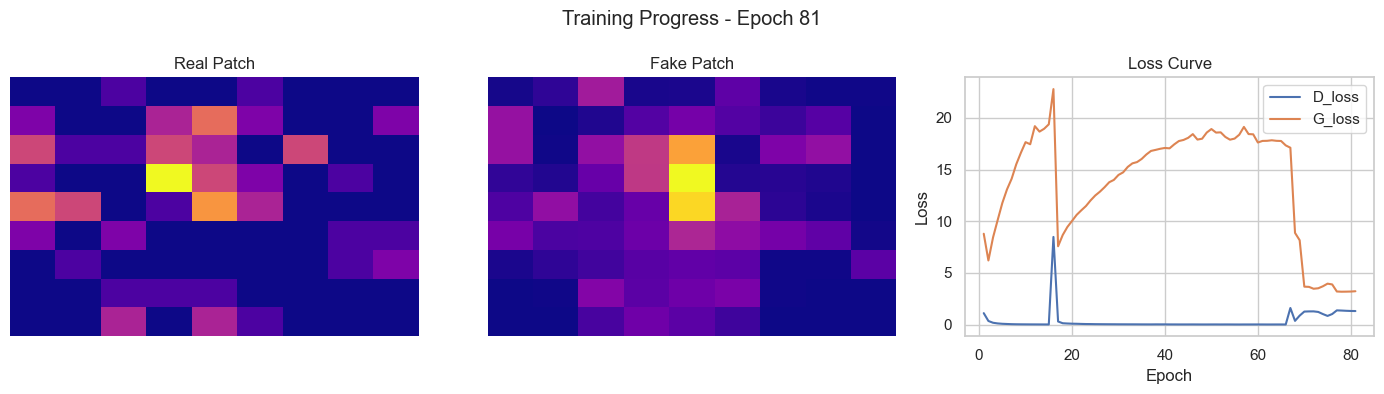

Epoch 82/100
Epoch 82/100 D_loss=1.3112 G_loss=3.2470 


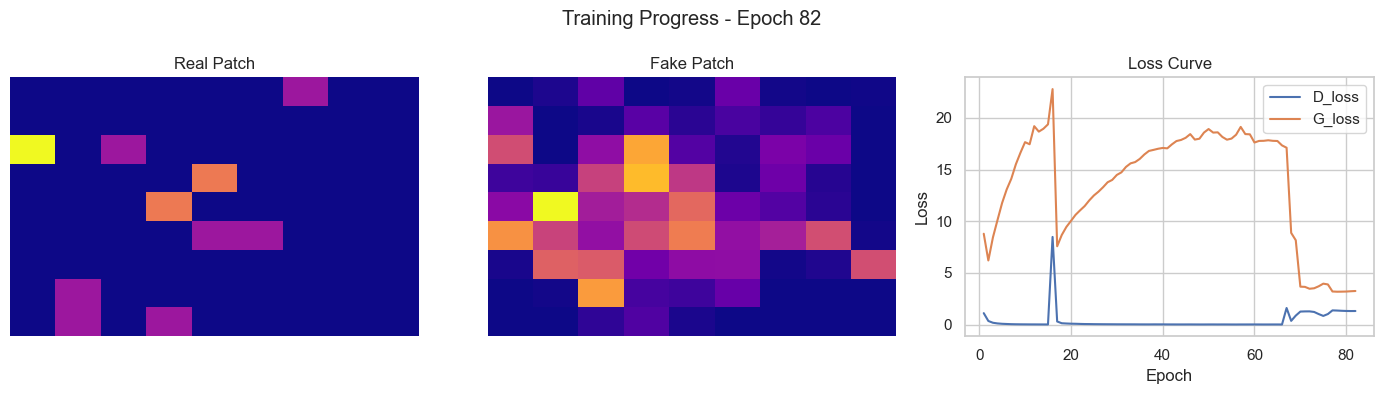

Epoch 83/100
Epoch 83/100 D_loss=1.2988 G_loss=3.2699 


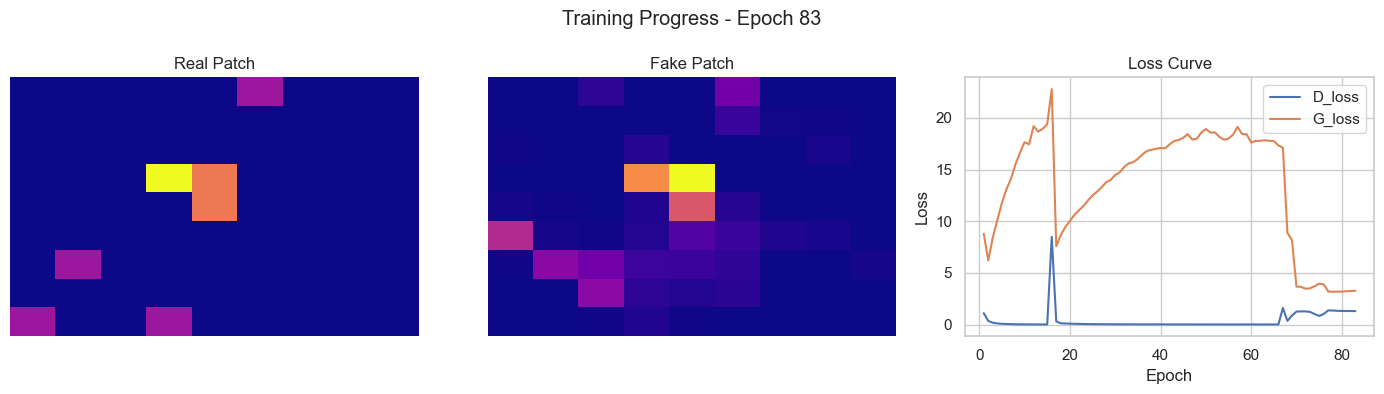

Epoch 84/100
Epoch 84/100 D_loss=1.2846 G_loss=3.2990 


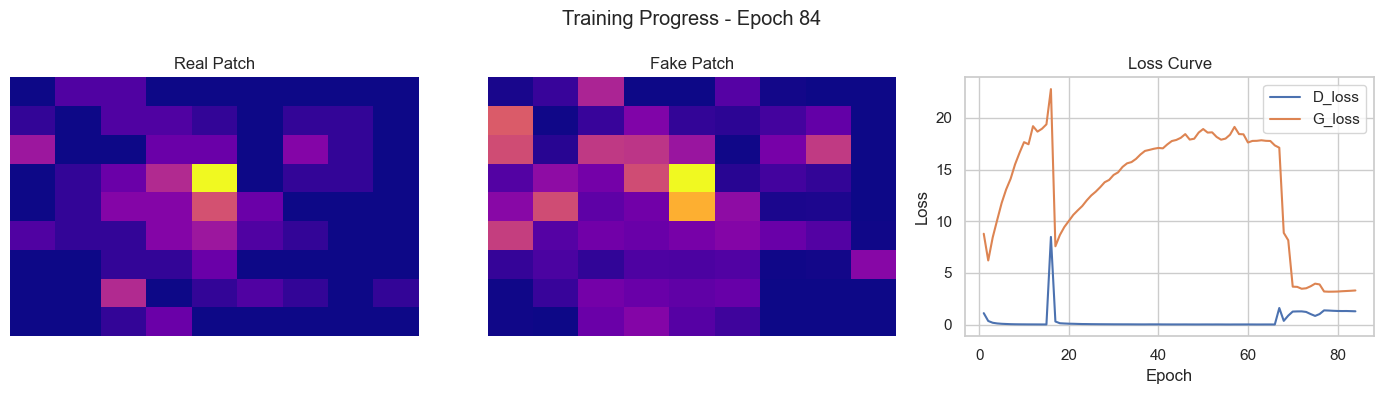

Epoch 85/100
Epoch 85/100 D_loss=1.2552 G_loss=3.3471 


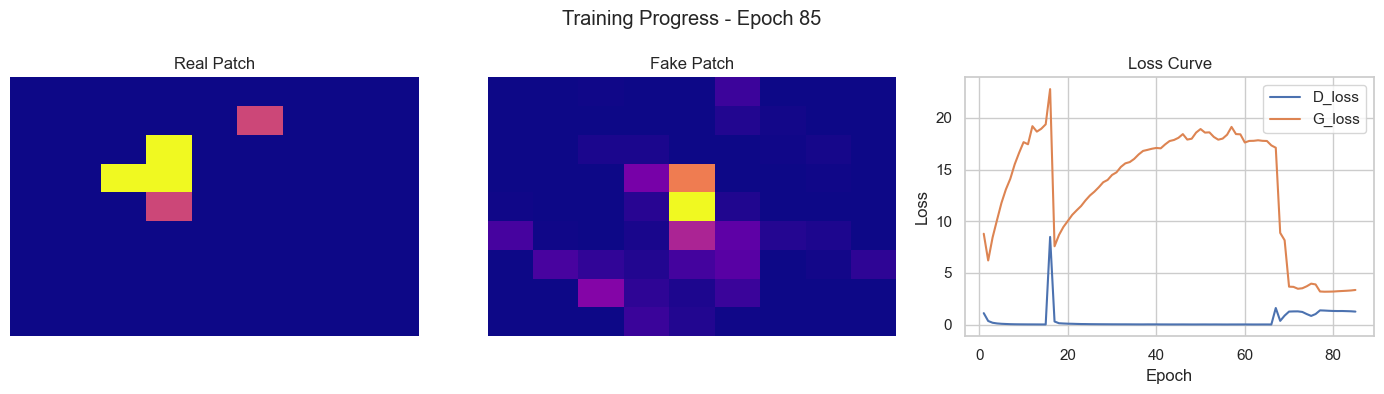

Epoch 86/100
Epoch 86/100 D_loss=1.2420 G_loss=3.4716 


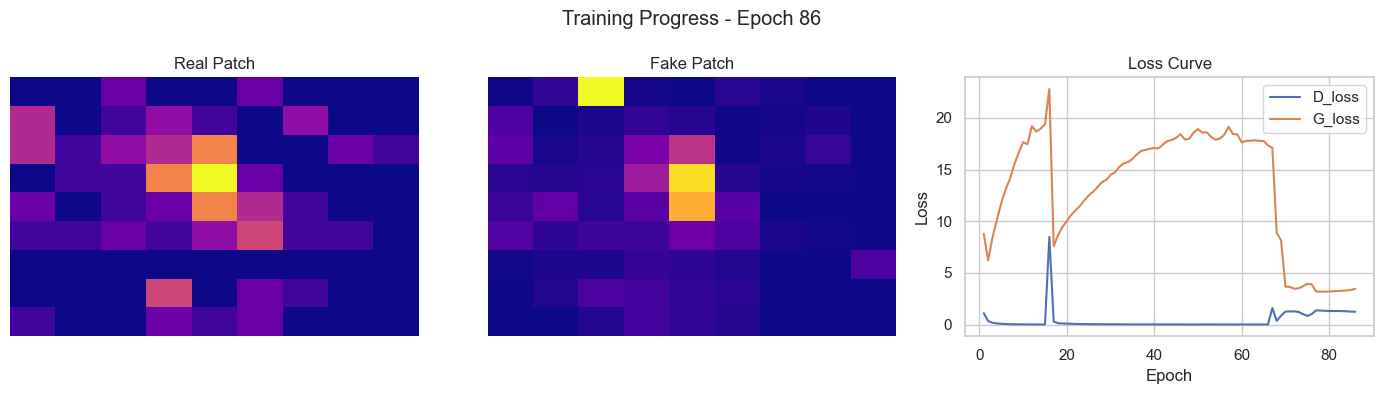

Epoch 87/100
Epoch 87/100 D_loss=1.2363 G_loss=3.6526 


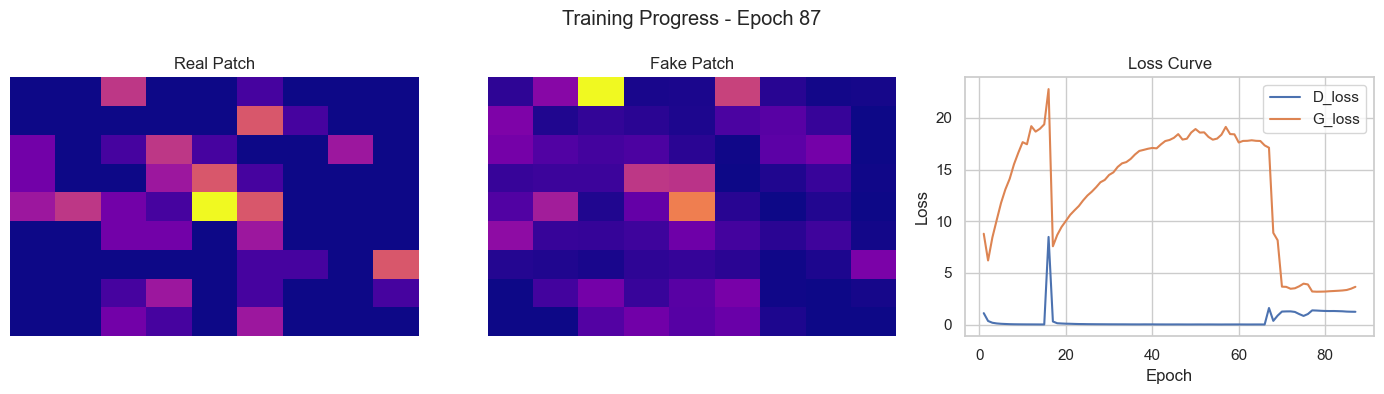

Epoch 88/100
Epoch 88/100 D_loss=1.1950 G_loss=3.6549 


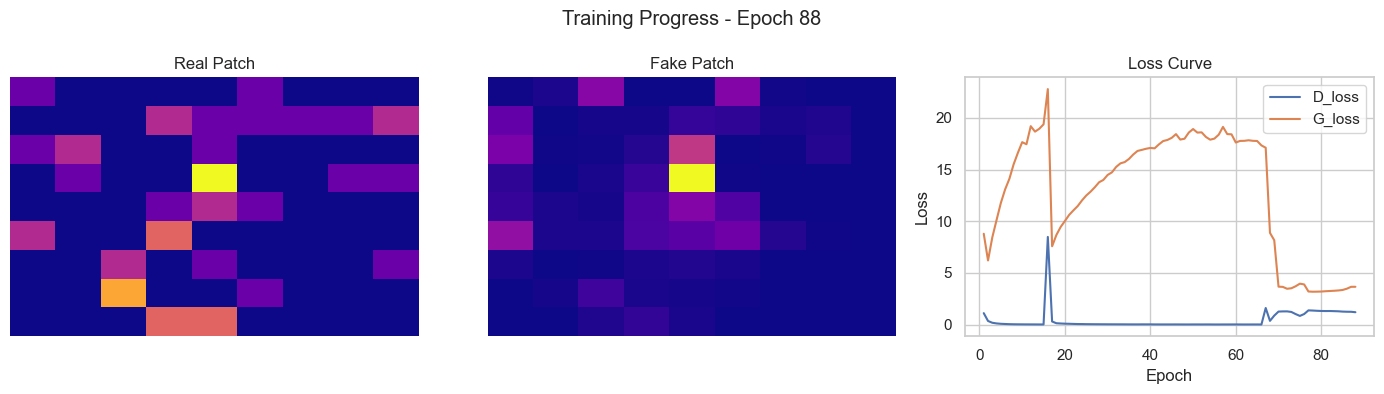

Epoch 89/100
Epoch 89/100 D_loss=1.2495 G_loss=3.7586 


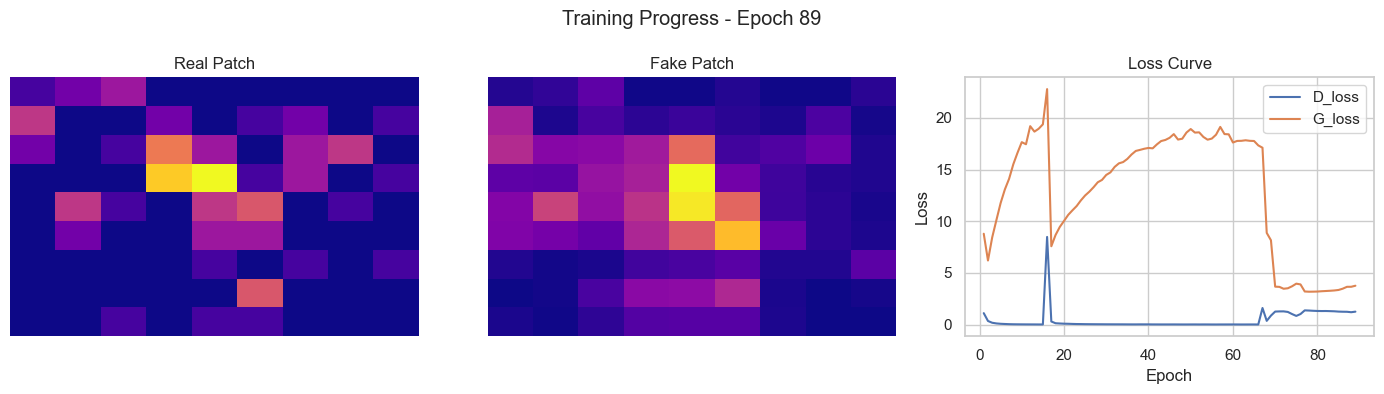

Epoch 90/100
Epoch 90/100 D_loss=1.2257 G_loss=3.7874 


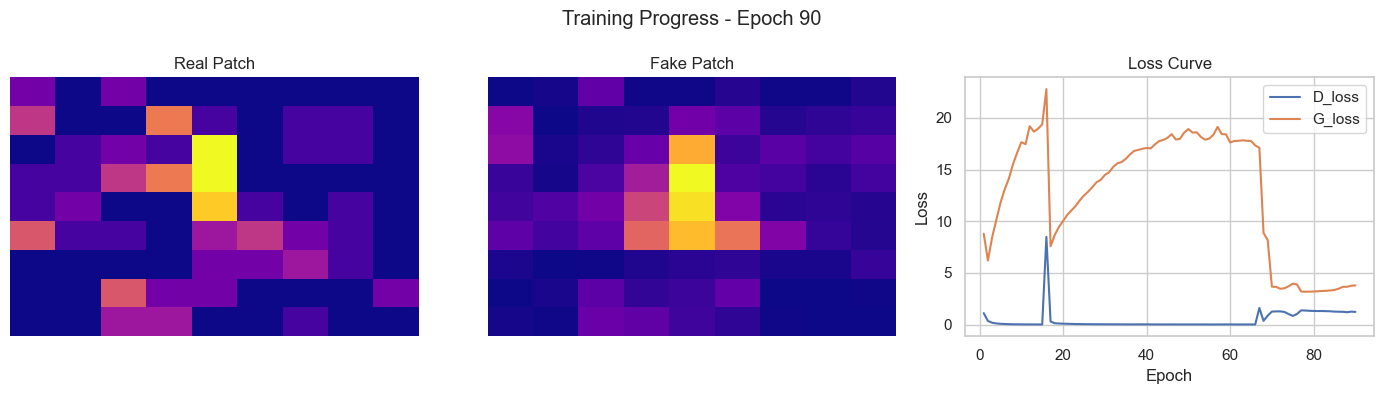

Epoch 91/100
Epoch 91/100 D_loss=1.2450 G_loss=3.7978 


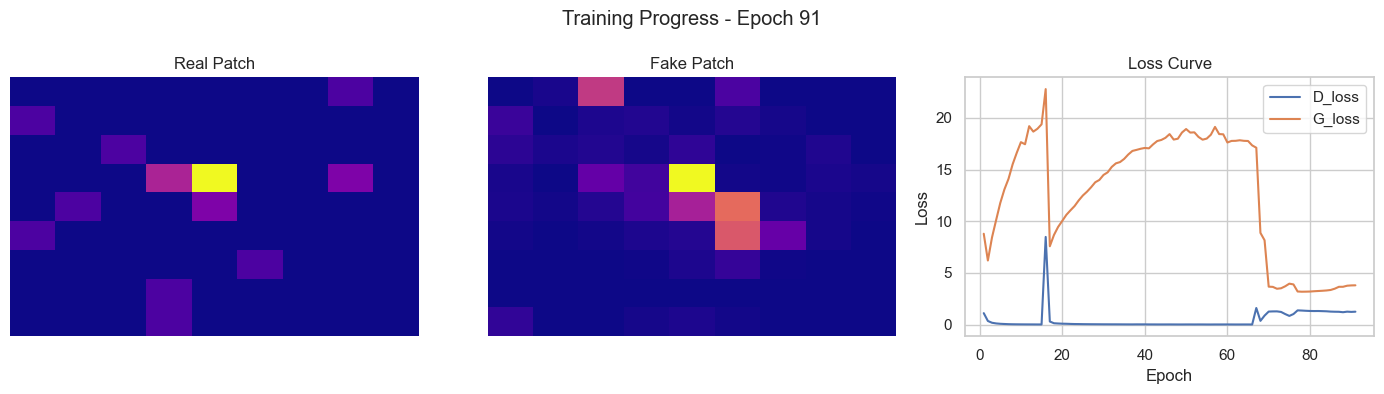

Epoch 92/100
Epoch 92/100 D_loss=1.2754 G_loss=3.7807 


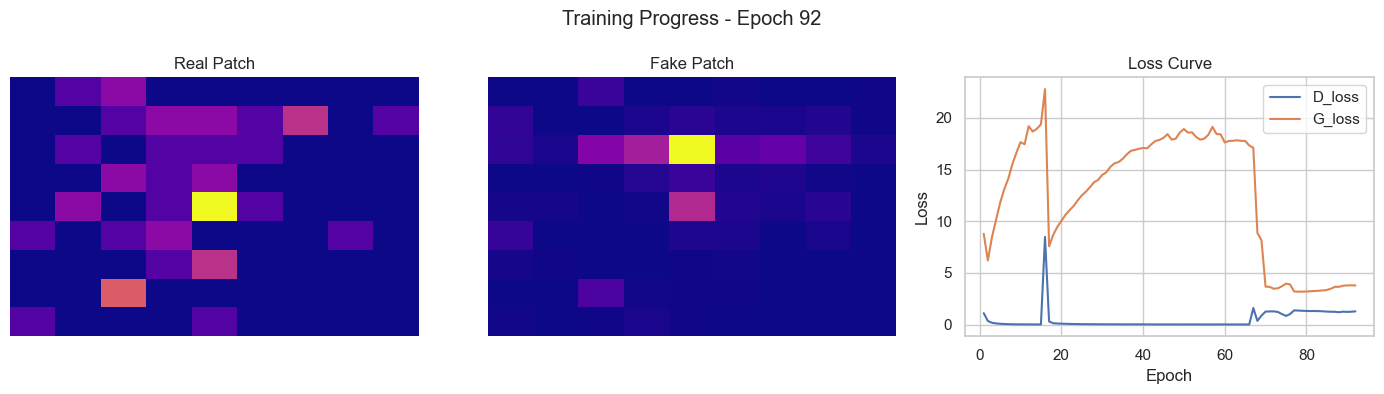

Epoch 93/100
Epoch 93/100 D_loss=1.2333 G_loss=3.7528 


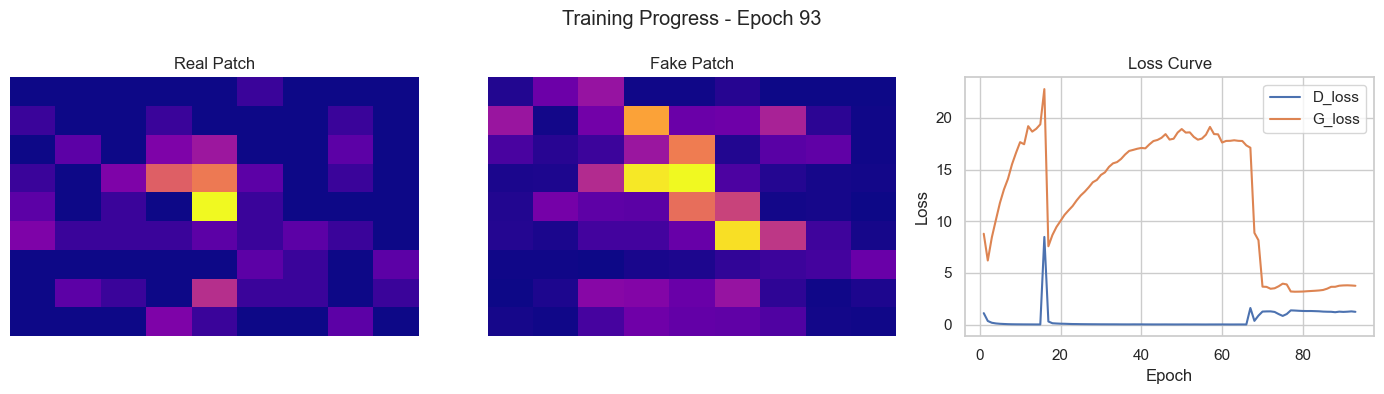

Epoch 94/100
Epoch 94/100 D_loss=1.1677 G_loss=3.8915 


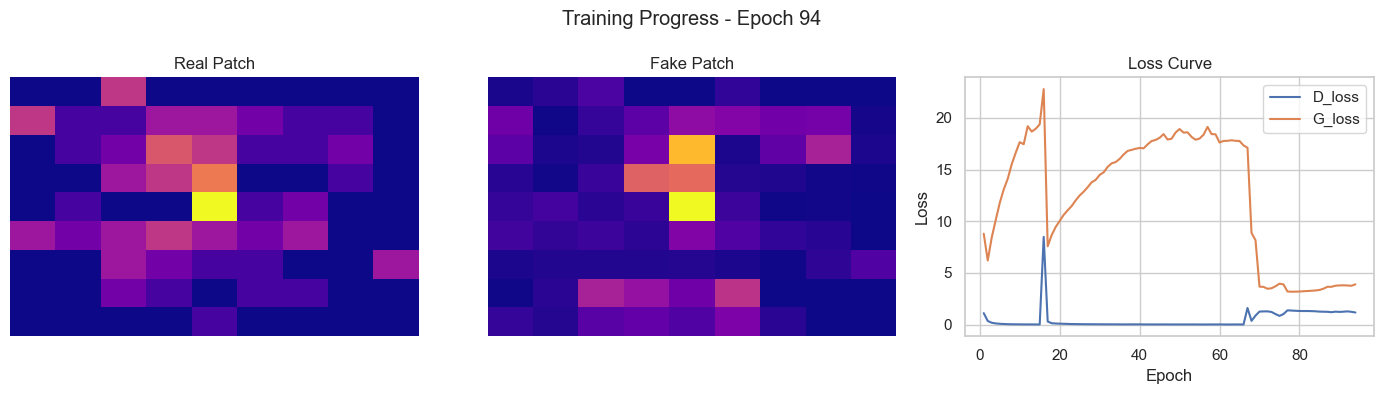

Epoch 95/100
Epoch 95/100 D_loss=1.1898 G_loss=4.0448 


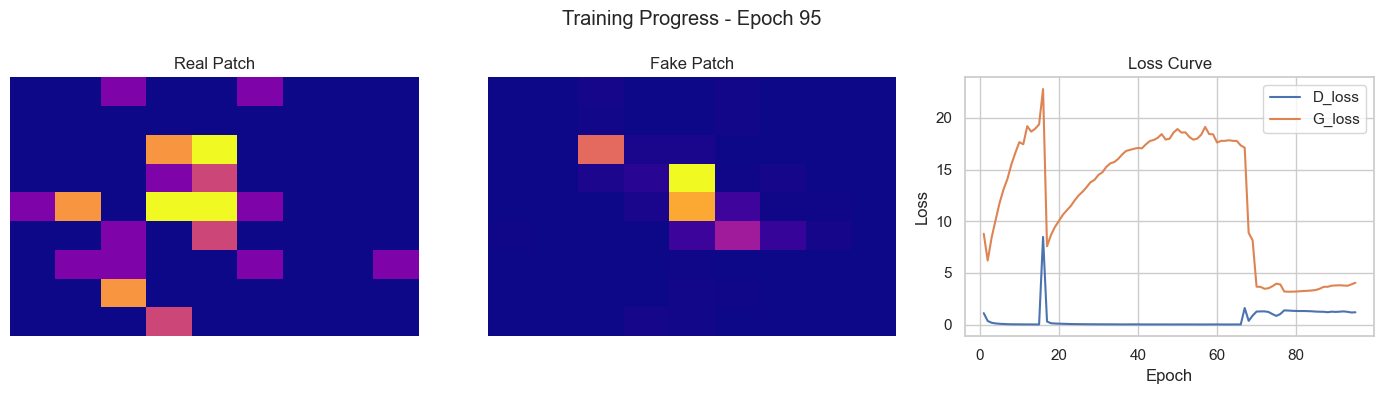

Epoch 96/100
Epoch 96/100 D_loss=1.2458 G_loss=4.0013 


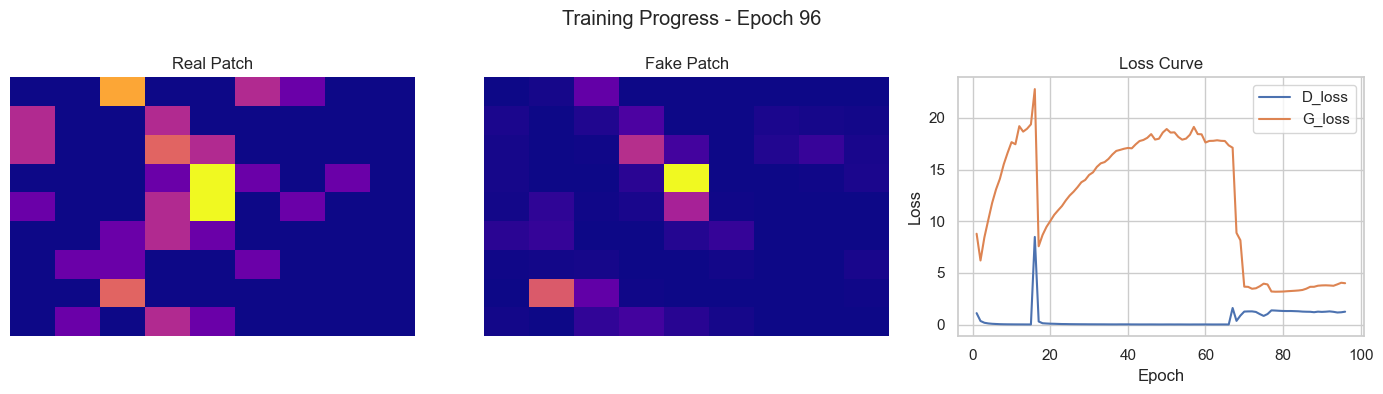

Epoch 97/100
Epoch 97/100 D_loss=1.2446 G_loss=3.8401 


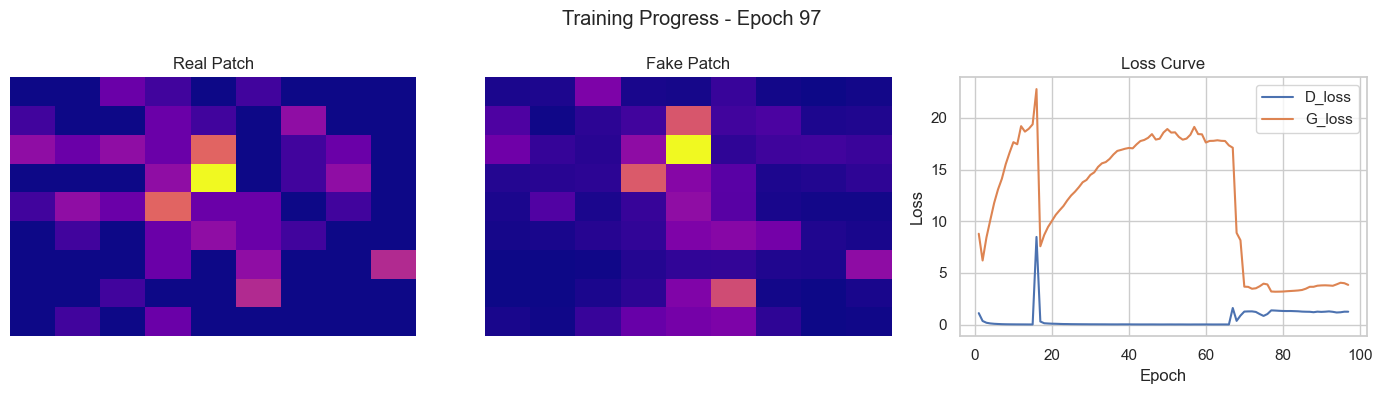

Epoch 98/100
Epoch 98/100 D_loss=1.1151 G_loss=3.9033 


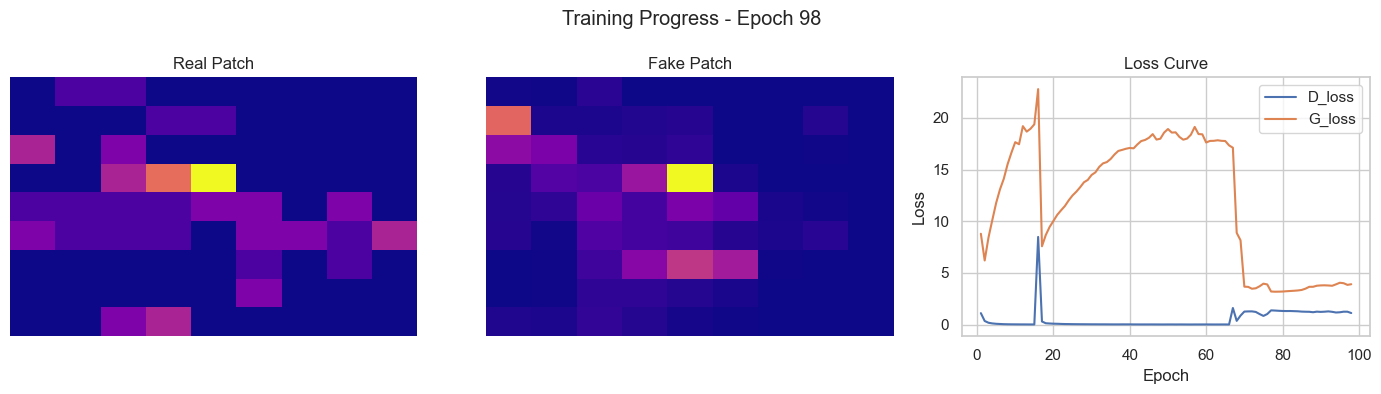

Epoch 99/100
Epoch 99/100 D_loss=1.2585 G_loss=4.0995 


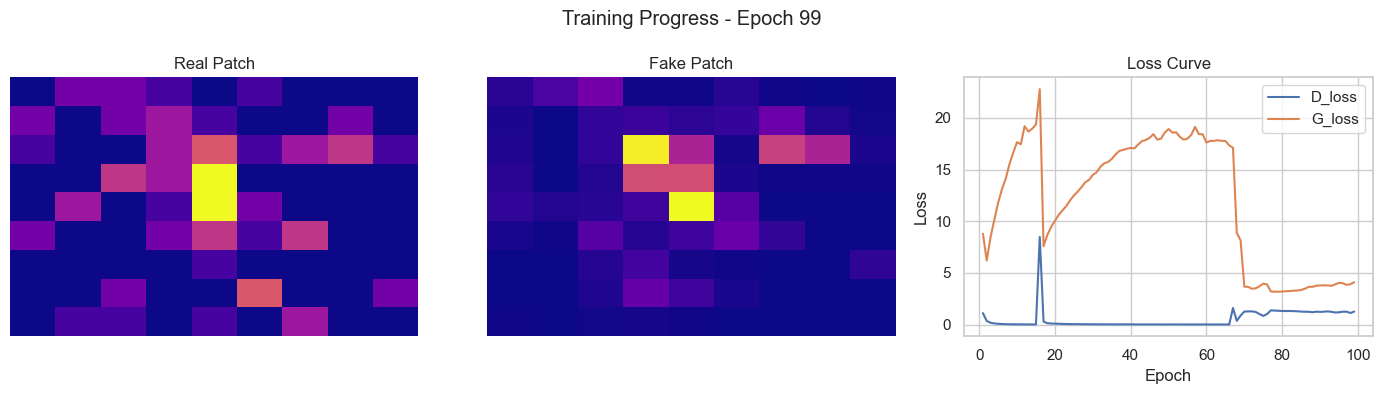

Epoch 100/100
Epoch 100/100 D_loss=1.1925 G_loss=4.1245 


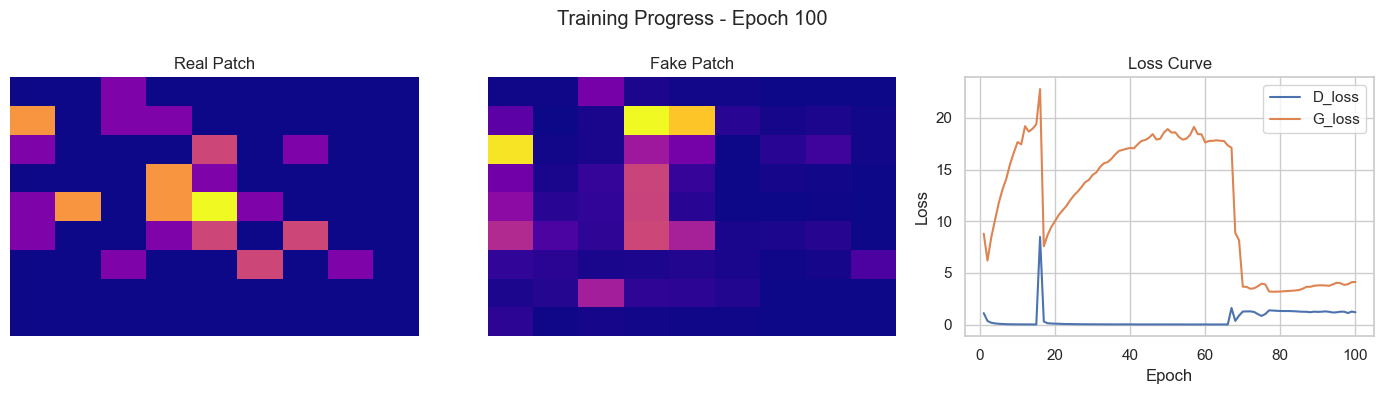

In [71]:
from sklearn.metrics import root_mean_squared_error, mean_absolute_error
# 切分 df
df_train = df[df["d"] < 60]
df_test  = df[df["d"] >= 60]

# 建立 dataset
X_train, C_train, Y_train = make_dataset(df_train)
X_test, C_test,  Y_test  = make_dataset(df_test)

print("Train:", X_train.shape, C_train.shape, Y_train.shape)
print("Test :", X_test.shape,  C_test.shape,  Y_test.shape)
'''
visualize_sample(X_train, C_train, Y_train, idx=0)
'''
# 訓練 cGAN
G = build_generator()
D = build_discriminator()
history = train_cgan(G, D, X_train, C_train, Y_train, epochs=100, batch_size=32, latent_dim = 100)

Patch-level RMSE (original scale): 0.7533
Patch-level MAE  (original scale): 0.3300


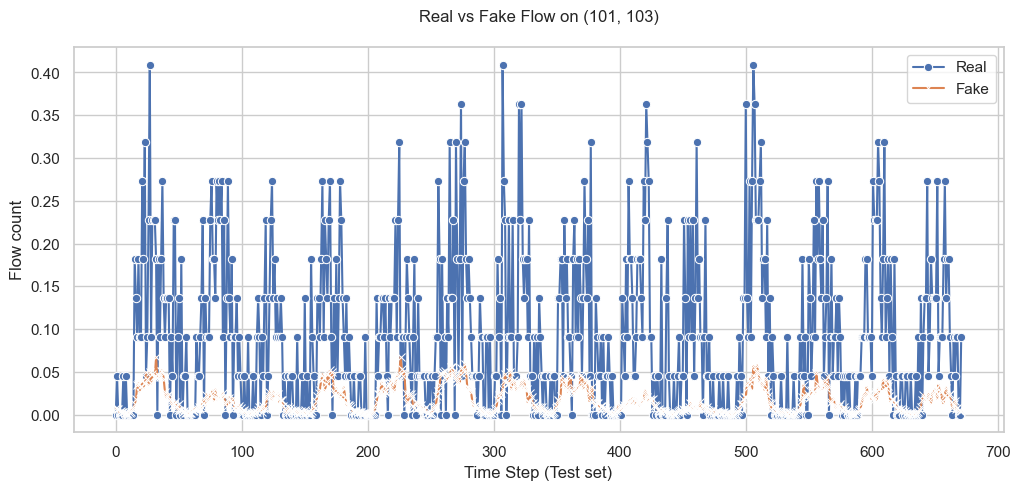

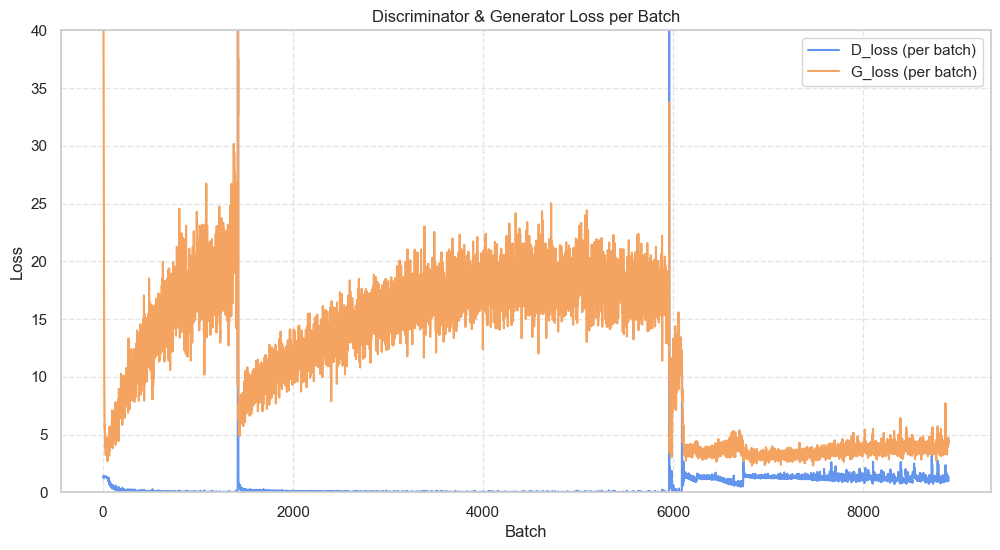

In [76]:
import tensorflow as tf
from tensorflow import keras

# 測試集預測
latent_dim = 100 
z_test = np.random.normal(size=(X_test.shape[0], latent_dim))

Y_test_pred = G([tf.constant(z_test, dtype=tf.float32), 
                 tf.constant(X_test, dtype=tf.float32), 
                 tf.constant(C_test, dtype=tf.float32)], 
                training=False).numpy()
# 取中心點 (4,4)，對應原始中心點
real_series = Y_test[:, 4, 4, 0]
fake_series = Y_test_pred[:, 4, 4, 0]

# =======================
# 評估指標
# =======================
Y_test_inv     = scaler.inverse_transform(Y_test.reshape(-1, 81)).reshape(-1, 9, 9, 1)
Y_test_pred_inv= scaler.inverse_transform(Y_test_pred.reshape(-1, 81)).reshape(-1, 9, 9, 1)

# RMSE (整個 patch)
rmse_patch = np.sqrt(np.mean((Y_test_inv - Y_test_pred_inv) ** 2))

# MAE (整個 patch)
mae_patch = np.mean(np.abs(Y_test_inv - Y_test_pred_inv))

print(f"Patch-level RMSE (original scale): {rmse_patch:.4f}")
print(f"Patch-level MAE  (original scale): {mae_patch:.4f}")


# =======================
# Real vs Fake 折線圖
# =======================
sns.set_theme(style="whitegrid")

plt.figure(figsize=(12,5))
sns.lineplot(x=range(len(real_series)), y=real_series, label="Real", marker="o")
sns.lineplot(x=range(len(fake_series)), y=fake_series, label="Fake", marker="x")

plt.xlabel("Time Step (Test set)")
plt.ylabel("Flow count")
plt.title("Real vs Fake Flow on (101, 103)\n")
plt.legend()
plt.show()

# Loss Curve
plot_batch_loss(history,(0,40))

# G.summary()
# D.summary()


**Diffusion Model**

In [114]:
# =======================
# input:中心點人流數量、當下時間
# output:周圍9*9網格的人流數量
# =======================
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# =======================
# 1. 載入 & 整理資料
# =======================
df = pd.read_csv("hiroshima_challengedata(B)_patch.csv") 

# 聚合成 (d,t,x,y,count)
df = df.groupby(["d","t","x","y"]).size().reset_index(name="count")

# 把 df 中的 count 欄位做全域正規化到 [0,1]
def preprocess_df(df):
    scaler = MinMaxScaler()
    df["count"] = scaler.fit_transform(df[["count"]].values)
    return df, scaler

df, scaler = preprocess_df(df)

# 基本參數
x0, y0 = 79, 93
patch_size = 9
R = patch_size // 2
days = df["d"].max() + 1
slots = 48
XMAX, YMAX = df["x"].max()+1, df["y"].max()+1

# 建立完整 (time, y, x)
total_slots = days * slots
data = np.zeros((total_slots, YMAX, XMAX), dtype=np.float32)
for _, row in df.iterrows():
    d, t, x, y, c = int(row.d), int(row.t), int(row.x), int(row.y), row["count"]
    idx = d * slots + t
    data[idx, y, x] += c

# 擷取 9×9 patch function
def get_patch(time_idx):
    grid = data[time_idx]
    y1, y2 = y0-R, y0+R+1
    x1, x2 = x0-R, x0+R+1
    return grid[y1:y2, x1:x2]

# 建立 dataset
patches, conds = [], []
for idx in range(total_slots):
    patch = get_patch(idx)

    # 條件 = [時間 one-hot (48), 中心點人流]
    t = idx % slots
    onehot = np.eye(slots)[t]
    center_val = patch[4,4]
    cond = np.concatenate([onehot, [center_val]], axis=0)

    patches.append(patch)
    conds.append(cond)

patches = np.array(patches, dtype=np.float32)[...,None]  # (N,9,9,1)
conds = np.array(conds, dtype=np.float32)                # (N,49)

print("Dataset shapes:", patches.shape, conds.shape)

Dataset shapes: (3600, 9, 9, 1) (3600, 49)


In [115]:
# patches.shape = (N,9,9,1)
# conds.shape   = (N,49)

N = len(patches)
n_train = int(N * 0.8)
n_val   = int(N * 0.1)
n_test  = N - n_train - n_val   # test

# 依照時間順序切分
X_train, C_train = patches[:n_train], conds[:n_train]
X_val,   C_val   = patches[n_train:n_train+n_val], conds[n_train:n_train+n_val]
X_test,  C_test  = patches[n_train+n_val:], conds[n_train+n_val:]

print("Train:", X_train.shape, C_train.shape)
print("Val  :", X_val.shape, C_val.shape)
print("Test :", X_test.shape, C_test.shape)

Train: (2880, 9, 9, 1) (2880, 49)
Val  : (360, 9, 9, 1) (360, 49)
Test : (360, 9, 9, 1) (360, 49)


In [116]:
# ============================
# 2. Diffusion 參數
# ============================
timesteps = 1000   # Diffusion steps
beta = np.linspace(1e-4, 0.02, timesteps, dtype=np.float32)  # 噪聲 schedule, 決定圖片加上雜訊的過程快慢
alpha = 1.0 - beta
alpha_bar = np.cumprod(alpha)  # 累積連乘 (噪聲控制)
alpha_bar_tf = tf.constant(alpha_bar, dtype=tf.float32) # 轉成tensorflow

# forward diffusion function: q(x_t | x_0)
# q(x_t | x_0) = N(x_t ; sqrt(alpha_bar_t) * x_0 , (1 - alpha_bar_t) * I)
def q_sample(x0, t, noise):
    """ 在 step t 對真實數據 x0 加噪 """
    """ Ex, 第42次加噪即 q(x_42 | x_0) """
    ab = tf.gather(alpha_bar_tf, t)  
    sqrt_ab = tf.sqrt(ab)[:, None, None, None]
    sqrt_one_minus_ab = tf.sqrt(1.0 - ab)[:, None, None, None]
    return sqrt_ab * x0 + sqrt_one_minus_ab * noise

# ============================
# 3. DoubleConv
# ============================
def DoubleConv(x, cond_map, filters, final=False):
    """
    每層 DoubleConv 卷積後再 Concatenate 條件向量
    x        : 影像特徵 (H, W, C)
    cond_map : 條件圖 (H, W, 1) 已 broadcast 成與 x 相同空間大小
    filters  : 此層輸出的 filter 數
    final    : 是否為最後一層
    """
    x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
    x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
    if not final:
        x = layers.Concatenate(axis=-1)([x, cond_map])
    return x

# ============================
# 4. U-Net Denoiser
# ============================
def build_unet(height=9, width=9, cond_dim=49):
    patch_inp = layers.Input(shape=(height, width, 1), name="noisy_patch")
    cond_inp = layers.Input(shape=(cond_dim,), name="condition")

    # 將條件直接投影到空間 (9x9x1)
    c = layers.Dense(height * width, activation="relu")(cond_inp)
    c = layers.Reshape((height, width, 1))(c)   # (9,9,1)

    # 拼接 noisy patch + 條件
    x = layers.Concatenate(axis=-1)([patch_inp, c])  # (9,9,2)

    # Encoder
    e1 = DoubleConv(x, c, 64)      # → (9,9,64→64→再拼c) → (9,9,65)
    e2 = DoubleConv(e1, c, 128)    # → (9,9,128→128→再拼c) → (9,9,129)
    
    # Bottleneck
    b = DoubleConv(e2, c, 256)

    # Decoder
    d1 = DoubleConv(b, c, 128)     # → (9,9,128→128→再拼c) → (9,9,129)
    d2 = DoubleConv(d1, c, 64, final=True)     # → (9,9,64)

    out = layers.Conv2D(1, 3, padding="same")(d2)  # 預測噪聲

    return Model([patch_inp, cond_inp], out, name="DiffusionUNet")

# ============================
# 5. 建立模型 & 優化器
# ============================
model = build_unet()
optimizer = tf.keras.optimizers.Adam(1e-4)
mse = tf.keras.losses.MeanSquaredError()

# ============================
# 6. 訓練 Step
# ============================
@tf.function
def train_step(x0, cond):
    batch_size = tf.shape(x0)[0]
    # 隨機取 t
    t = tf.random.uniform((batch_size,), minval=0, maxval=timesteps, dtype=tf.int32)
    noise = tf.random.normal(shape=tf.shape(x0))
    xt = q_sample(x0, t, noise)  # 加噪結果

    with tf.GradientTape() as tape:
        noise_pred = model([xt, cond], training=True)  # 以條件 cond，讓模型預測「當下噪聲」
        loss = mse(noise, noise_pred)

    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    return loss

# ============================
# 7. Sampling (反向去noise過程)
# ============================
beta_np = beta
alpha_np = alpha
alpha_bar_np = alpha_bar

beta_tf      = tf.constant(beta_np,      dtype=tf.float32)
alpha_tf     = tf.constant(alpha_np,     dtype=tf.float32)
alpha_bar_tf = tf.constant(alpha_bar_np, dtype=tf.float32)

def p_sample(model, x, cond, t):
    """ 單一步驟去噪 """
    beta_t = beta_tf[t]                    # [0.0001,..., 0.2] 的第 t 步noise強度
    alpha_t = alpha_tf[t]                  # 1-beta
    alpha_bar_t = alpha_bar_tf[t]          # alpha連乘
    alpha_bar_t_prev = alpha_bar_tf[t-1] if t > 0 else tf.constant(1.0, tf.float32)

    eps = model([x, cond], training=False)      #模型預測的noise
    coef1 = tf.math.rsqrt(alpha_t)              # 1/sqrt(alpha_t)
    coef2 = (1.0 - alpha_t) / tf.sqrt(1.0 - alpha_bar_t)
    mean = coef1 * (x - coef2 * eps)
    
    tilde_beta_t = ((1.0 - alpha_bar_t_prev) / (1.0 - alpha_bar_t)) * beta_t
    z = tf.random.normal(tf.shape(x)) if t > 0 else 0.0      # 最後一步不加noise
    x_prev = mean + tf.sqrt(tf.maximum(tilde_beta_t, 1e-12)) * z
    return x_prev

def sample(model, cond, timesteps=1000, batch_size=1):
    x = tf.random.normal((batch_size, 9, 9, 1))
    cond = tf.convert_to_tensor(cond, dtype=tf.float32)
    # 若 cond 是 (49,) 單一條件，擴成 (1, 49)
    if len(cond.shape) == 1:
        cond = tf.expand_dims(cond, axis=0)
    if cond.shape[0] != batch_size:
        cond = tf.repeat(cond, repeats=batch_size, axis=0)

    for t in range(timesteps-1, -1, -1):    # 從 t=T-1 一直降到 0
        x = p_sample(model, x, cond, t)
    return x.numpy()  # (B,9,9,1)

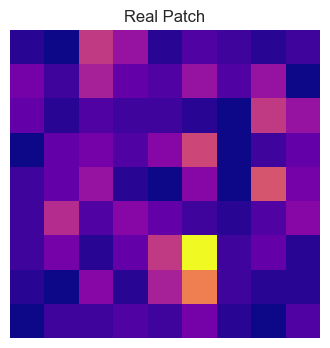

Epoch 1/50 - Train Loss: 0.1426 - Val Loss: 0.0919
Epoch 2/50 - Train Loss: 0.0689 - Val Loss: 0.0521
Epoch 3/50 - Train Loss: 0.0497 - Val Loss: 0.0471
Epoch 4/50 - Train Loss: 0.0409 - Val Loss: 0.0389
Epoch 5/50 - Train Loss: 0.0360 - Val Loss: 0.0246


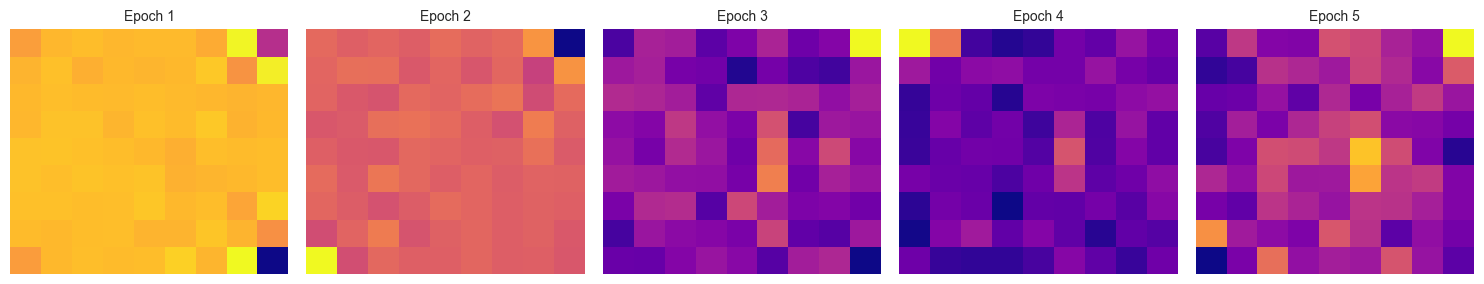

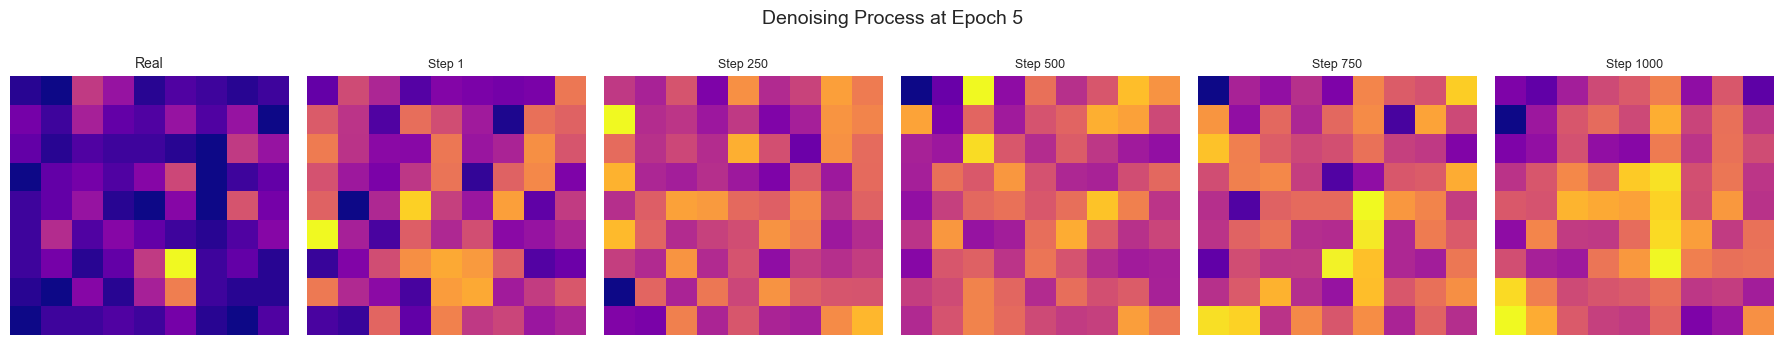

Epoch 6/50 - Train Loss: 0.0360 - Val Loss: 0.0279
Epoch 7/50 - Train Loss: 0.0321 - Val Loss: 0.0250
Epoch 8/50 - Train Loss: 0.0316 - Val Loss: 0.0248
Epoch 9/50 - Train Loss: 0.0293 - Val Loss: 0.0336
Epoch 10/50 - Train Loss: 0.0284 - Val Loss: 0.0334


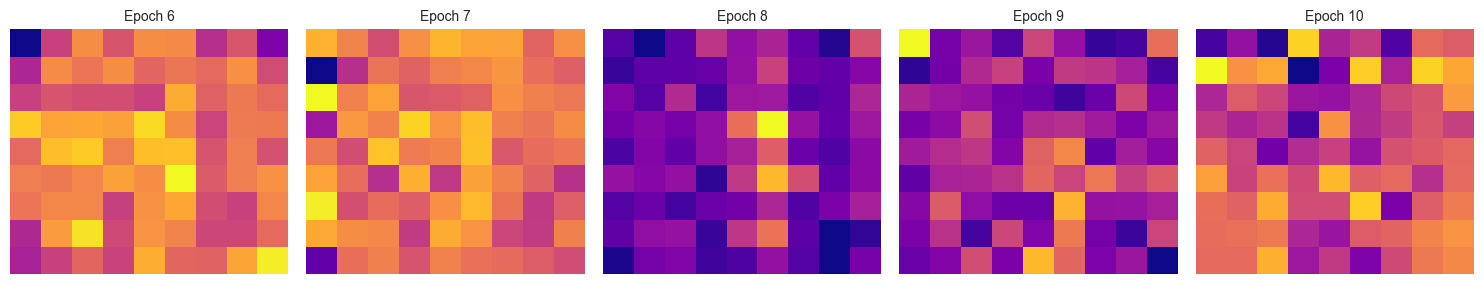

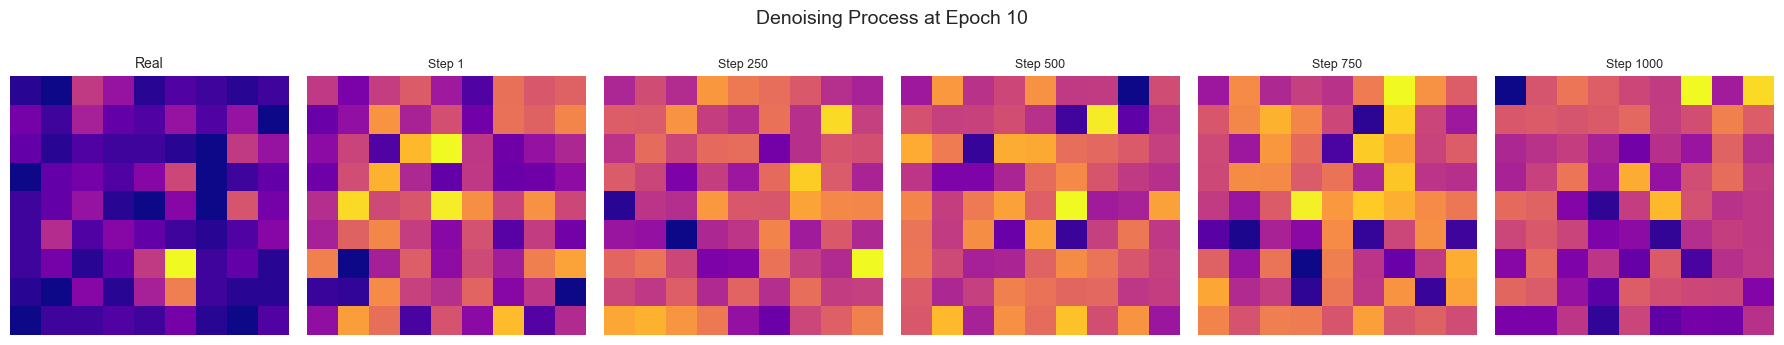

Epoch 11/50 - Train Loss: 0.0293 - Val Loss: 0.0336
Epoch 12/50 - Train Loss: 0.0268 - Val Loss: 0.0384
Epoch 13/50 - Train Loss: 0.0255 - Val Loss: 0.0261
Epoch 14/50 - Train Loss: 0.0276 - Val Loss: 0.0228
Epoch 15/50 - Train Loss: 0.0294 - Val Loss: 0.0322


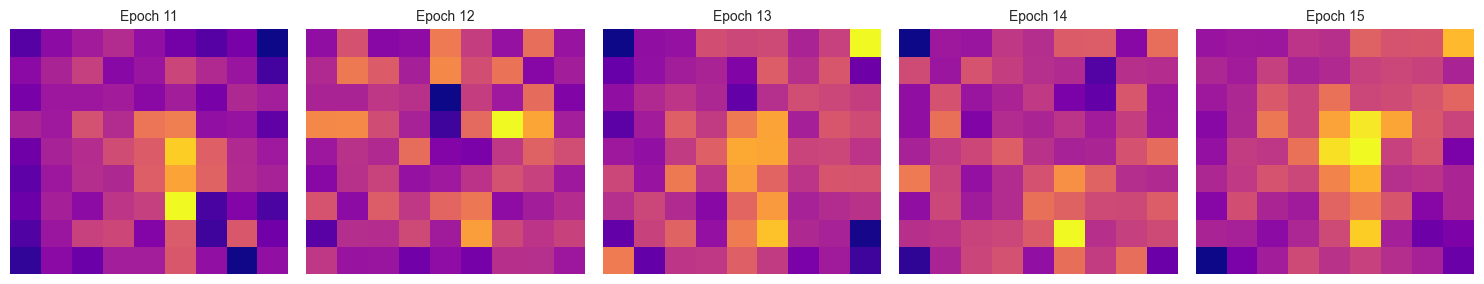

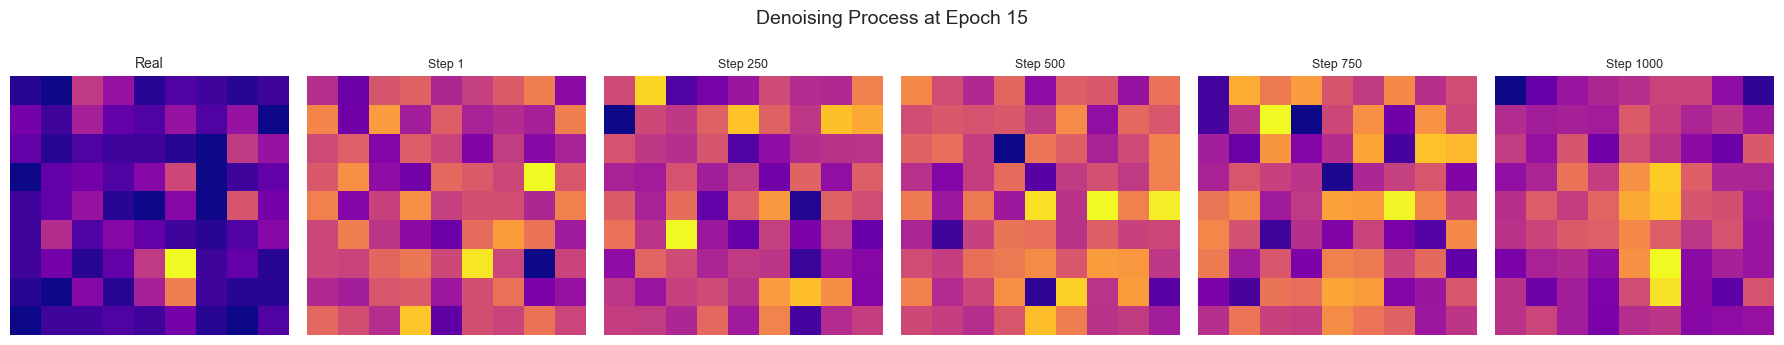

Epoch 16/50 - Train Loss: 0.0270 - Val Loss: 0.0285
Epoch 17/50 - Train Loss: 0.0259 - Val Loss: 0.0283
Epoch 18/50 - Train Loss: 0.0261 - Val Loss: 0.0288
Epoch 19/50 - Train Loss: 0.0230 - Val Loss: 0.0253
Epoch 20/50 - Train Loss: 0.0260 - Val Loss: 0.0227


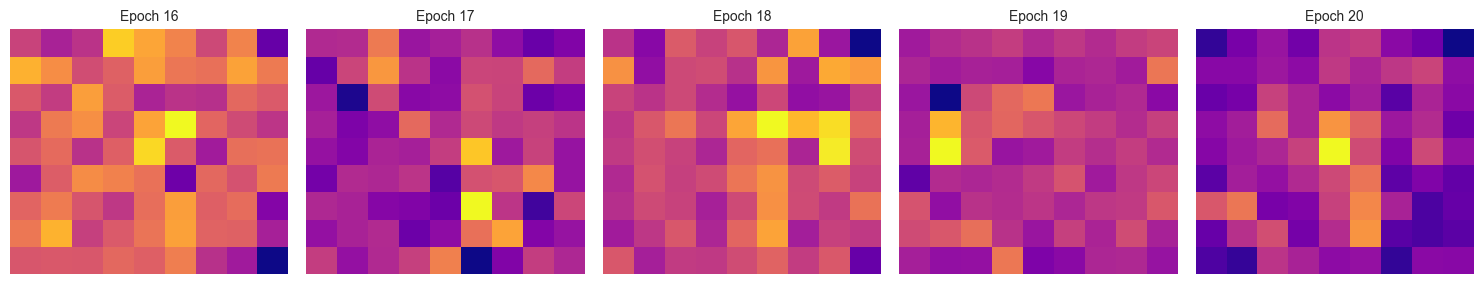

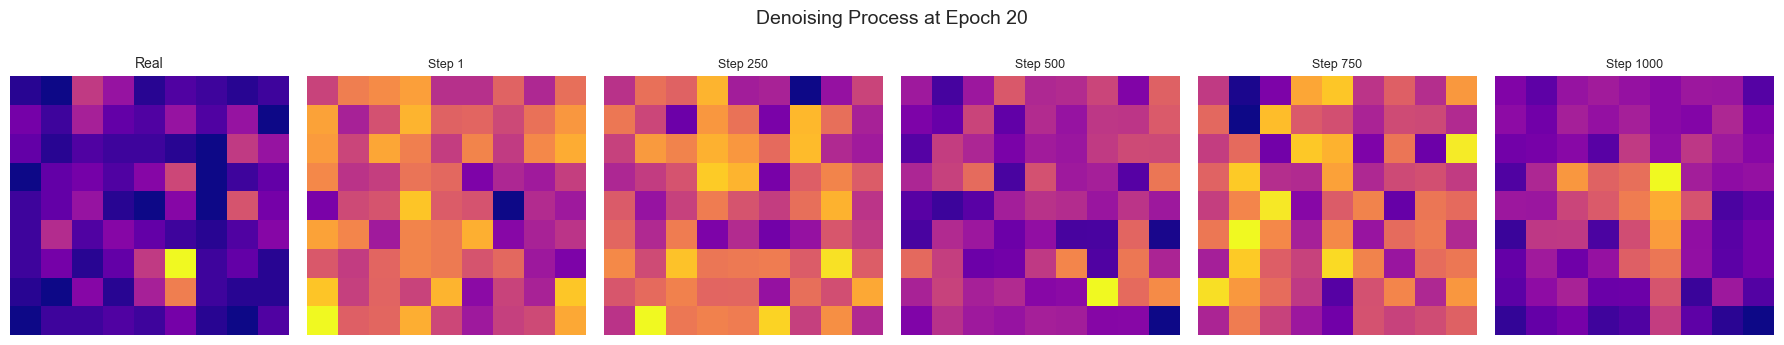

Epoch 21/50 - Train Loss: 0.0246 - Val Loss: 0.0199
Epoch 22/50 - Train Loss: 0.0236 - Val Loss: 0.0256
Epoch 23/50 - Train Loss: 0.0254 - Val Loss: 0.0228
Epoch 24/50 - Train Loss: 0.0215 - Val Loss: 0.0199
Epoch 25/50 - Train Loss: 0.0242 - Val Loss: 0.0202


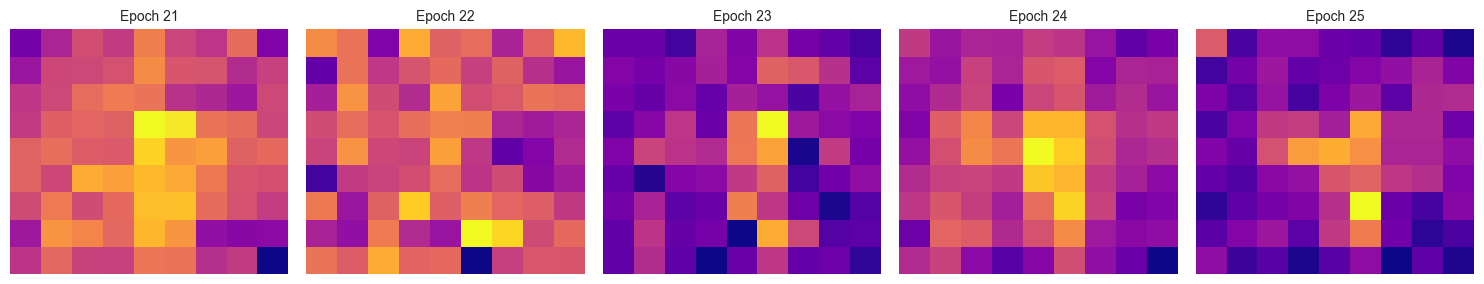

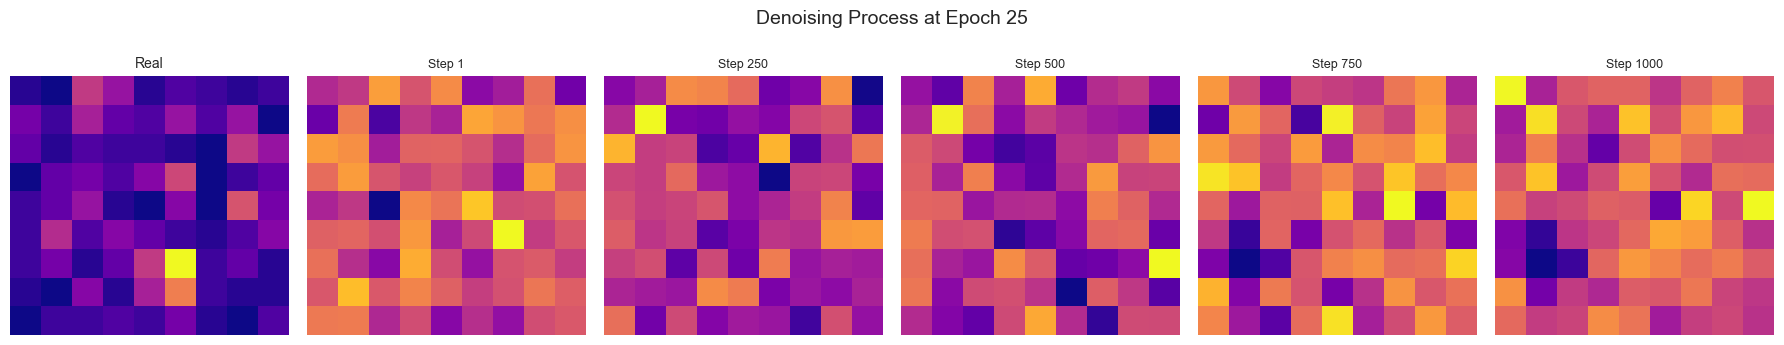

Epoch 26/50 - Train Loss: 0.0261 - Val Loss: 0.0219
Epoch 27/50 - Train Loss: 0.0243 - Val Loss: 0.0155
Epoch 28/50 - Train Loss: 0.0230 - Val Loss: 0.0243
Epoch 29/50 - Train Loss: 0.0212 - Val Loss: 0.0182
Epoch 30/50 - Train Loss: 0.0251 - Val Loss: 0.0220


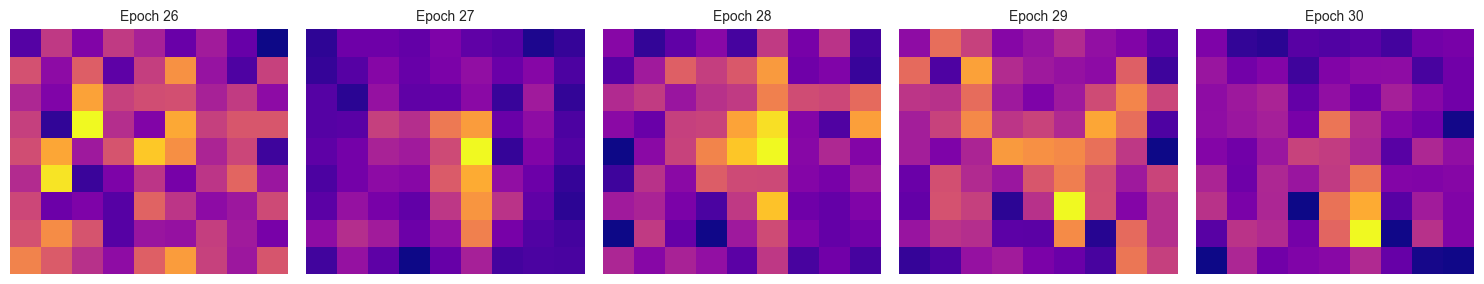

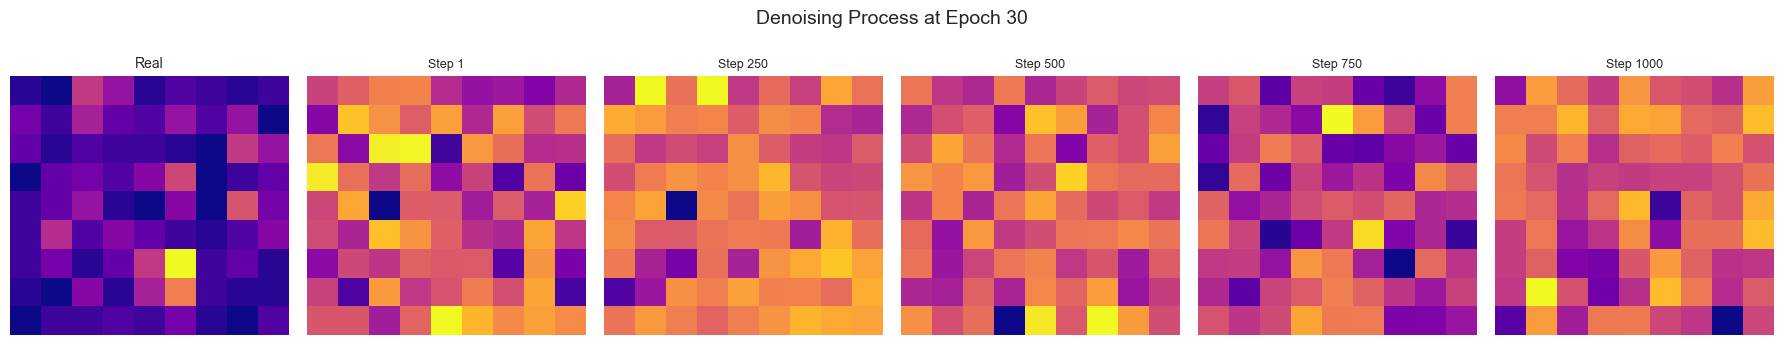

Epoch 31/50 - Train Loss: 0.0217 - Val Loss: 0.0221
Epoch 32/50 - Train Loss: 0.0199 - Val Loss: 0.0169
Epoch 33/50 - Train Loss: 0.0256 - Val Loss: 0.0186
Epoch 34/50 - Train Loss: 0.0254 - Val Loss: 0.0176
Epoch 35/50 - Train Loss: 0.0209 - Val Loss: 0.0174


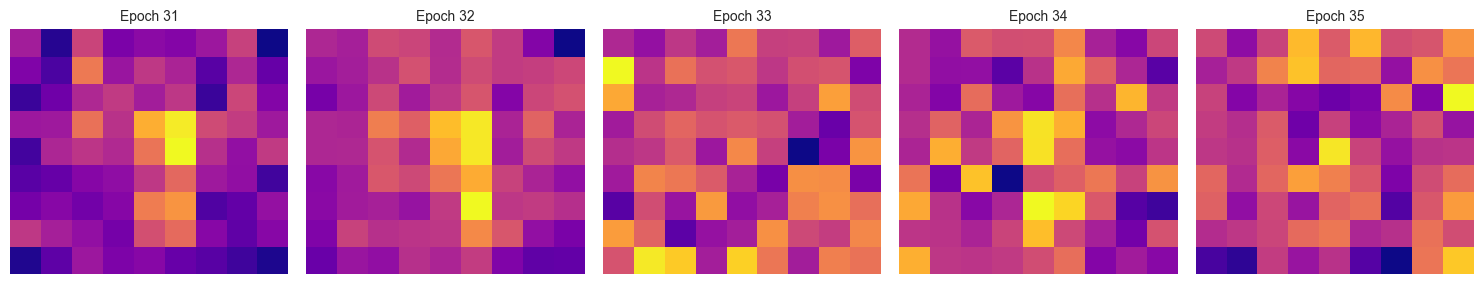

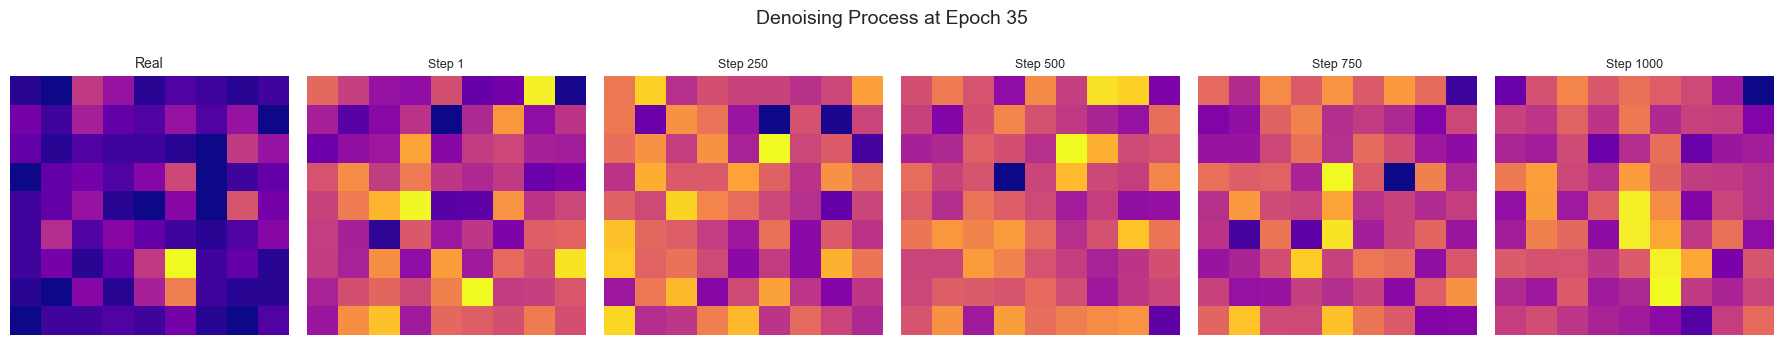

Epoch 36/50 - Train Loss: 0.0211 - Val Loss: 0.0201
Epoch 37/50 - Train Loss: 0.0211 - Val Loss: 0.0171
Epoch 38/50 - Train Loss: 0.0207 - Val Loss: 0.0283
Epoch 39/50 - Train Loss: 0.0191 - Val Loss: 0.0170
Epoch 40/50 - Train Loss: 0.0231 - Val Loss: 0.0282


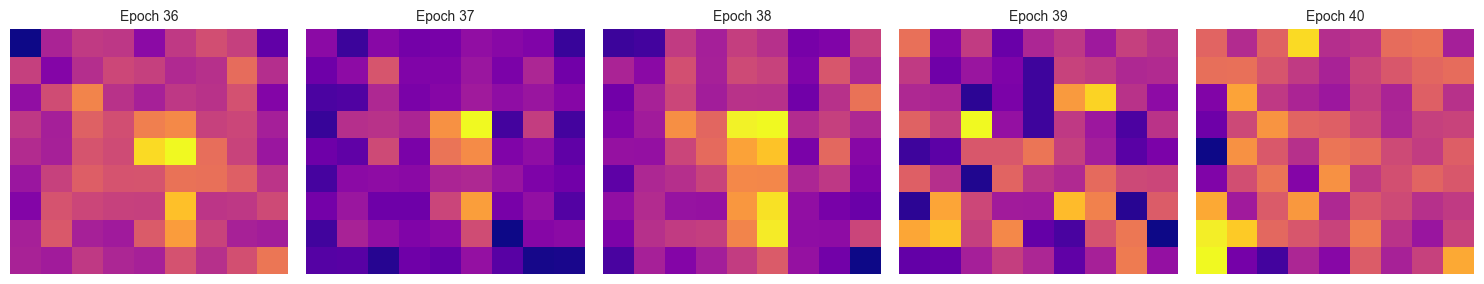

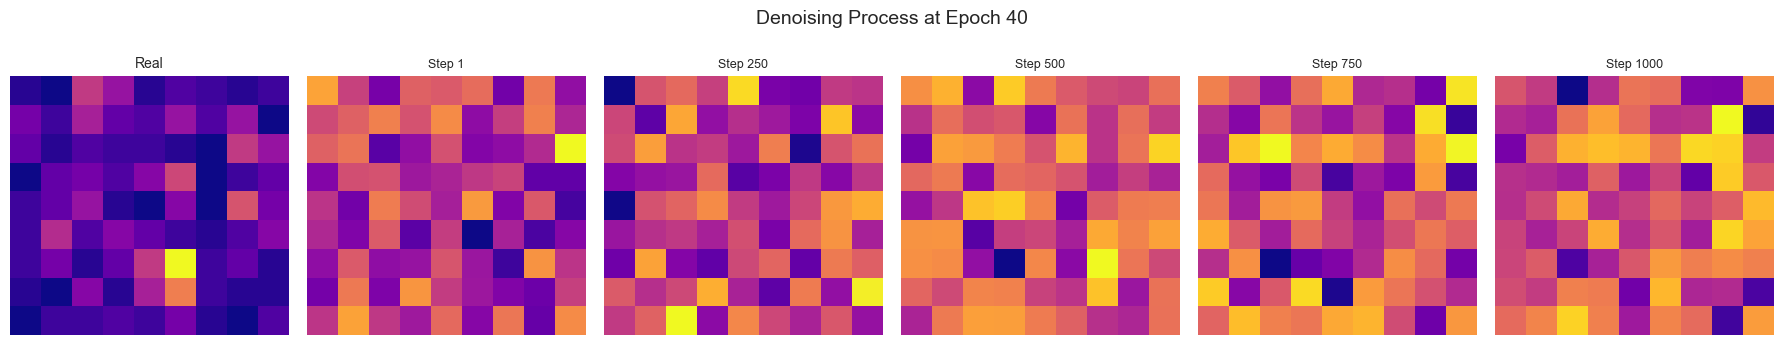

Epoch 41/50 - Train Loss: 0.0251 - Val Loss: 0.0186
Epoch 42/50 - Train Loss: 0.0203 - Val Loss: 0.0178
Epoch 43/50 - Train Loss: 0.0198 - Val Loss: 0.0217
Epoch 44/50 - Train Loss: 0.0202 - Val Loss: 0.0236
Epoch 45/50 - Train Loss: 0.0194 - Val Loss: 0.0213


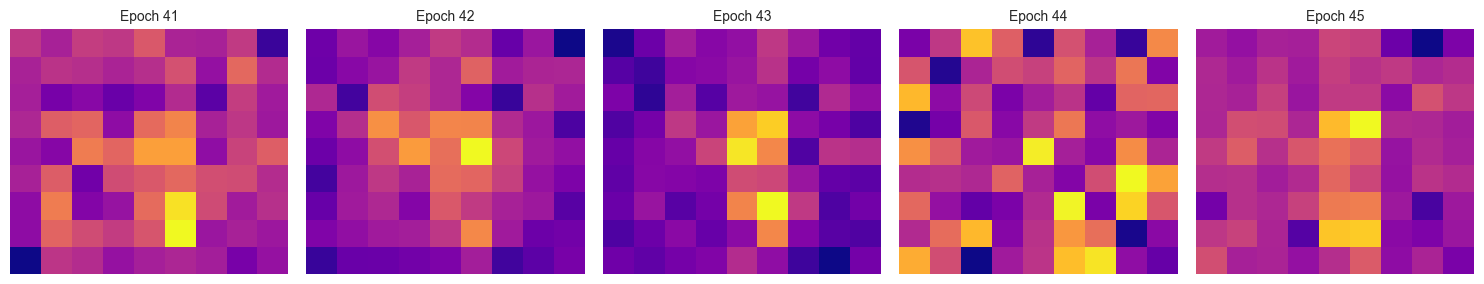

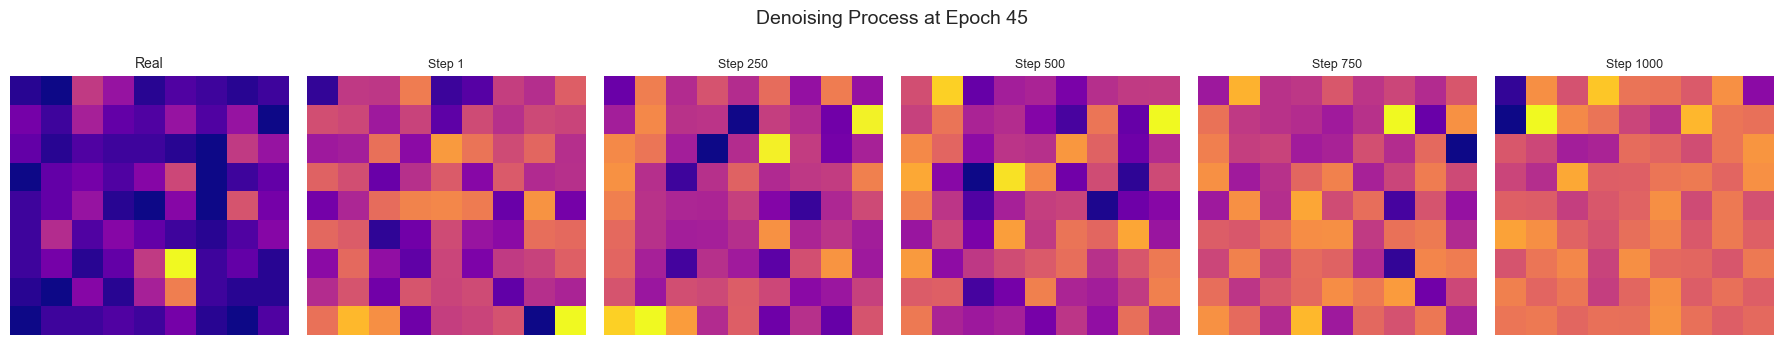

Epoch 46/50 - Train Loss: 0.0191 - Val Loss: 0.0165
Epoch 47/50 - Train Loss: 0.0206 - Val Loss: 0.0181
Epoch 48/50 - Train Loss: 0.0196 - Val Loss: 0.0162
Epoch 49/50 - Train Loss: 0.0216 - Val Loss: 0.0265
Epoch 50/50 - Train Loss: 0.0206 - Val Loss: 0.0184


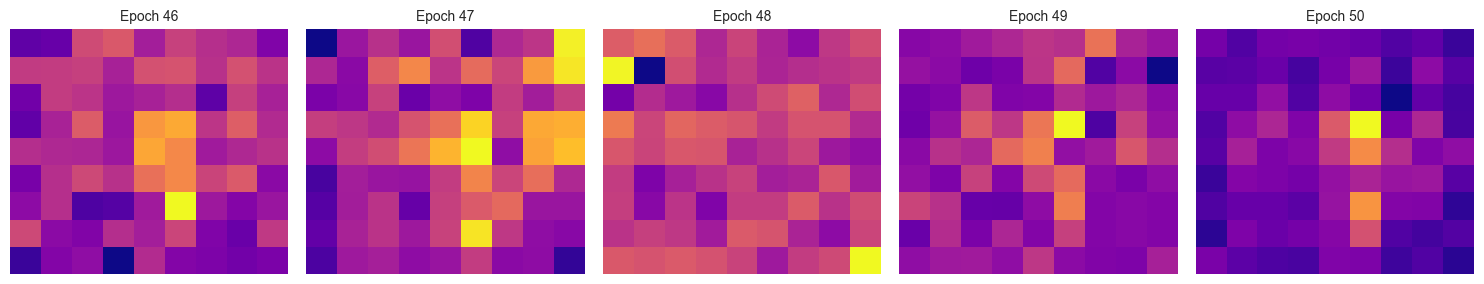

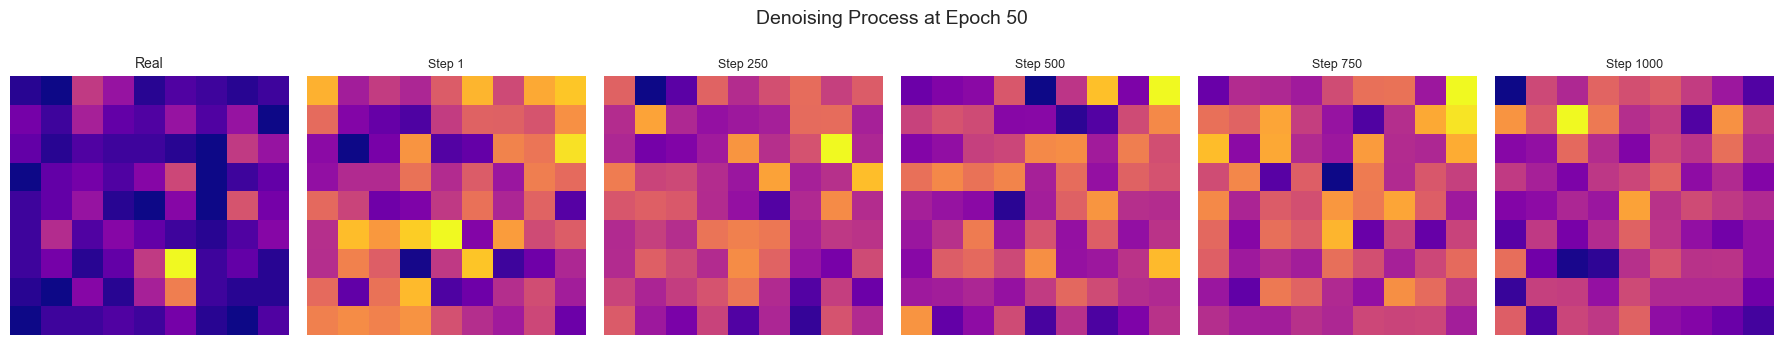

In [118]:
# ============================
# 8. plot
# ============================
def plot_epoch_images(epoch_images, n_cols=5):
    """
    每累積滿 n_cols 張就輸出一次圖 (一排顯示 n_cols 張)
    """
    if len(epoch_images) % n_cols == 0:  # 每滿 5 張才畫
        n_imgs = len(epoch_images)
        plt.figure(figsize=(n_cols * 3, 3))

        for i in range(n_cols):
            img = epoch_images[n_imgs - n_cols + i]  # 取最近 n_cols 張
            plt.subplot(1, n_cols, i + 1)
            sns.heatmap(img, cmap="plasma", cbar=False,
                        xticklabels=False, yticklabels=False)
            plt.title(f"Epoch {n_imgs - n_cols + i + 1}", fontsize=10)
            plt.axis("off")

        plt.tight_layout()
        plt.show()

# 畫出真實 patch
x_fixed = patches[1836:1837]
plt.figure(figsize=(4,4))
sns.heatmap(x_fixed[0,:,:,0], cmap="plasma", cbar=False)
plt.title(f"Real Patch")
plt.axis("off")
plt.show()

# 固定條件與真實 patch
fixed_cond = conds[1836:1837]   # 條件
fixed_real = patches[1836:1837] # 真實 patch (9x9x1)
def visualize_denoising_process(model, cond, epoch, timesteps=1000, n_steps=5):
    """
    可視化 Diffusion 去噪過程
    cond: (1, cond_dim)
    n_steps: 要抓幾個中間狀態 (均勻取樣)
    """
    # 初始化高斯噪聲
    x = tf.random.normal((1, 9, 9, 1))
    cond = tf.convert_to_tensor(cond, dtype=tf.float32)

    # 決定要抓的時間點
    steps_to_show = np.linspace(0, timesteps-1, n_steps, dtype=int)
    images = []
    for t in reversed(range(timesteps)):
        x = p_sample(model, x, cond, t)
        if t in steps_to_show:  # 記錄中間狀態
            images.append(x.numpy()[0, :, :, 0])

    # 加上真實 patch 一起對比
    plt.figure(figsize=((n_steps+1)*3, 3.5))
    
    # 標題 
    plt.suptitle(f"Denoising Process at Epoch {epoch+1}", fontsize=14)
    
    # 真實圖
    plt.subplot(1, n_steps+1, 1)
    sns.heatmap(fixed_real[0,:,:,0], cmap="plasma", cbar=False,
                xticklabels=False, yticklabels=False)
    plt.title("Real", fontsize=10)
    plt.axis("off")

    # 生成過程
    for i, img in enumerate(images):
        plt.subplot(1, n_steps+1, i+2)
        sns.heatmap(img, cmap="plasma", cbar=False,
                    xticklabels=False, yticklabels=False)
        plt.title(f"Step {steps_to_show[i]+1}", fontsize=9)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

# ============================
# 9. 訓練迴圈
# ============================
epochs = 50
batch_size = 32
history = {"train_loss": [], "val_loss": []}

train_ds = tf.data.Dataset.from_tensor_slices((X_train, C_train)).shuffle(1000).batch(batch_size)
val_ds   = tf.data.Dataset.from_tensor_slices((X_val, C_val)).batch(batch_size)

epoch_images = []
for epoch in range(epochs):
    # ---- Training ----
    train_losses = []
    for xb, cb in train_ds:
        loss = train_step(xb, cb)
        train_losses.append(loss.numpy())
    avg_train = np.mean(train_losses)
    
    # ---- Validation ----
    val_losses = []
    for xb, cb in val_ds:
        noise = tf.random.normal(tf.shape(xb))
        t = tf.random.uniform((tf.shape(xb)[0],), minval=0, maxval=timesteps, dtype=tf.int32)
        xt = q_sample(xb, t, noise)
        noise_pred = model([xt, cb], training=False)
        val_loss = mse(noise, noise_pred)
        val_losses.append(val_loss.numpy())
    avg_val = np.mean(val_losses)

    # ---- Save history ----
    history["train_loss"].append(avg_train)
    history["val_loss"].append(avg_val)

    # 訓練進度
    print(f"Epoch {epoch+1}/{epochs} - Train Loss: {avg_train:.4f} - Val Loss: {avg_val:.4f}")
    
    # 視覺化結果
    fake_patch = sample(model, fixed_cond, timesteps=1000)[0, :, :, 0] 
    epoch_images.append(fake_patch)
    plot_epoch_images(epoch_images, n_cols=5)

    # 顯示去噪過程
    if (epoch+1) % 5 == 0:  # 每 5 個 epoch 顯示一次
        visualize_denoising_process(model, fixed_cond, epoch, timesteps=1000, n_steps=5)

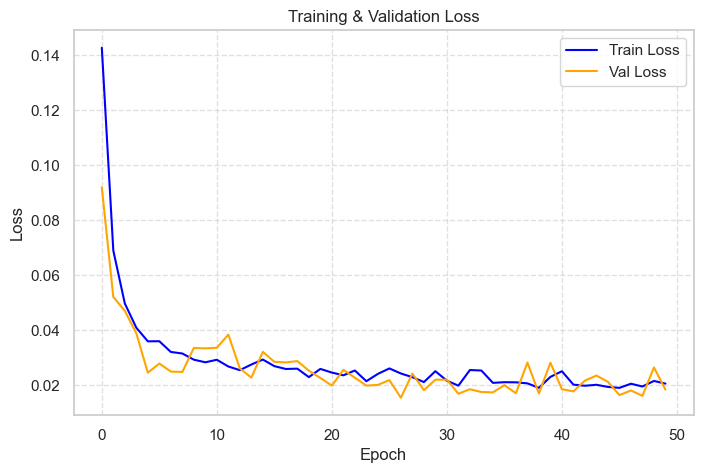

In [119]:
# ============================
# Loss 曲線
# ============================
plt.figure(figsize=(8,5))
plt.plot(history["train_loss"], label="Train Loss", color="blue")
plt.plot(history["val_loss"], label="Val Loss", color="orange")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

In [ ]:
# model.save_weights("0081_7d06_256conv_32batch_100e.weights.h5")      # 保存權重
# model.load_weights("0135weights.weights.h5")      # 之後載入權重

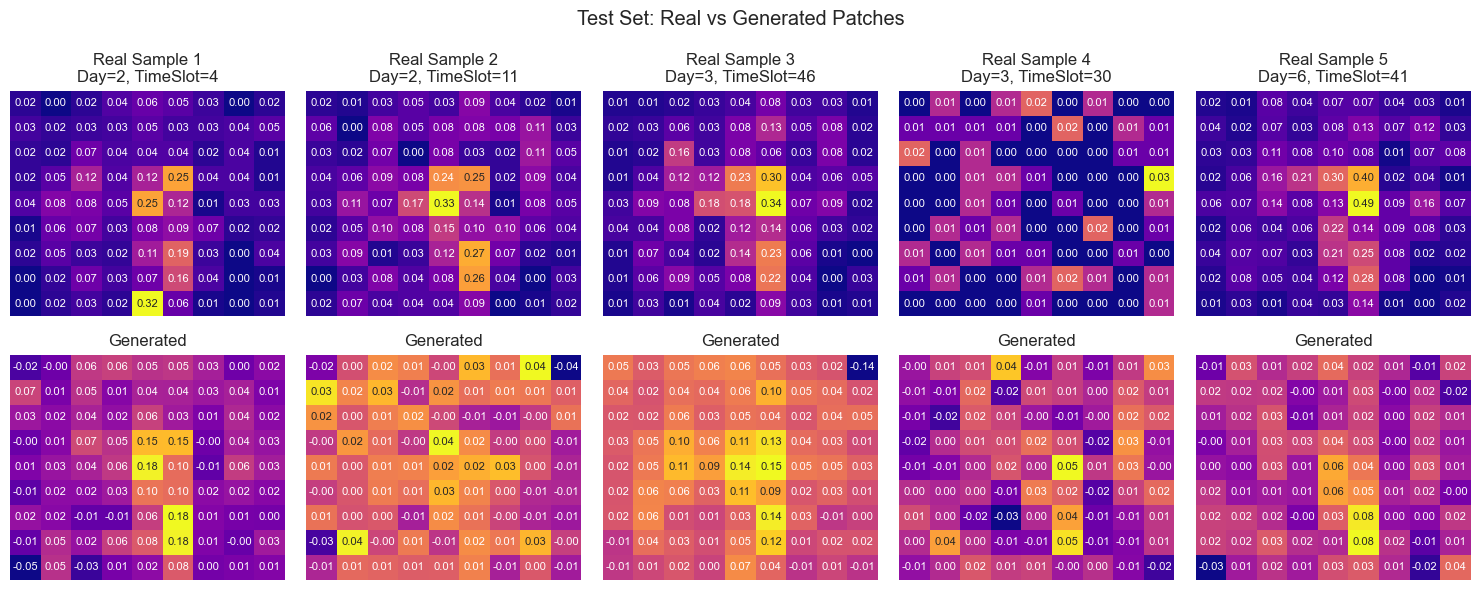

Test MAE  (original scale): 6.9007
Test RMSE (original scale): 11.0347


(6.900683879852295, 11.0347261428833)

In [120]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
import numpy as np

# model.load_weights("0081_7d06_256conv_32batch_100e.weights.h5") 

# =======================
# 測試集比較: Real vs Generated
# =======================

def evaluate_on_test(model, X_test, C_test, n_samples=5):
    idxs = np.random.choice(len(X_test), size=n_samples, replace=False)
    plt.figure(figsize=(n_samples*3, 6))

    for i, idx in enumerate(idxs):
        day  = idx // slots           # 第幾天
        slot = idx % slots            # 第幾個timeslot

        real_patch = X_test[idx,:,:,0]
        cond = C_test[idx:idx+1]

        # 從 diffusion 生成
        fake_patch = sample(model, cond, timesteps=1000)[0, :, :, 0]

        # 真實資料圖
        plt.subplot(2, n_samples, i+1)
        sns.heatmap(
            real_patch,
            cmap="plasma",
            cbar=False,
            annot=True,          # 顯示每格數值
            fmt=".2f",           # 數字格式，小數點2位
            annot_kws={"size":8},# 設定數字字體大小
            xticklabels=False,
            yticklabels=False
        )
        plt.title(f"Real Sample {i+1}\nDay={day}, TimeSlot={slot}")

        # 生成資料圖
        plt.subplot(2, n_samples, i+1+n_samples)
        sns.heatmap(
            fake_patch,
            cmap="plasma",
            cbar=False,
            annot=True,          # 顯示每格數值
            fmt=".2f",
            annot_kws={"size":8},
            xticklabels=False,
            yticklabels=False
        )
        plt.title("Generated")

    plt.suptitle("Test Set: Real vs Generated Patches")
    plt.tight_layout()
    plt.show()

evaluate_on_test(model, X_test, C_test, n_samples=5)

#  計算測試集 MAE / RMSE
def evaluate_mae_rmse(model, X_test, C_test, scaler, timesteps=1000, batch_size=64):
    N = len(X_test)
    all_real, all_fake = [], []

    for start in range(0, N, batch_size):
        end = min(start + batch_size, N)
        cond_batch = C_test[start:end]                                # (B, 49)
        fake_batch = sample(model, cond_batch, timesteps=timesteps,   # (B, 9, 9, 1)
                            batch_size=len(cond_batch))[:, :, :, 0]   # -> (B, 9, 9)

        real_batch = X_test[start:end, :, :, 0]                       # (B, 9, 9)

        # 還原回原始 scale
        real_inv = scaler.inverse_transform(real_batch.reshape(-1,1)).reshape(-1)
        fake_inv = scaler.inverse_transform(fake_batch.reshape(-1,1)).reshape(-1)

        all_real.append(real_inv)
        all_fake.append(fake_inv)

    all_real = np.concatenate(all_real)
    all_fake = np.concatenate(all_fake)

    mae  = mean_absolute_error(all_real, all_fake)
    rmse = root_mean_squared_error(all_real, all_fake)
    print(f"Test MAE  (original scale): {mae:.4f}")
    print(f"Test RMSE (original scale): {rmse:.4f}")
    return mae, rmse

evaluate_mae_rmse(model, X_test, C_test, scaler, timesteps=1000, batch_size=32)